#  G6 FOOD PRICE PREDICTION


---

# 1. Business understanding

## 1.1 Business Overview

Over the last 24 months, the Kenyan market has been characterized by extreme volatility in the prices of essential food items, ranging from fresh produce like tomatoes and avocados to staples such as maize, beans, and flour. These unpredictable fluctuations create a destabilizing cycle for both consumers and producers, as the market rapidly oscillates between wasteful surpluses and 
acute shortages.
 
This project seeks to mitigate these imbalances by utilizing time-series forecasting to provide reliable price predictions. By delivering actionable insights—such as forecasting the value of a 90kg bag of maize half a year into the future—the model empowers farmers in regions like Uasin Gishu to make informed, data-driven decisions on whether to maintain current crop cycles or pivot to more viable alternatives.

## 1.2 Stakeholders

• Consumers: To aid in household budgeting and long-term food procurement planning.

• Farmers & Saccos: To determine optimal planting cycles and market entry timing to 
maximize profit. 

• Government Agencies (Ministry of Agriculture/NCPB): To inform policy interventions such as 
food subsidies or strategic grain reserve management. 

• General Insurance Providers: For potential use in agricultural insurance risk assessment and 
index-based weather insurance.

## 1.3 Business Objectives
### Main Objective:
Develop and deploy a multivariate machine learning model to forecast the prices of key commodities (Maize, Milk, Beans) across different Kenyan markets
### Specific objective:
Integrate external causal factors—specifically rainfall and fuel prices—to enhance the model's predictive accuracy regarding price shocks

## 1.4 Project shortcomings
• Direct Insurance Underwriting: While insights benefit insurers, direct claims management is beyond the scope. 

• Logistics Management: The project does not automate the physical supply chain or transport of goods.

# 2. Data Understanding

## 2.1 Data Sources:
The project will leverage three primary online data sources to ensure a comprehensive feature set:

• WFP Food Prices (HDX): Historical monthly price data for various commodities and markets across Kenya.

• CHIRPS Rainfall Data (Google Earth Engine/HDX): Historical precipitation levels to track climate-related supply shifts. 

• EPRA Fuel Prices: Historical diesel prices to account for transportation and production costs.

## 2.2 Target and Predictors:
• Target: The future price of a specific commodity (e.g., KES per 90kg bag of maize).

• Predictors:

o Time Indicators: Month, year, and seasonality markers. 

o Market Metadata: Region, market name, and commodity type.

o External Features: Monthly average rainfall (mm) and Diesel retail prices (KES)

# 3. Workflow Phases: 
1. Data Exploration
2. Data Preparation & Merging
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Lag Creation
5. Modelling (Linear Regression → Gradient Boosted Trees)
6. Evaluation
7. Prediction Interface


##  4. Importing libraries

In [29]:
# Core Libraries 
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Modelling 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit   
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer                            
from sklearn.impute import SimpleImputer






##  4.1.  Loading the data

Three independent datasets must be loaded and understood before merging.

### 4a. WFP Food Prices (Target Dataset)

In [30]:
# Load WFP Food Prices 
wfp = pd.read_csv('food_prices_ken.csv', parse_dates=['date'])

print(f'Shape: {wfp.shape}')
print(f'Date range: {wfp["date"].min().date()} → {wfp["date"].max().date()}')
print(f'Unique counties (admin2): {wfp["admin2"].nunique()}')
print(f'Unique commodities: {wfp["commodity"].nunique()}')
print()
wfp.head()

Shape: (19005, 16)
Date range: 2006-01-15 → 2026-03-15
Unique counties (admin2): 27
Unique commodities: 51



,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24


In [31]:
# Summary statistics 
print('=== Missing Values ===')
print(wfp.isnull().sum())
print()
print('=== Numeric Summary ===')
wfp[['price', 'usdprice']].describe()

=== Missing Values ===
date             0
admin1          39
admin2          39
market           0
market_id        0
latitude        39
longitude       39
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

=== Numeric Summary ===


,price,usdprice
count,19005.000000,19005.000000
mean,1327.815265,12.127999
std,2609.366827,23.113554
min,5.000000,0.039000
25%,67.000000,0.600000
50%,133.000000,1.060000
75%,1105.000000,10.360000
max,19800.000000,184.820000


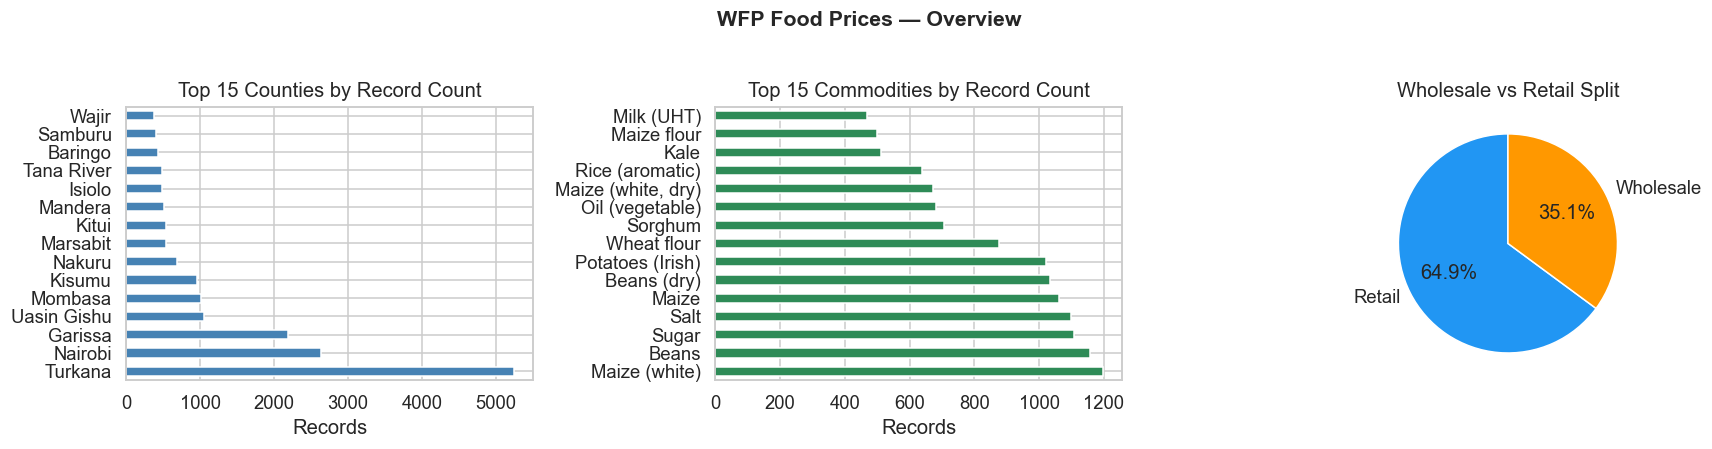

In [32]:
#  Key field distributions 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Records per county
wfp['admin2'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Counties by Record Count')
axes[0].set_xlabel('Records')

# Records per commodity (top 15)
wfp['commodity'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 15 Commodities by Record Count')
axes[1].set_xlabel('Records')

# Price type split
wfp['pricetype'].value_counts().plot(kind='pie', ax=axes[2], autopct='%1.1f%%',
                                      colors=['#2196F3', '#FF9800'], startangle=90)
axes[2].set_title('Wholesale vs Retail Split')
axes[2].set_ylabel('')

plt.suptitle('WFP Food Prices — Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4b. CHIRPS Rainfall Data

In [33]:
# Load Rainfall Data 
rain = pd.read_csv('ken-rainfall-subnat-full.csv', parse_dates=['date'])

print(f'Shape: {rain.shape}')
print(f'Date range: {rain["date"].min().date()} → {rain["date"].max().date()}')
print(f'Admin levels: {rain["adm_level"].unique()}')
print(f'Unique PCODEs: {rain["PCODE"].nunique()}')
print()
rain.head()

Shape: (132273, 15)
Date range: 1981-01-01 → 2026-05-01
Admin levels: [1 2]
Unique PCODEs: 81



,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,1981-01-01,1,51325,KE019,427.0,7.372365,15.759407,NaN,NaN,NaN,NaN,59.598840,NaN,NaN,final
1,1981-01-11,1,51325,KE019,427.0,4.325527,19.294770,NaN,NaN,NaN,NaN,38.384920,NaN,NaN,final
2,1981-01-21,1,51325,KE019,427.0,5.569087,16.265417,17.266980,51.319595,NaN,NaN,49.700817,39.536823,NaN,final
3,1981-02-01,1,51325,KE019,427.0,5.882904,12.719282,15.777517,48.279470,NaN,NaN,61.418427,38.997230,NaN,final
4,1981-02-11,1,51325,KE019,427.0,17.180328,18.768618,28.632318,47.753320,NaN,NaN,93.317700,63.753933,NaN,final


In [34]:
# Rainfall fields glossary 
glossary = {
    'rfh':     'Rainfall height for the current dekad (10-day period) in mm',
    'rfh_avg': 'Historical average rainfall for this dekad',
    'r1h':     'Cumulative rainfall over the past 1 month (mm)',
    'r1h_avg': 'Historical 1-month average rainfall',
    'r3h':     'Cumulative rainfall over the past 3 months (mm)',
    'r3h_avg': 'Historical 3-month average rainfall',
    'rfq':     'Rainfall anomaly (current vs. average, %) — dekadal',
    'r1q':     'Rainfall anomaly — 1-month rolling',
    'r3q':     'Rainfall anomaly — 3-month rolling',
}
print('CHIRPS Rainfall Feature ')
print('=' * 55)
for k, v in glossary.items():
    print(f'  {k:<10} {v}')

CHIRPS Rainfall Feature 
  rfh        Rainfall height for the current dekad (10-day period) in mm
  rfh_avg    Historical average rainfall for this dekad
  r1h        Cumulative rainfall over the past 1 month (mm)
  r1h_avg    Historical 1-month average rainfall
  r3h        Cumulative rainfall over the past 3 months (mm)
  r3h_avg    Historical 3-month average rainfall
  rfq        Rainfall anomaly (current vs. average, %) — dekadal
  r1q        Rainfall anomaly — 1-month rolling
  r3q        Rainfall anomaly — 3-month rolling


In [35]:
print('Missing values in rainfall data:')
print(rain.isnull().sum())
print()
print('County-level PCODEs (adm_level = 1):')
print(rain[rain['adm_level']==1]['PCODE'].unique())

Missing values in rainfall data:
date           0
adm_level      0
adm_id         0
PCODE          0
n_pixels       0
rfh            0
rfh_avg        0
r1h          162
r1h_avg      162
r3h          648
r3h_avg      648
rfq            0
r1q          162
r3q          648
version        0
dtype: int64

County-level PCODEs (adm_level = 1):
['KE019' 'KE004' 'KE010' 'KE047' 'KE008' 'KE043' 'KE023' 'KE037']


### 4c. EPRA Fuel Prices

In [36]:
# Load Fuel Prices 
fuel = pd.read_csv('Pump Prices  Energy and Petroleum Regulatory Authority.csv')

# Standardise date — multiple formats exist in this dataset
fuel['date'] = pd.to_datetime(fuel['Date'], dayfirst=True)
fuel = fuel.drop(columns=['Date']).sort_values('date').reset_index(drop=True)

print(f'Shape: {fuel.shape}')
print(f'Date range: {fuel["date"].min().date()} → {fuel["date"].max().date()}')
print(f'Towns covered: {fuel["Town"].unique()}')
print()
fuel.head(8)

Shape: (197, 5)
Date range: 2010-01-15 → 2026-04-16
Towns covered: ['Nairobi']



,Town,Super (PMS),Diesel (AGO),Kerosene (IK),date
0,Nairobi,98.50,89.2,80.10,2010-01-15
1,Nairobi,99.80,90.5,81.40,2010-02-15
2,Nairobi,88.52,76.9,61.35,2010-03-15
3,Nairobi,90.64,79.9,61.80,2010-04-15
4,Nairobi,103.70,94.4,85.30,2010-05-15
5,Nairobi,105.00,95.7,86.60,2010-06-15
6,Nairobi,106.30,97.0,87.90,2010-07-15
7,Nairobi,107.60,98.3,89.20,2010-08-15


plot the fuel price trend across the years

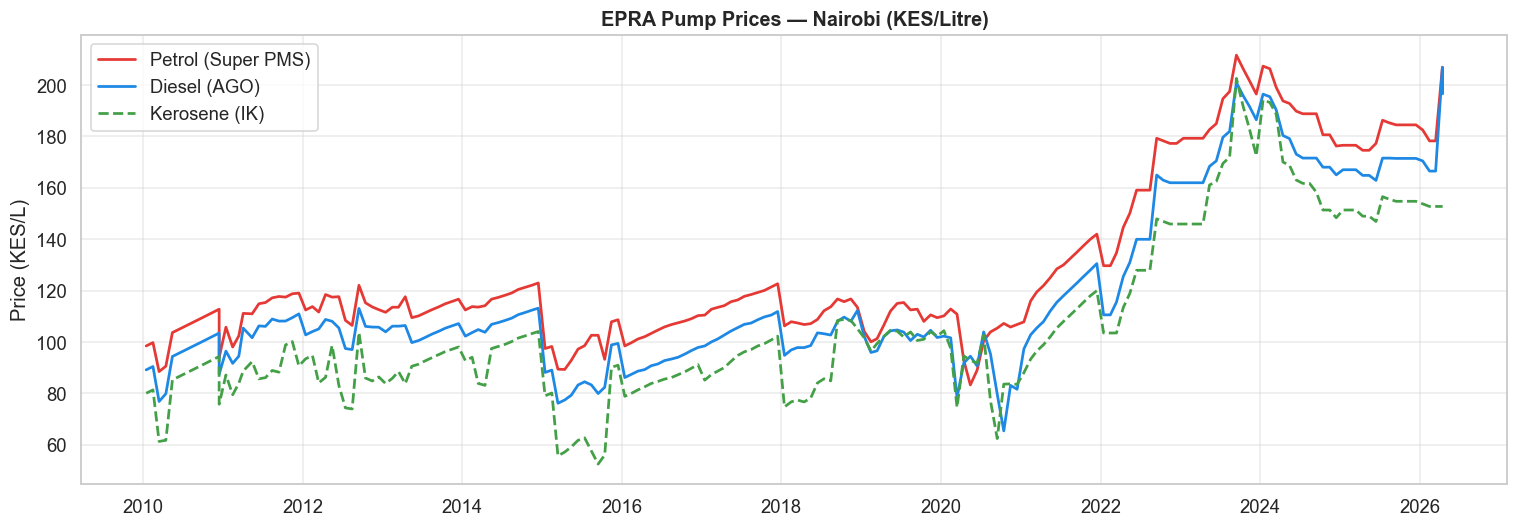

In [37]:
# Plot fuel price trends 
nairobi_fuel = fuel[fuel['Town'] == 'Nairobi'].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(nairobi_fuel['date'], nairobi_fuel['Super (PMS)'],  label='Petrol (Super PMS)',  color='#E53935', lw=1.8)
ax.plot(nairobi_fuel['date'], nairobi_fuel['Diesel (AGO)'], label='Diesel (AGO)',         color='#1E88E5', lw=1.8)
ax.plot(nairobi_fuel['date'], nairobi_fuel['Kerosene (IK)'],label='Kerosene (IK)',        color='#43A047', lw=1.8, ls='--')
ax.set_title('EPRA Pump Prices — Nairobi (KES/Litre)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (KES/L)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


##  4.2 Data Preparation & Merging

### 4.2a. Standardise Dates to Monthly (YYYY-MM-DD)

Step 1: Normalise all dates to month-start

In [38]:
# WFP — already monthly
wfp['date_month'] = wfp['date'].dt.to_period('M').dt.to_timestamp()

# Fuel — irregular dates; take median monthly price
fuel['date_month'] = fuel['date'].dt.to_period('M').dt.to_timestamp()
fuel_monthly = (
    fuel[fuel['Town'] == 'Nairobi']
    .groupby('date_month')[['Super (PMS)', 'Diesel (AGO)', 'Kerosene (IK)']]
    .median()
    .reset_index()
)
fuel_monthly.columns = ['date_month', 'petrol_kes', 'diesel_kes', 'kerosene_kes']
print('Fuel monthly shape:', fuel_monthly.shape)
fuel_monthly.tail()

Fuel monthly shape: (195, 4)


,date_month,petrol_kes,diesel_kes,kerosene_kes
190,2025-12-01,184.520,171.470,154.78
191,2026-01-01,182.520,170.470,153.78
192,2026-02-01,178.280,166.540,152.78
193,2026-03-01,178.280,166.540,152.78
194,2026-04-01,202.285,201.735,152.78


### 4.2b. Rainfall — Aggregate Dekadal → Monthly

In [39]:
# PCODE → County name mapping 
# Using Kenya official PCODE standard (47 counties)
# Only counties covered by EPRA/WFP data need mapping
pcode_county_map = {
    # Standard 2-char PCODEs (adm_level 1 in CHIRPS)
    'KE001': 'Mombasa',     'KE002': 'Kwale',       'KE003': 'Kilifi',
    'KE004': 'Tana River',  'KE005': 'Lamu',         'KE006': 'Taita Taveta',
    'KE007': 'Garissa',     'KE008': 'Wajir',        'KE009': 'Mandera',
    'KE010': 'Marsabit',    'KE011': 'Isiolo',       'KE012': 'Meru',
    'KE013': 'Tharaka Nithi','KE014': 'Embu',        'KE015': 'Kitui',
    'KE016': 'Machakos',    'KE017': 'Makueni',      'KE018': 'Nyandarua',
    'KE019': 'Nyeri',       'KE020': 'Kirinyaga',    'KE021': "Muranga",
    'KE022': 'Kiambu',      'KE023': 'Turkana',      'KE024': 'West Pokot',
    'KE025': 'Samburu',     'KE026': 'Trans Nzoia',  'KE027': 'Uasin Gishu',
    'KE028': 'Elgeyo Marakwet','KE029': 'Nandi',     'KE030': 'Baringo',
    'KE031': 'Laikipia',    'KE032': 'Nakuru',       'KE033': 'Narok',
    'KE034': 'Kajiado',     'KE035': 'Kericho',      'KE036': 'Bomet',
    'KE037': 'Kakamega',    'KE038': 'Vihiga',       'KE039': 'Bungoma',
    'KE040': 'Busia',       'KE041': 'Siaya',        'KE042': 'Kisumu',
    'KE043': 'Homa Bay',    'KE044': 'Migori',       'KE045': 'Kisii',
    'KE046': 'Nyamira',     'KE047': 'Nairobi',
}

# For sub-county PCODEs like 'KE022122', the parent county is the first 5 chars
def pcode_to_county(pcode):
    key = pcode[:5]  # e.g. 'KE022' from 'KE022122'
    return pcode_county_map.get(key, None)

rain['county'] = rain['PCODE'].apply(pcode_to_county)
print('PCODEs with no county mapping:', rain[rain['county'].isna()]['PCODE'].unique()[:10])
rain = rain[rain['county'].notna()].copy()
print(f'Rainfall rows after mapping: {len(rain)}')

PCODEs with no county mapping: []
Rainfall rows after mapping: 132273


In [40]:
# Aggregate dekadal rainfall → monthly per county 
rain['date_month'] = rain['date'].dt.to_period('M').dt.to_timestamp()

rain_monthly = (
    rain.groupby(['date_month', 'county'])
    .agg(
        rainfall_mm   = ('rfh',     'sum'),    # total mm for the month
        rainfall_avg  = ('rfh_avg', 'mean'),   # historical monthly average
        r1h           = ('r1h',     'last'),   # 1-month rolling (last dekad is most recent)
        r3h           = ('r3h',     'last'),   # 3-month rolling
        rainfall_anom = ('rfq',     'mean'),   # anomaly %
    )
    .reset_index()
)

print('Monthly rainfall shape:', rain_monthly.shape)
print('Counties in rainfall:', sorted(rain_monthly['county'].unique()))
rain_monthly.head()

Monthly rainfall shape: (25615, 7)
Counties in rainfall: ['Baringo', 'Bomet', 'Bungoma', 'Busia', 'Elgeyo Marakwet', 'Embu', 'Garissa', 'Homa Bay', 'Isiolo', 'Kajiado', 'Kakamega', 'Kericho', 'Kiambu', 'Kilifi', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Laikipia', 'Lamu', 'Machakos', 'Makueni', 'Mandera', 'Marsabit', 'Meru', 'Migori', 'Mombasa', 'Muranga', 'Nairobi', 'Nakuru', 'Nandi', 'Narok', 'Nyamira', 'Nyandarua', 'Nyeri', 'Samburu', 'Siaya', 'Taita Taveta', 'Tana River', 'Tharaka Nithi', 'Trans Nzoia', 'Turkana', 'Uasin Gishu', 'Vihiga', 'Wajir', 'West Pokot']


,date_month,county,rainfall_mm,rainfall_avg,r1h,r3h,rainfall_anom
0,1981-01-01,Baringo,13.319234,9.958047,7.421053,NaN,49.891181
1,1981-01-01,Bomet,65.770188,27.815266,29.913044,NaN,50.741880
2,1981-01-01,Bungoma,36.528572,14.973360,15.100000,NaN,56.066522
3,1981-01-01,Busia,56.735294,19.629811,28.000000,NaN,59.195616
4,1981-01-01,Elgeyo Marakwet,18.062756,12.632012,8.301887,NaN,47.327582


### 4.2c. WFP — Filter & Focus on Key Commodities

In [41]:
# Focus on Retail prices for key staples 
# (Retail is most relevant to consumers & farmers)
KEY_COMMODITIES = [
    'Maize (white)', 'Maize', 'Beans (dry)', 'Beans',
    'Milk (cow, pasteurized)', 'Milk (cow, fresh)',
    'Maize flour', 'Wheat flour'
]

wfp_filtered = wfp[
    (wfp['commodity'].isin(KEY_COMMODITIES)) &
    (wfp['pricetype'] == 'Retail')
].copy()

# Consolidate commodity names for easier modelling
commodity_map = {
    'Maize (white)': 'Maize', 'Maize': 'Maize',
    'Beans (dry)':   'Beans', 'Beans': 'Beans',
    'Milk (cow, pasteurized)': 'Milk', 'Milk (cow, fresh)': 'Milk',
    'Maize flour': 'Maize Flour', 'Wheat flour': 'Wheat Flour'
}
wfp_filtered['commodity_clean'] = wfp_filtered['commodity'].map(commodity_map)

print(f'Filtered WFP shape: {wfp_filtered.shape}')
print('Commodity distribution:')
print(wfp_filtered['commodity_clean'].value_counts())

Filtered WFP shape: (4140, 18)
Commodity distribution:
Maize          1179
Beans          1094
Wheat Flour     875
Maize Flour     500
Milk            492
Name: commodity_clean, dtype: int64


In [42]:
# Monthly average price per county-commodity 
wfp_monthly = (
    wfp_filtered.groupby(['date_month', 'admin2', 'commodity_clean'])
    .agg(
        price    = ('price',    'mean'),
        usdprice = ('usdprice', 'mean'),
        n_obs    = ('price',    'count')
    )
    .reset_index()
    .rename(columns={'admin2': 'county', 'commodity_clean': 'commodity'})
)

print('WFP monthly shape:', wfp_monthly.shape)
wfp_monthly.head()

WFP monthly shape: (1753, 6)


,date_month,county,commodity,price,usdprice,n_obs
0,2006-01-01,Kitui,Maize,17.0,0.24,1
1,2006-01-01,Mandera,Maize,30.0,0.42,1
2,2006-01-01,Marsabit,Maize,21.0,0.29,1
3,2006-01-01,Nairobi,Milk,22.0,0.31,1
4,2006-01-01,Turkana,Maize,26.0,0.36,1


### 4.3. Merging the datasets
• Merging: Datasets will be joined on the Date and Admin1 (County) levels to align prices with localised rainfall and fuel costs.

In [43]:
#Step 3: Merge WFP + Rainfall + Fuel 
# Merge 1: WFP + Rainfall (on date + county)
df_merged = wfp_monthly.merge(
    rain_monthly,
    on=['date_month', 'county'],
    how='left'
)

# Merge 2: + Fuel (on date only; Nairobi price = national proxy)
df_merged = df_merged.merge(
    fuel_monthly,
    on='date_month',
    how='left'
)

df_merged = df_merged.sort_values(['county', 'commodity', 'date_month']).reset_index(drop=True)

print(f'Merged dataset shape: {df_merged.shape}')
print(f'Date range: {df_merged["date_month"].min().date()} → {df_merged["date_month"].max().date()}')
print()
print('Missing values after merge:')
print(df_merged.isnull().sum())

Merged dataset shape: (1753, 14)
Date range: 2006-01-01 → 2026-03-01

Missing values after merge:
date_month         0
county             0
commodity          0
price              0
usdprice           0
n_obs              0
rainfall_mm       19
rainfall_avg      19
r1h               19
r3h               19
rainfall_anom     19
petrol_kes       219
diesel_kes       219
kerosene_kes     219
dtype: int64


### 4.4. Creating Lag Features (Crucial!)
• Lagging: Rainfall and fuel features will be "lagged" by 1–3 months to capture the delayed impact of weather and transport costs on food prices.


> *A drought today does not change the price of maize tomorrow — it changes it in 3–6 months.*

In [44]:
# Step 4: Lag Features 
# Sort properly before shifting
df = df_merged.sort_values(['county', 'commodity', 'date_month']).copy()

group_cols = ['county', 'commodity']

# Rainfall lags (3 & 6 months) — weather impact is delayed
for lag in [1, 3, 6]:
    df[f'rainfall_lag_{lag}'] = (
        df.groupby(group_cols)['rainfall_mm'].shift(lag)
    )

# Rainfall lags
for lag in [1, 3]:
    df[f'rainfall_anom_lag_{lag}'] = (
        df.groupby(group_cols)['rainfall_anom'].shift(lag)
    )

# Fuel lags (1 & 2 months) — transport costs feed through faster
for lag in [1, 2]:
    df[f'diesel_lag_{lag}'] = (
        df.groupby(group_cols)['diesel_kes'].shift(lag)
    )

# Price lags (autoregressive features)
for lag in [1, 3, 6, 12]:
    df[f'price_lag_{lag}'] = (
        df.groupby(group_cols)['price'].shift(lag)
    )

# 3-month rolling mean price (trend feature)
df['price_rolling_3'] = (
    df.groupby(group_cols)['price']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

# Time features 
df['year']  = df['date_month'].dt.year
df['month'] = df['date_month'].dt.month

# Cyclical encoding of month (captures seasonality)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(f'Dataset shape after feature engineering: {df.shape}')
print('New lag & time columns added:', [c for c in df.columns if 'lag' in c or c in ['year','month','month_sin','month_cos']])

Dataset shape after feature engineering: (1753, 30)
New lag & time columns added: ['rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6', 'rainfall_anom_lag_1', 'rainfall_anom_lag_3', 'diesel_lag_1', 'diesel_lag_2', 'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'year', 'month', 'month_sin', 'month_cos']



# 5. Exploratory Data Analysis (EDA)

This section provides an in-depth analysis of **all key food commodities** tracked in the dataset:
- **Maize** — primary staple grain
- **Beans** — key protein source  
- **Milk** — dairy staple
- **Maize Flour** — processed staple
- **Wheat Flour** — secondary grain staple


## 5.1. Price Trends for All Key Commodities Across Counties

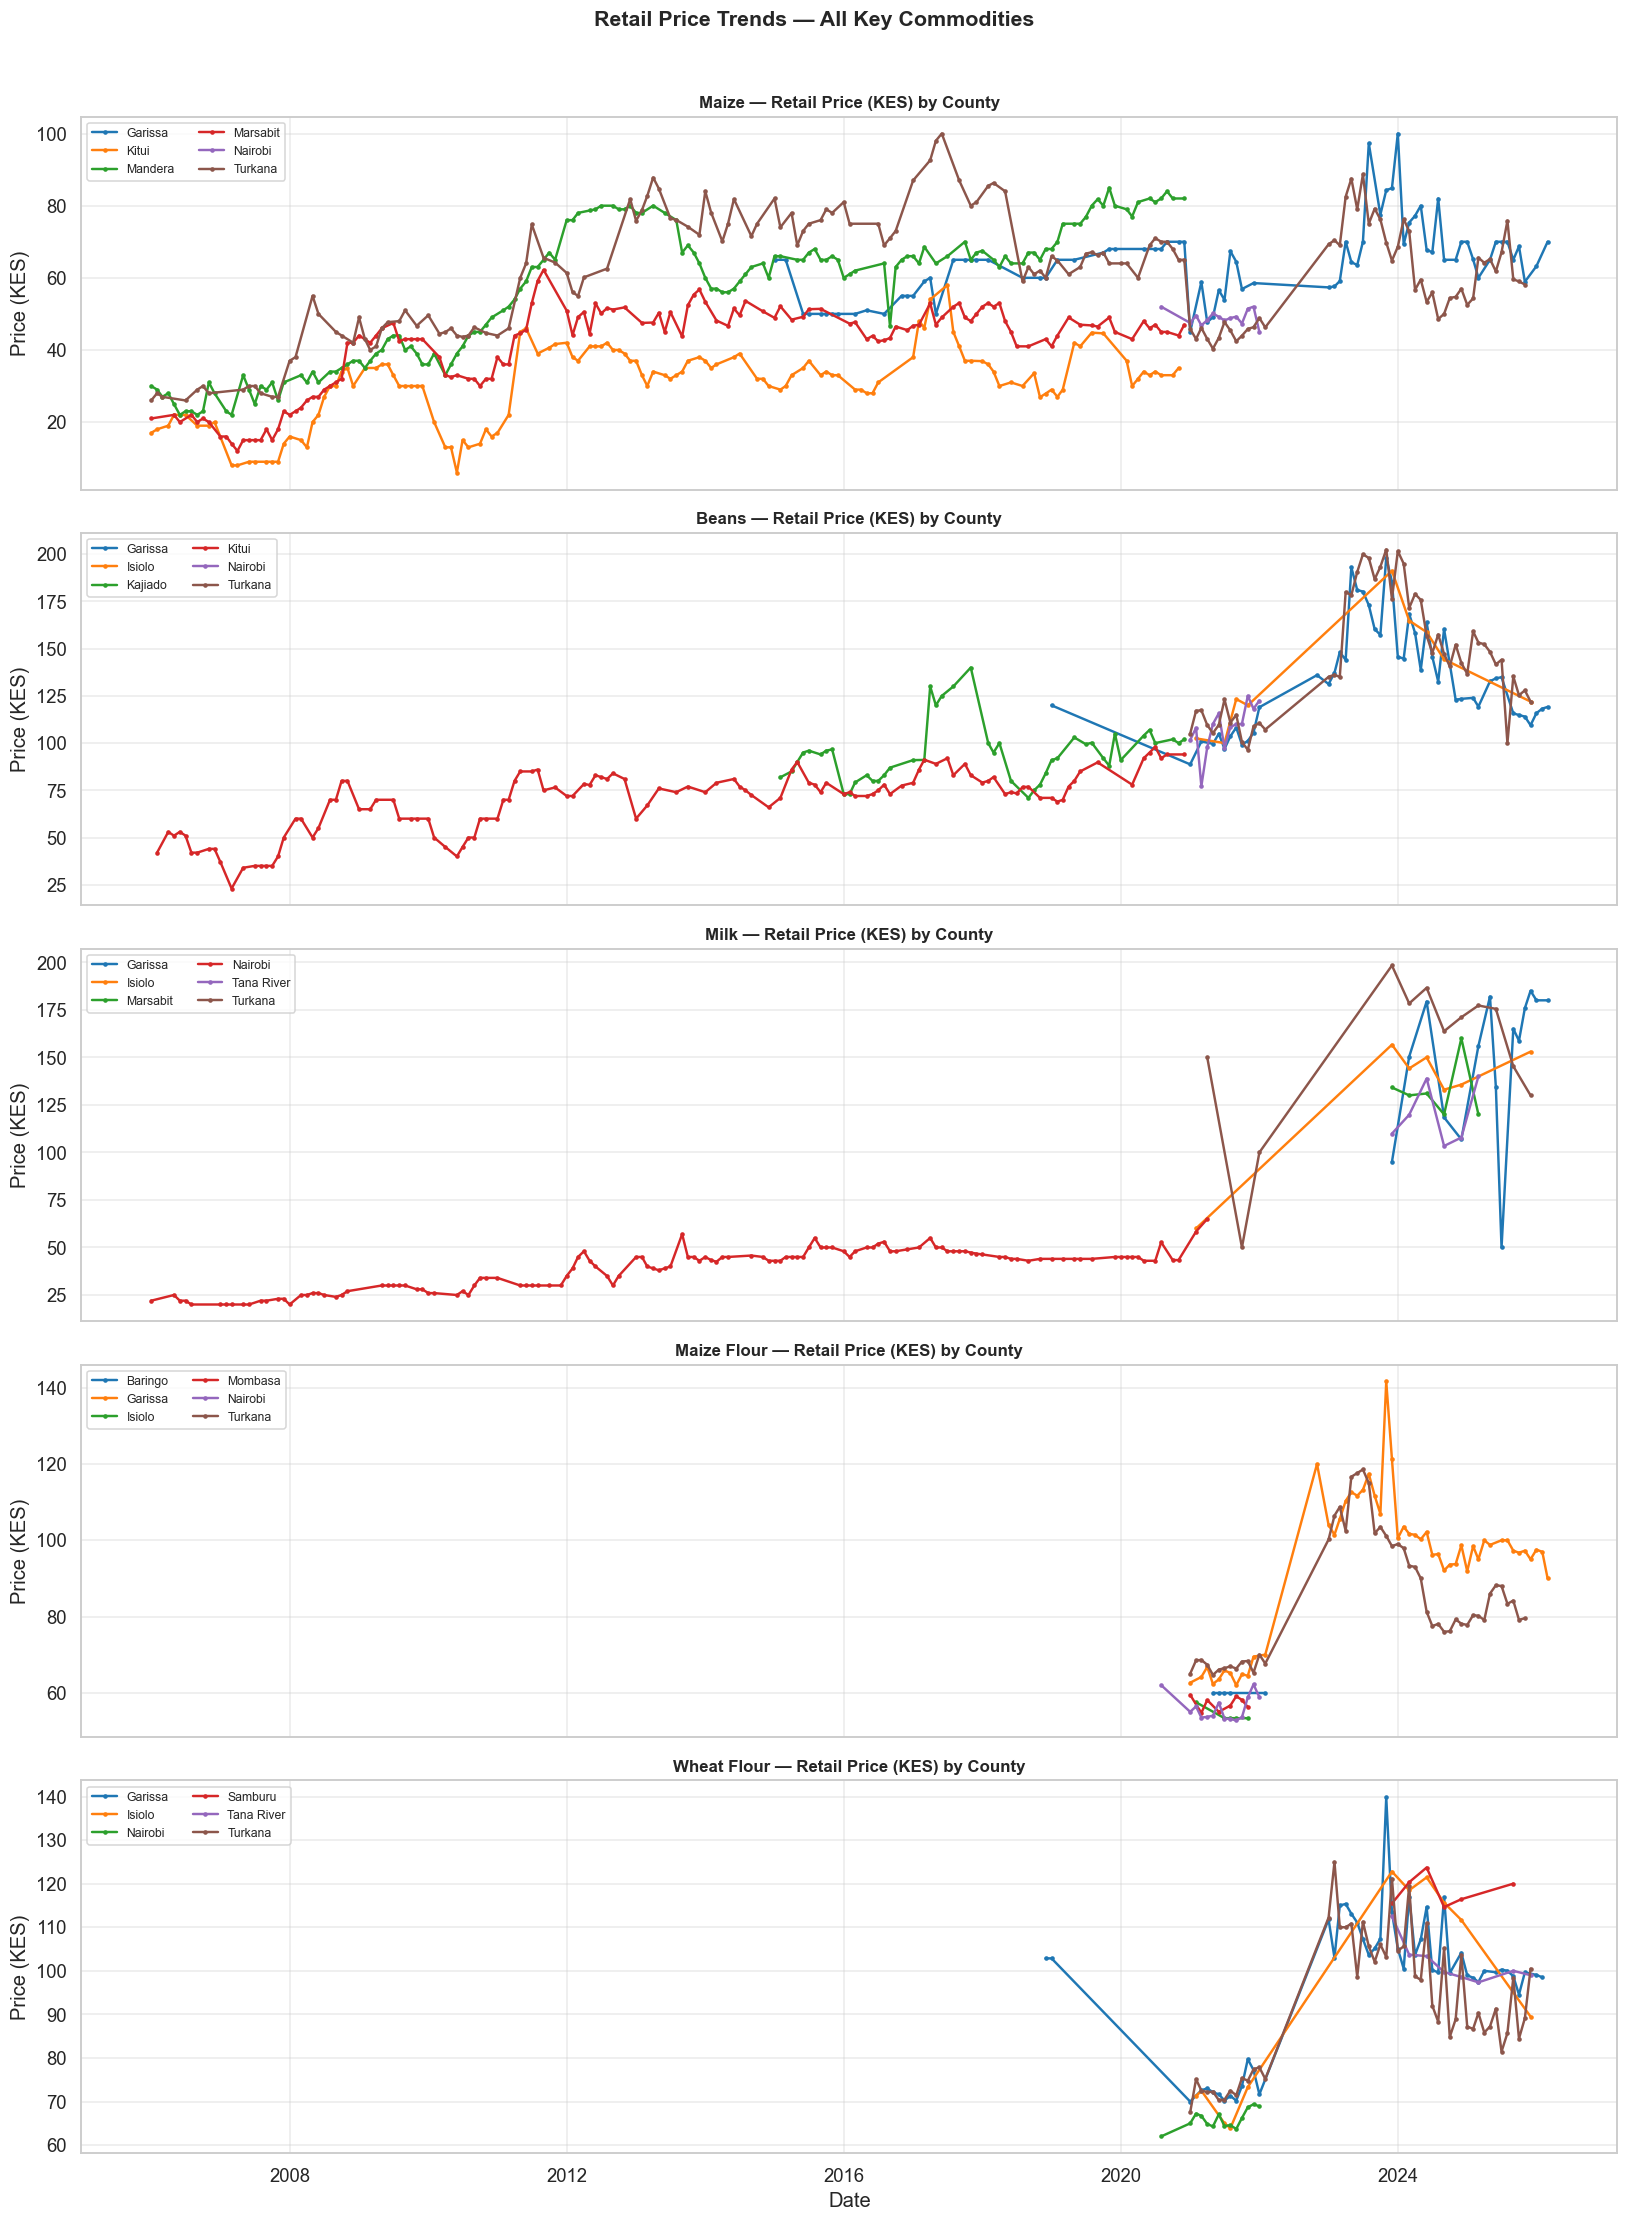

In [45]:
# Price trends for ALL key commodities across top counties
KEY_COMM_LIST = [c for c in ['Maize', 'Beans', 'Milk', 'Maize Flour', 'Wheat Flour'] 
                 if c in df['commodity'].unique()]

n_comm = len(KEY_COMM_LIST)
fig, axes = plt.subplots(n_comm, 1, figsize=(15, 4 * n_comm), sharex=True)
if n_comm == 1:
    axes = [axes]

palette = sns.color_palette('tab10', 8)

for ax, commodity in zip(axes, KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity].copy()
    top_counties = sub.groupby('county')['n_obs'].sum().nlargest(6).index.tolist()
    sub_top = sub[sub['county'].isin(top_counties)]
    for j, (county, grp) in enumerate(sub_top.groupby('county')):
        ax.plot(grp['date_month'], grp['price'], label=county,
                lw=1.6, marker='o', ms=2, color=palette[j])
    ax.set_title(f'{commodity} — Retail Price (KES) by County', fontweight='bold', fontsize=11)
    ax.set_ylabel('Price (KES)')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.suptitle('Retail Price Trends — All Key Commodities', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5.2. Price Distribution & Spread by Commodity

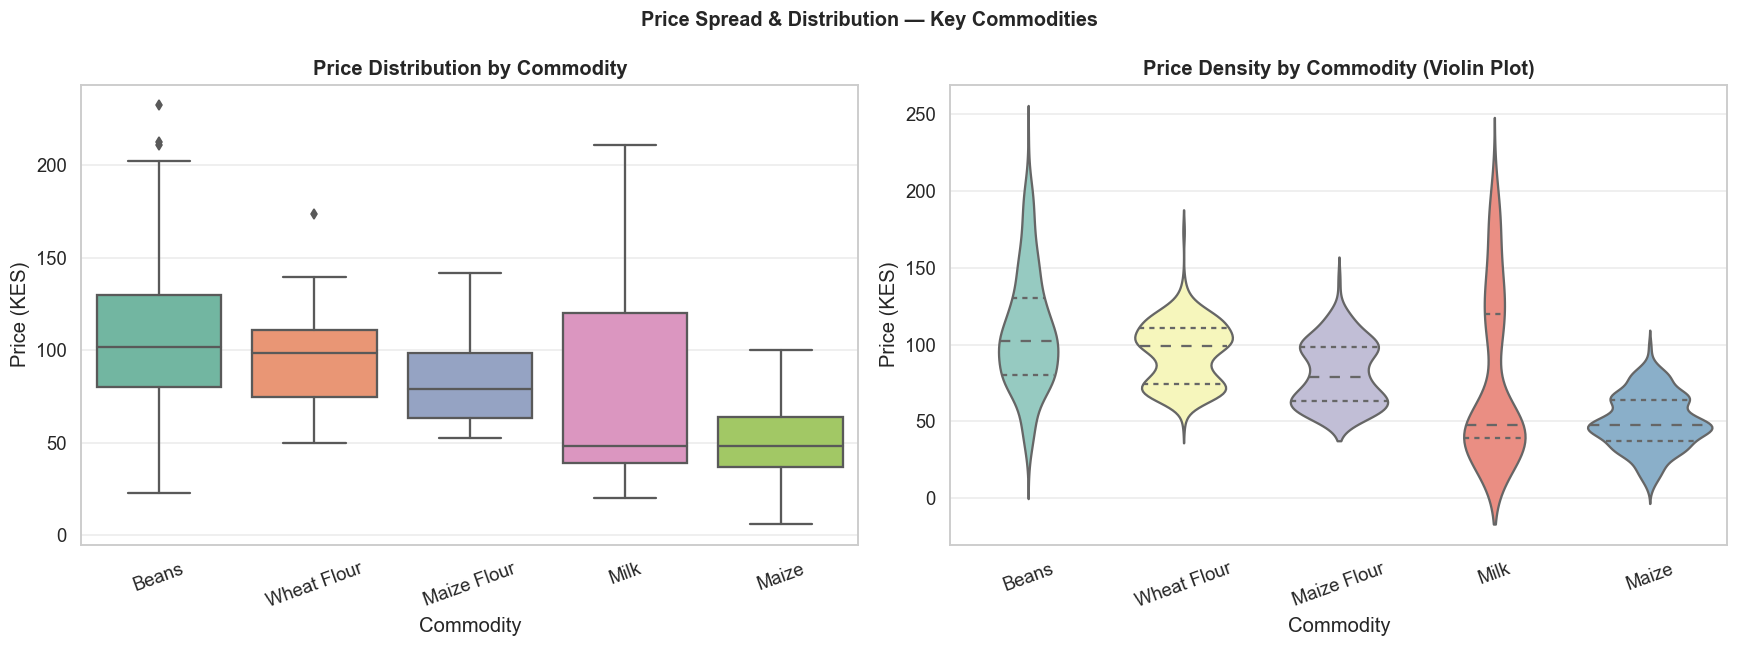


Descriptive Statistics — Key Commodities:
               N   Mean   Std   Min    Q1  Median     Q3    Max
commodity                                                      
Beans        404  108.4  38.5  23.0  80.0   102.0  130.0  232.3
Maize        799   49.7  17.8   6.0  37.0    48.0   64.0  100.0
Maize Flour  140   81.1  20.5  52.7  63.3    79.1   98.7  141.7
Milk         207   76.2  53.4  20.0  39.0    48.0  120.0  211.0
Wheat Flour  203   94.5  20.1  50.0  74.6    98.8  110.9  173.8


In [46]:
# Box plots + violin plots — price spread per commodity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
df_key = df[df['commodity'].isin(KEY_COMM_LIST)].copy()
comm_order = df_key.groupby('commodity')['price'].median().sort_values(ascending=False).index.tolist()

sns.boxplot(data=df_key, x='commodity', y='price', order=comm_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Price Distribution by Commodity', fontweight='bold')
axes[0].set_xlabel('Commodity')
axes[0].set_ylabel('Price (KES)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.4)

# Violin plot
sns.violinplot(data=df_key, x='commodity', y='price', order=comm_order,
               palette='Set3', ax=axes[1], inner='quartile')
axes[1].set_title('Price Density by Commodity (Violin Plot)', fontweight='bold')
axes[1].set_xlabel('Commodity')
axes[1].set_ylabel('Price (KES)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Price Spread & Distribution — Key Commodities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print('\nDescriptive Statistics — Key Commodities:')
print('=' * 70)
stats = df_key.groupby('commodity')['price'].agg(['count','mean','std','min',
         lambda x: x.quantile(0.25), 'median',
         lambda x: x.quantile(0.75), 'max'])
stats.columns = ['N','Mean','Std','Min','Q1','Median','Q3','Max']
print(stats.round(1).to_string())


## 5.3. Rainfall Mirror Effect — All Commodities

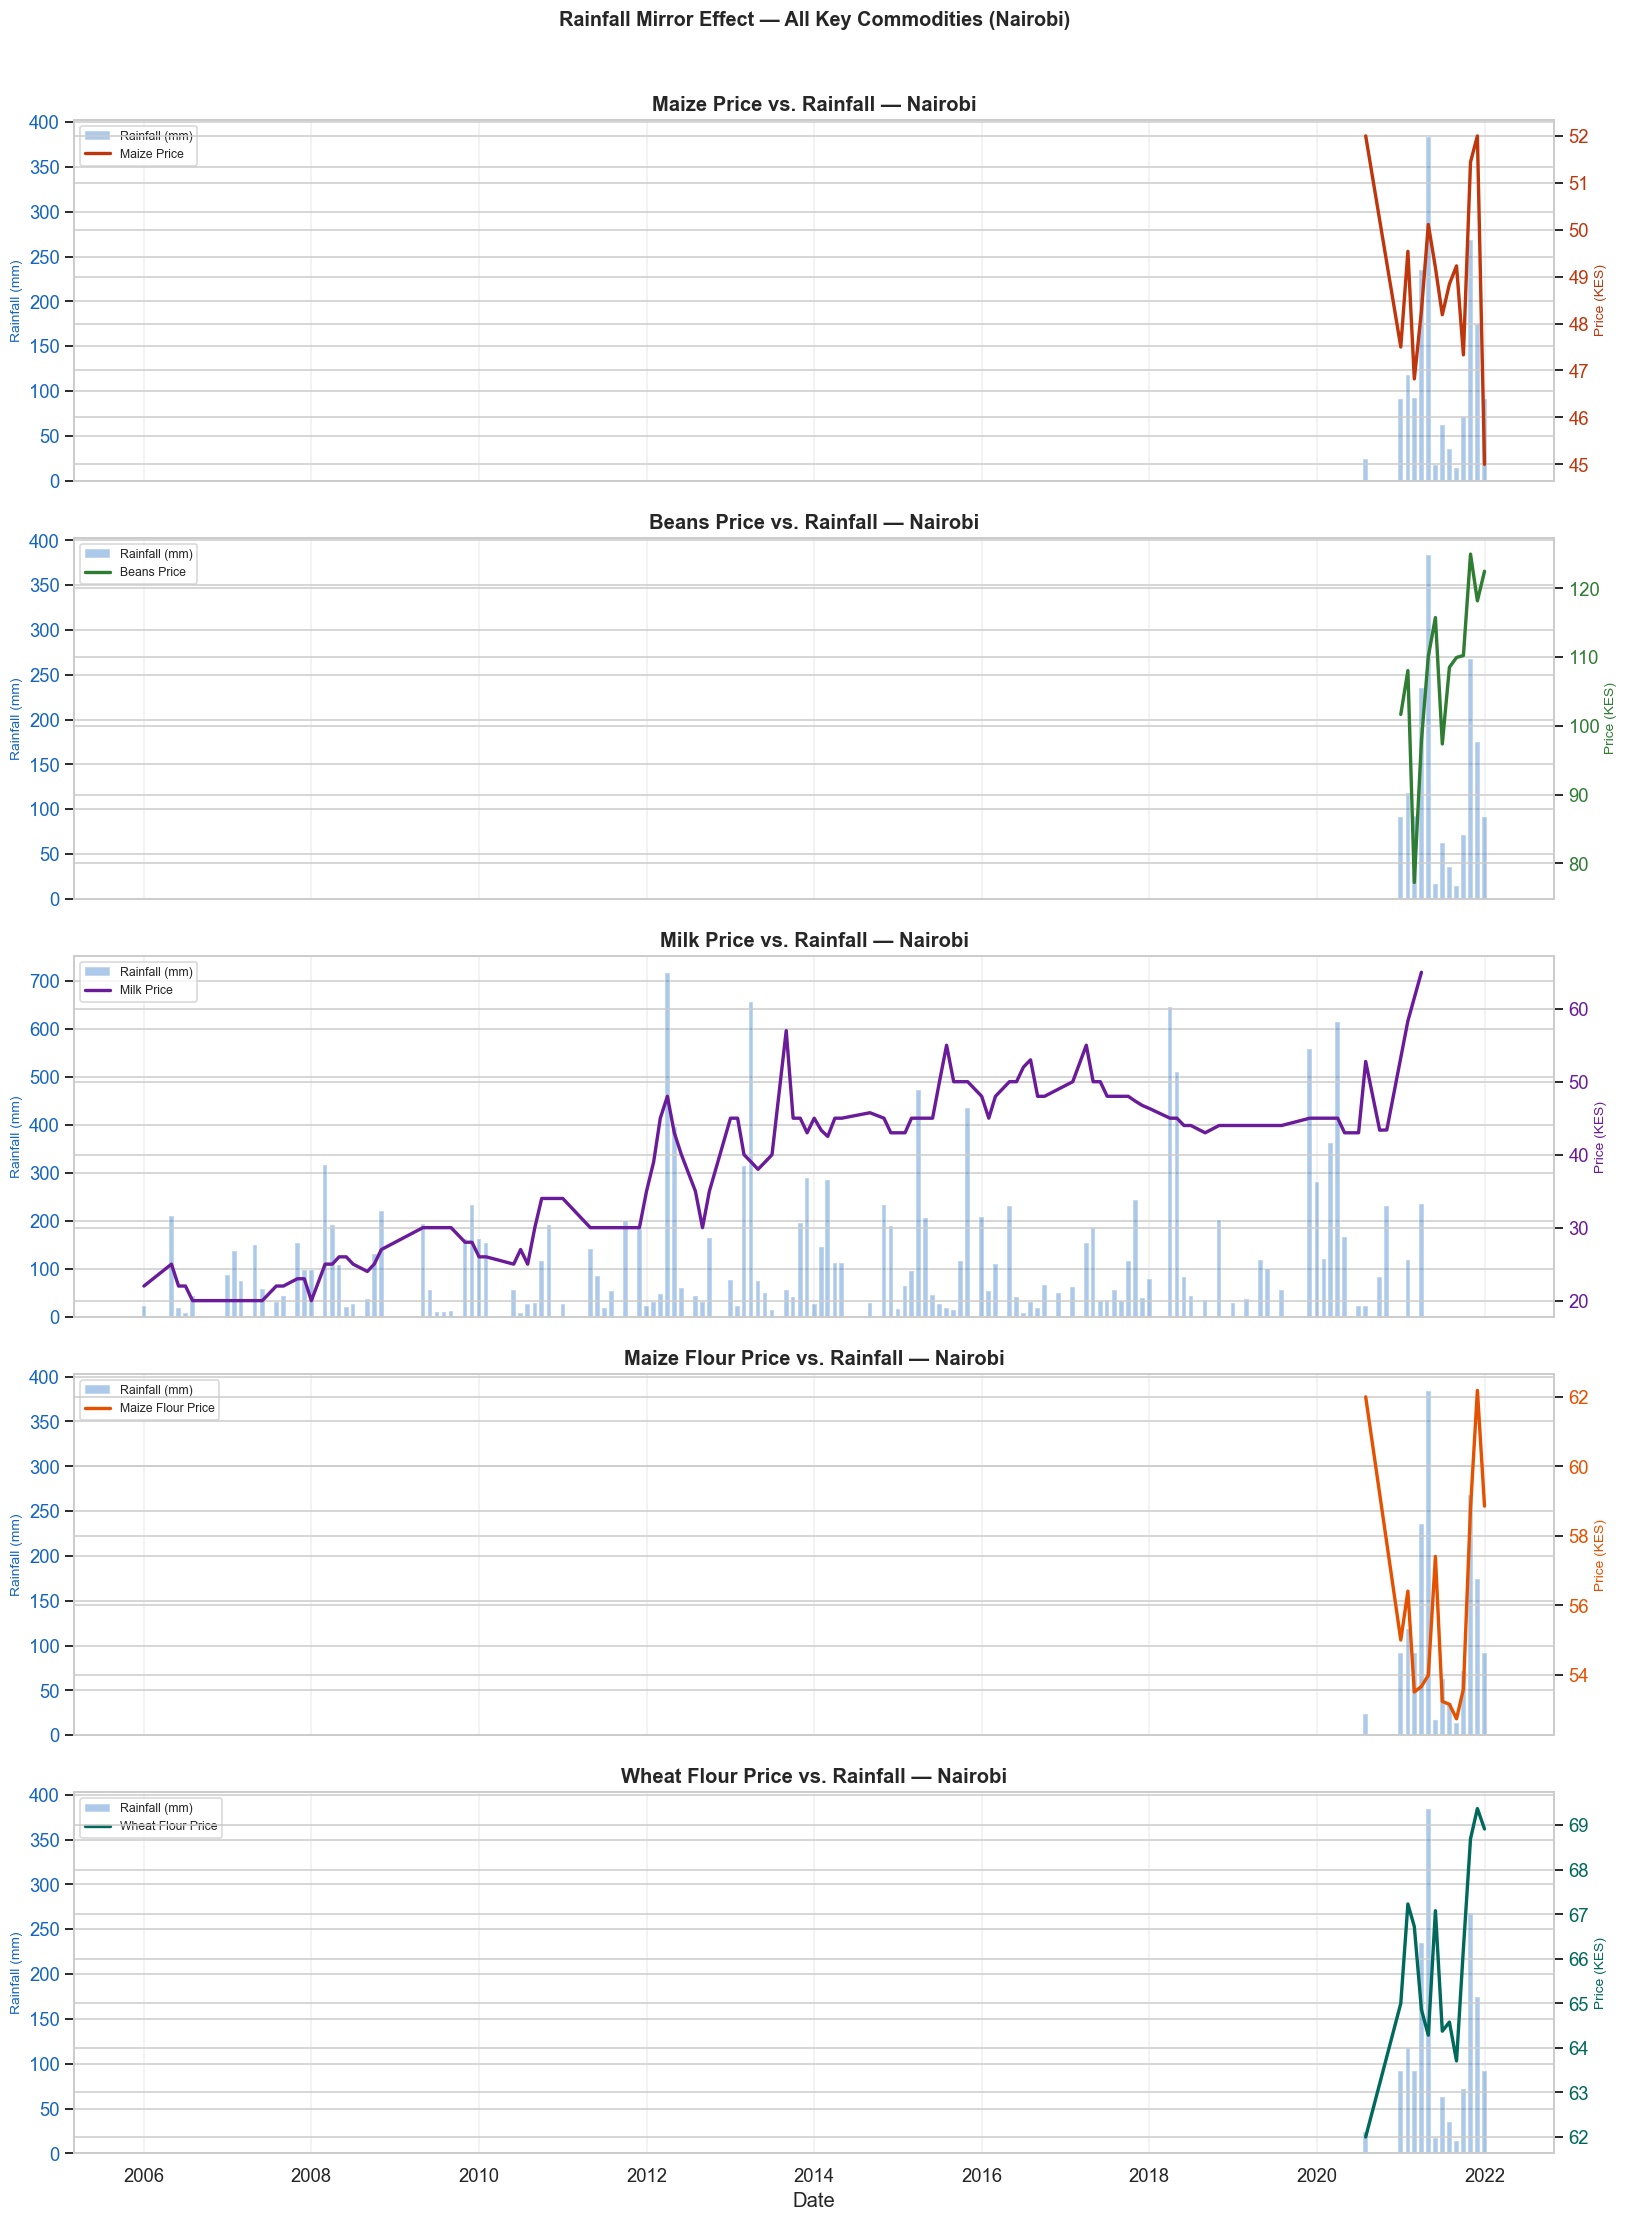

In [47]:
# Rainfall mirror effect for ALL key commodities — Nairobi
focus_county = 'Nairobi'
color_rain   = '#1565C0'
color_palette = ['#BF360C','#2E7D32','#6A1B9A','#E65100','#00695C']

n_c = len(KEY_COMM_LIST)
fig, axes = plt.subplots(n_c, 1, figsize=(15, 4 * n_c), sharex=True)
if n_c == 1:
    axes = [axes]

for ax, commodity, col in zip(axes, KEY_COMM_LIST, color_palette):
    subset = df[
        (df['county'] == focus_county) &
        (df['commodity'] == commodity)
    ].dropna(subset=['price', 'rainfall_mm'])

    if subset.empty:
        ax.set_title(f'{commodity} — No data for {focus_county}')
        continue

    ax_r = ax.twinx()
    ax.bar(subset['date_month'], subset['rainfall_mm'],
           color=color_rain, alpha=0.35, label='Rainfall (mm)', width=20)
    ax.set_ylabel('Rainfall (mm)', color=color_rain, fontsize=9)
    ax.tick_params(axis='y', labelcolor=color_rain)

    ax_r.plot(subset['date_month'], subset['price'],
              color=col, lw=2.2, label=f'{commodity} Price')
    ax_r.set_ylabel('Price (KES)', color=col, fontsize=9)
    ax_r.tick_params(axis='y', labelcolor=col)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_r.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    ax.set_title(f'{commodity} Price vs. Rainfall — {focus_county}', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.suptitle(f'Rainfall Mirror Effect — All Key Commodities ({focus_county})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5.4. Correlation Heatmap — All Commodities

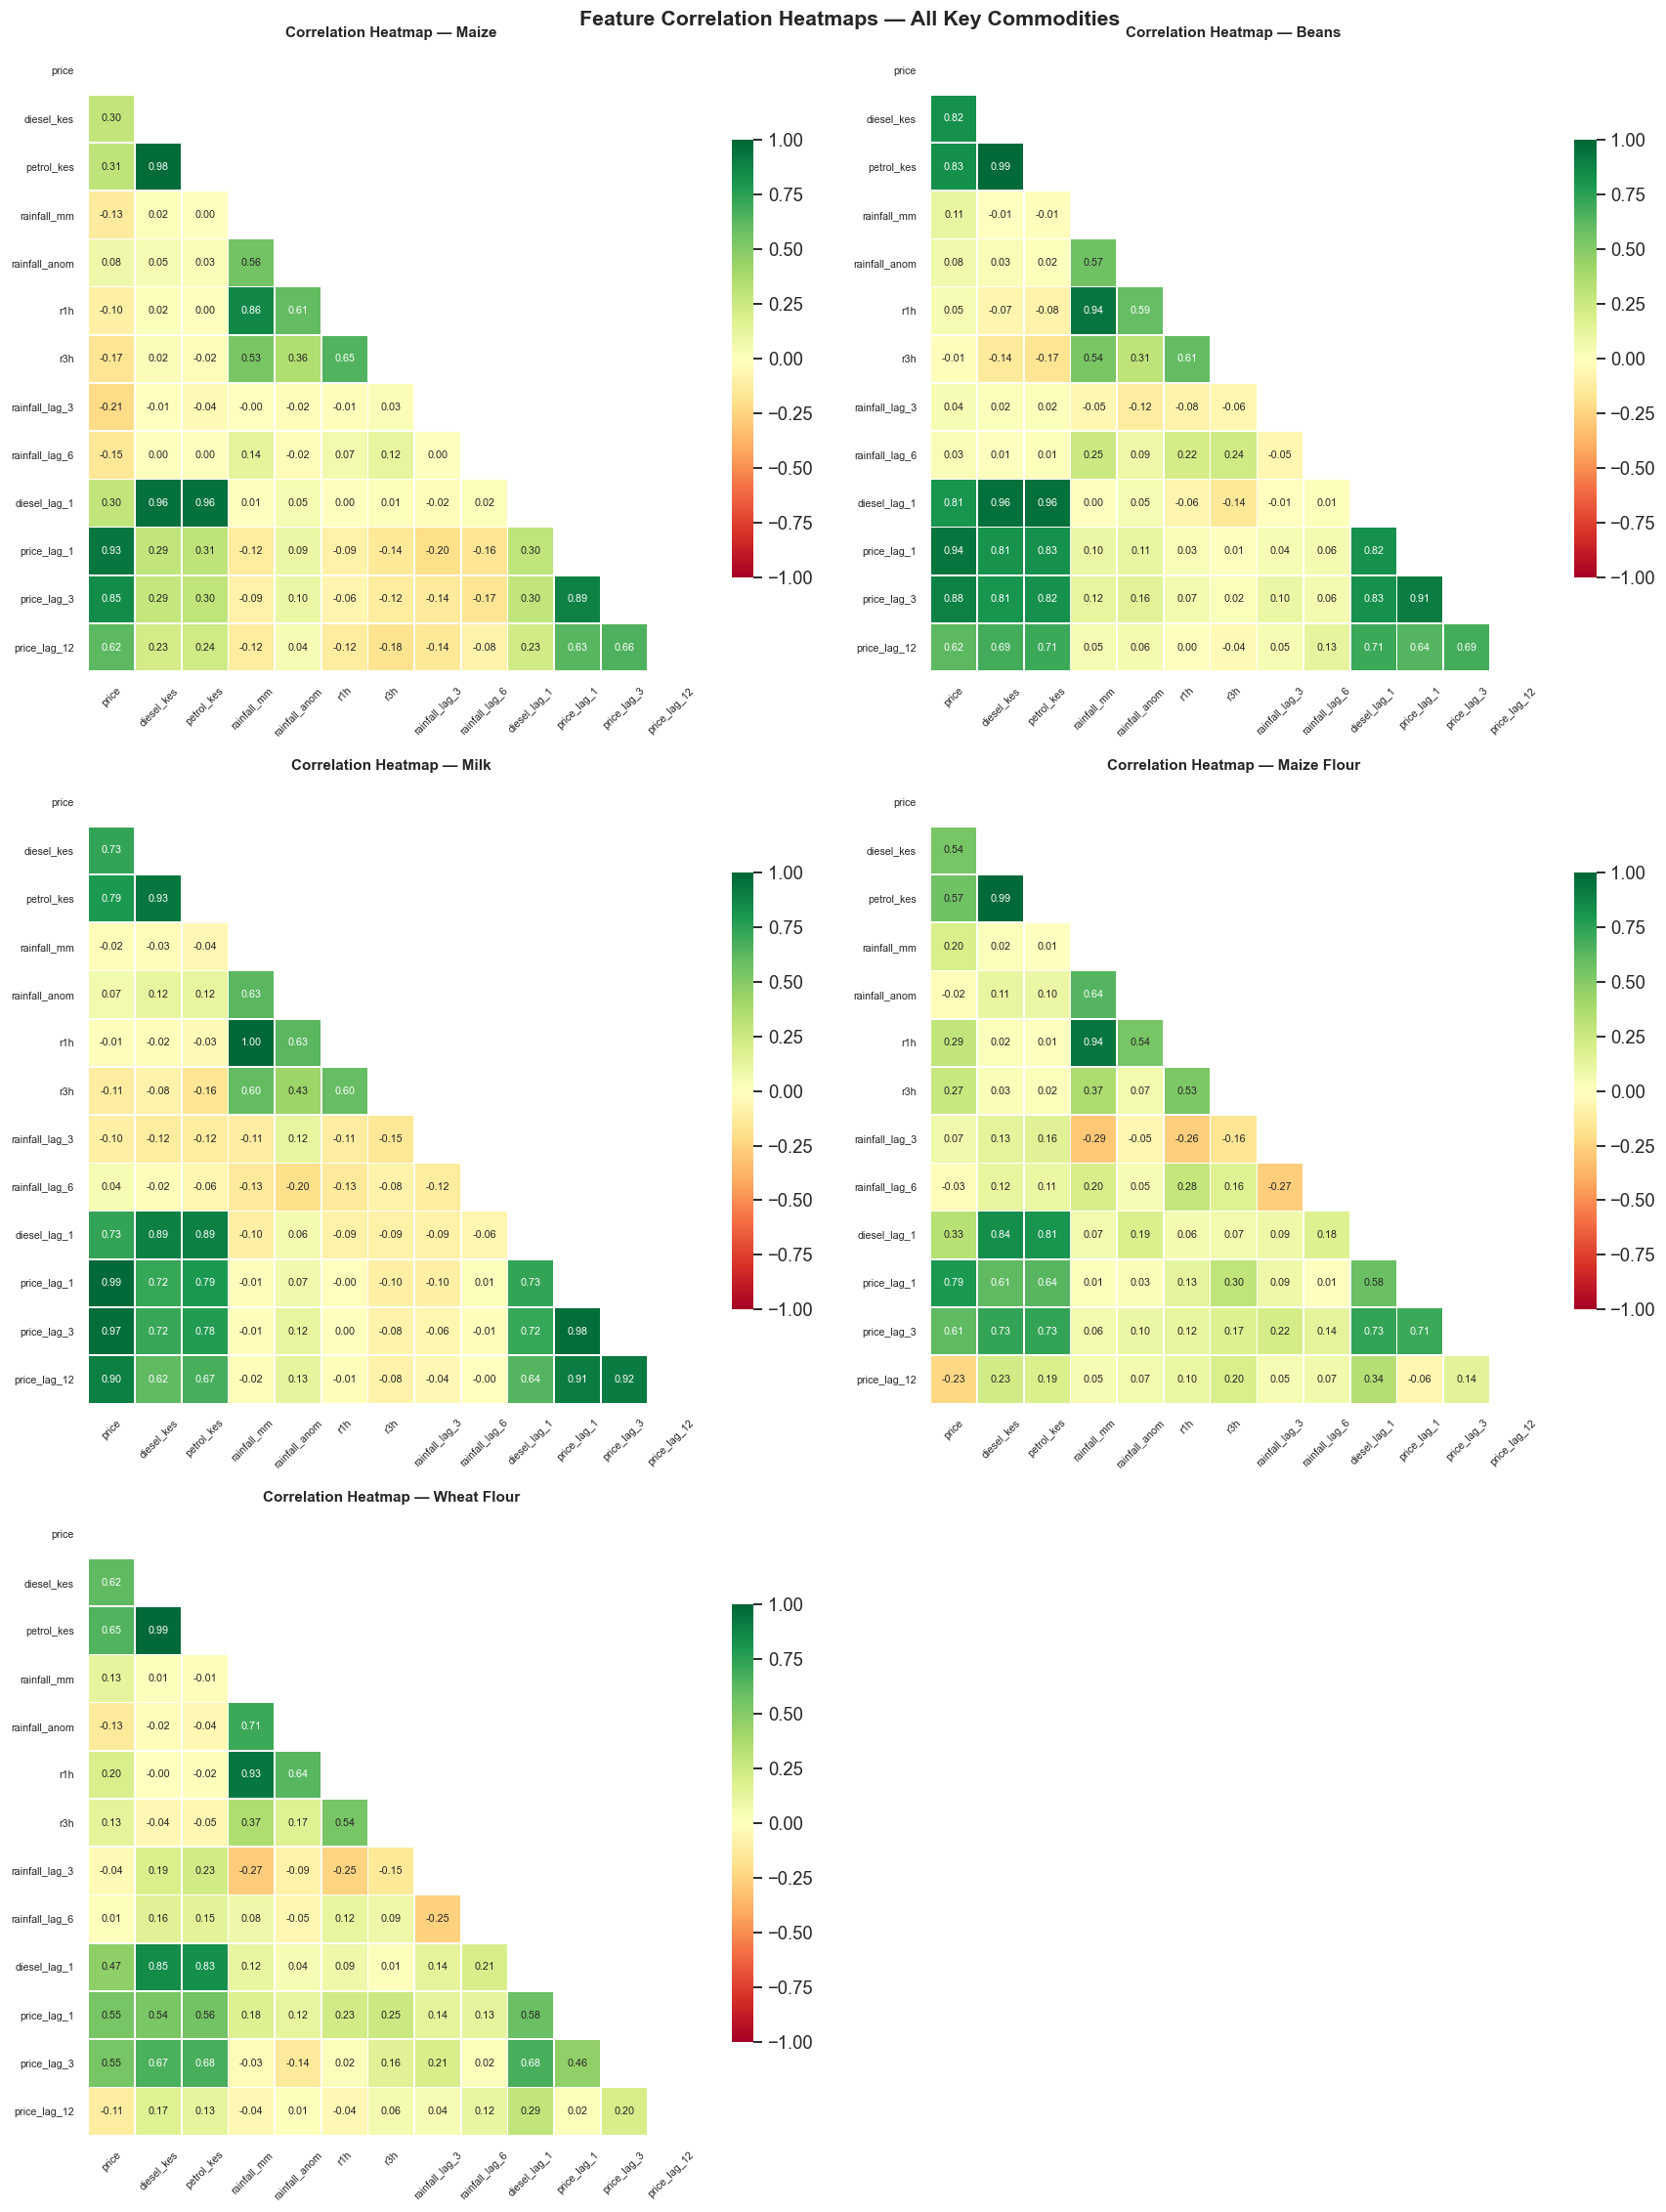


Top Feature Correlations with Price:

  Maize:
    price_lag_1               0.935
    price_lag_3               0.849
    price_lag_12              0.620
    petrol_kes                0.308

  Beans:
    price_lag_1               0.940
    price_lag_3               0.883
    petrol_kes                0.834
    diesel_kes                0.821

  Milk:
    price_lag_1               0.987
    price_lag_3               0.970
    price_lag_12              0.901
    petrol_kes                0.795

  Maize Flour:
    price_lag_1               0.794
    price_lag_3               0.611
    petrol_kes                0.570
    diesel_kes                0.541

  Wheat Flour:
    petrol_kes                0.649
    diesel_kes                0.615
    price_lag_1               0.546
    price_lag_3               0.545


In [48]:
# Correlation heatmaps for each key commodity
corr_cols = [
    'price', 'diesel_kes', 'petrol_kes',
    'rainfall_mm', 'rainfall_anom', 'r1h', 'r3h',
    'rainfall_lag_3', 'rainfall_lag_6',
    'diesel_lag_1', 'price_lag_1', 'price_lag_3', 'price_lag_12'
]

n_c = len(KEY_COMM_LIST)
cols_grid = 2
rows_grid = (n_c + 1) // 2
fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, 7 * rows_grid))
axes = axes.flatten()

for i, commodity in enumerate(KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity][corr_cols].dropna()
    if sub.empty or len(sub) < 5:
        axes[i].set_title(f'{commodity} — Insufficient data')
        continue
    corr_m = sub.corr()
    mask   = np.triu(np.ones_like(corr_m, dtype=bool))
    sns.heatmap(corr_m, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, linewidths=0.4,
                ax=axes[i], annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
    axes[i].set_title(f'Correlation Heatmap — {commodity}', fontweight='bold', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].tick_params(axis='y', labelsize=7)

# Hide any unused subplot
for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Correlation Heatmaps — All Key Commodities',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top correlations with price for each commodity
print('\nTop Feature Correlations with Price:')
print('=' * 65)
for commodity in KEY_COMM_LIST:
    sub = df[df['commodity'] == commodity][corr_cols].dropna()
    if sub.empty:
        continue
    top_corr = sub.corr()['price'].drop('price').abs().sort_values(ascending=False).head(4)
    print(f'\n  {commodity}:')
    for feat, val in top_corr.items():
        print(f'    {feat:<25} {val:.3f}')


## 5.5. Seasonal Price Patterns — All Key Commodities

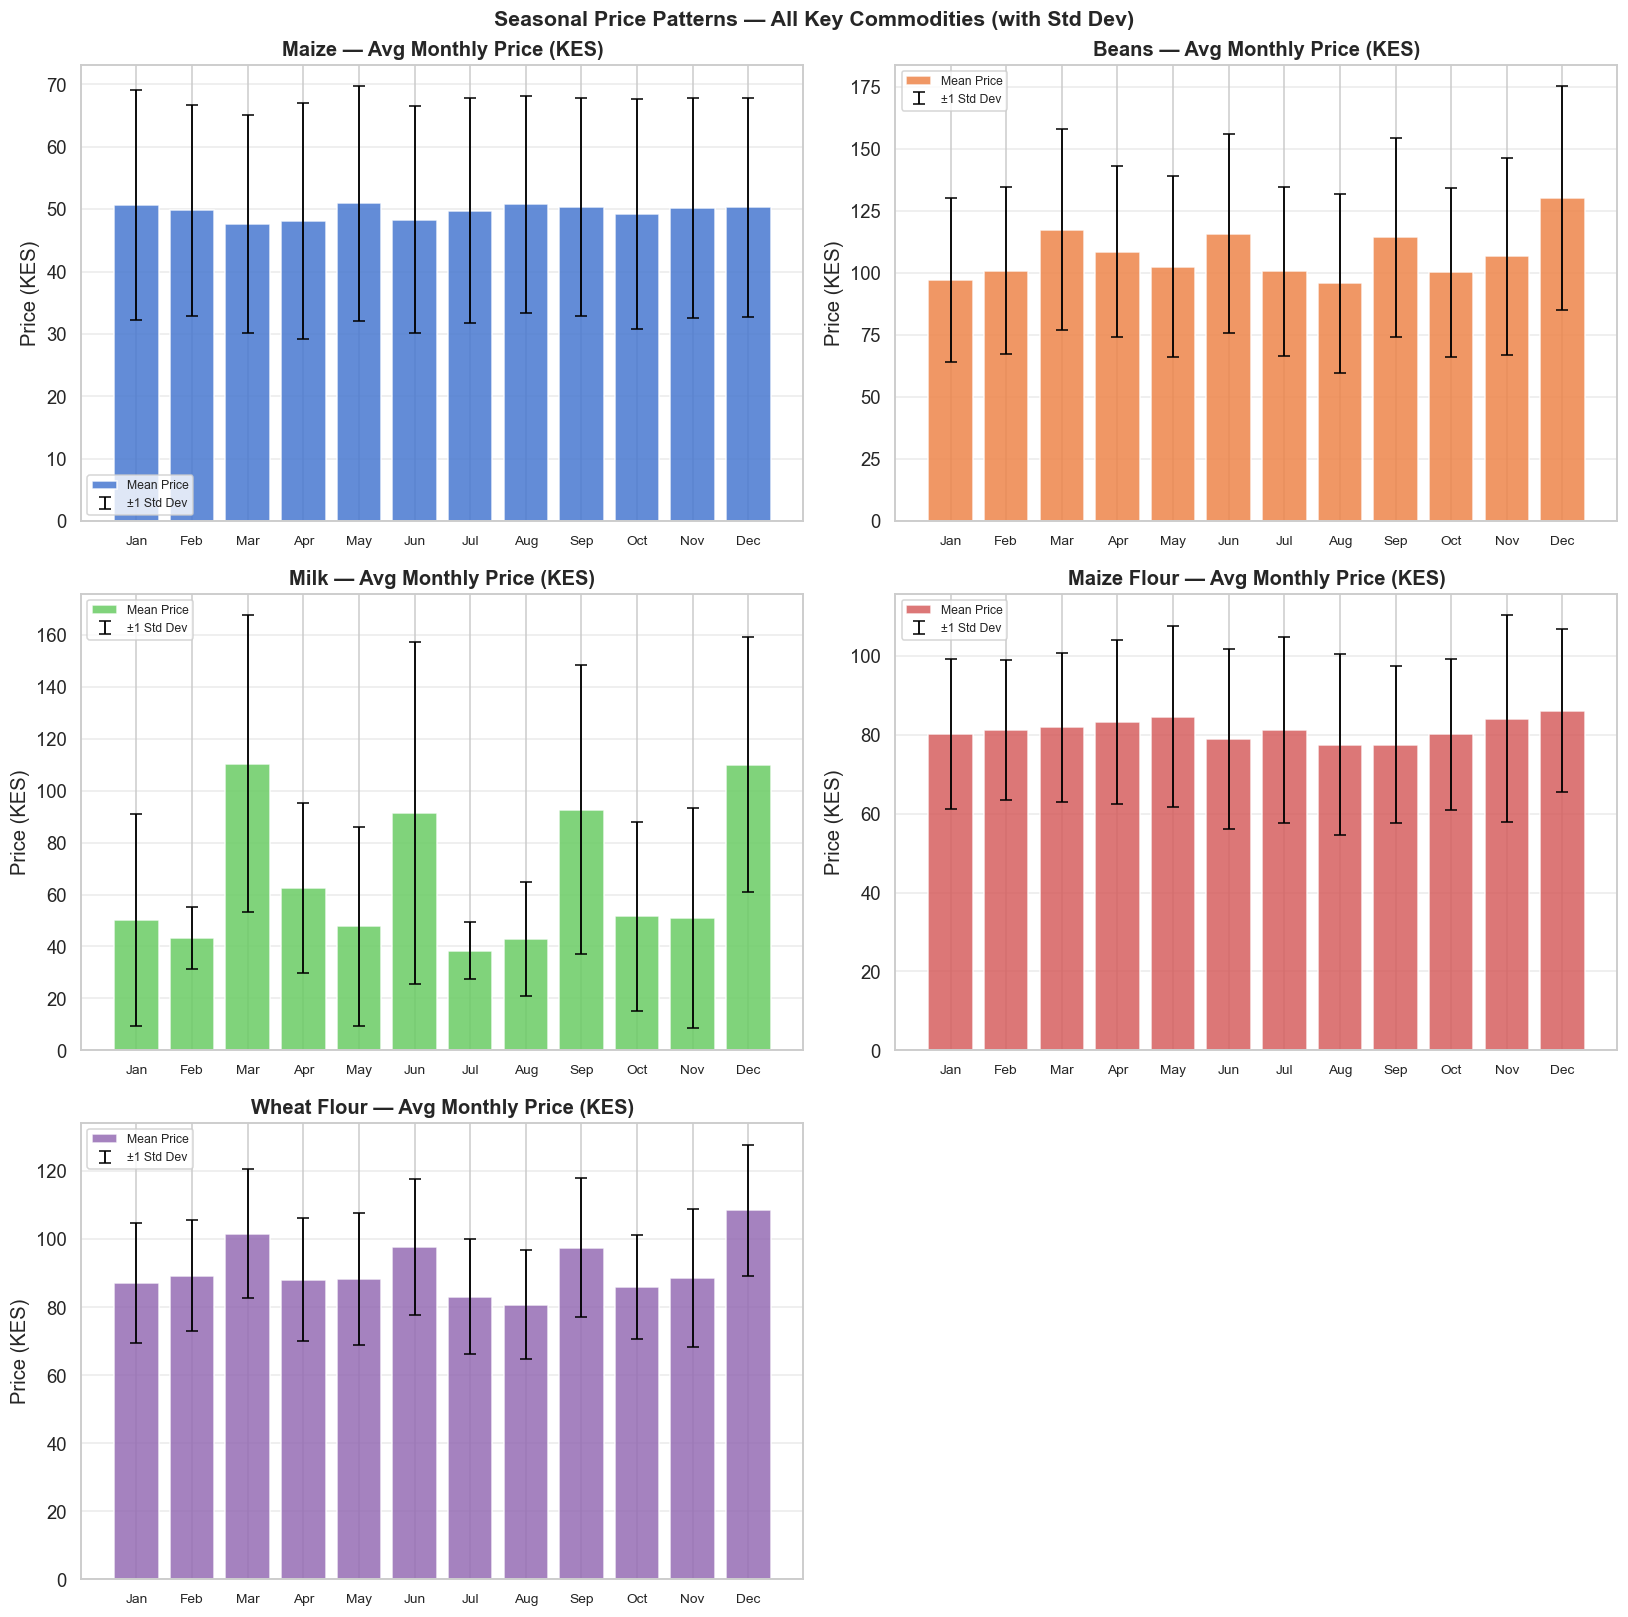

In [49]:
# Monthly seasonality for all key commodities
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

n_c  = len(KEY_COMM_LIST)
cols = 2
rows = (n_c + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

palette = sns.color_palette('muted', n_c)

for i, commodity in enumerate(KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity].copy()
    if sub.empty:
        axes[i].set_title(f'{commodity} — No Data')
        continue
    seasonal = sub.groupby('month')['price'].agg(['mean','std']).reindex(range(1, 13))
    axes[i].bar(seasonal.index, seasonal['mean'],
                color=palette[i], edgecolor='white', alpha=0.85, label='Mean Price')
    axes[i].errorbar(seasonal.index, seasonal['mean'], yerr=seasonal['std'],
                     fmt='none', color='black', capsize=4, lw=1.2, label='±1 Std Dev')
    axes[i].set_title(f'{commodity} — Avg Monthly Price (KES)', fontweight='bold')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, fontsize=9)
    axes[i].set_ylabel('Price (KES)')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.4)

# Hide unused
for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Seasonal Price Patterns — All Key Commodities (with Std Dev)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5.6. County-Level Average Prices — Heatmap

In [50]:
# Pivot: commodity × county mean price
pivot_county = (
    df[df['commodity'].isin(KEY_COMM_LIST)]
    .groupby(['commodity', 'county'])['price']
    .mean()
    .unstack('county')
)

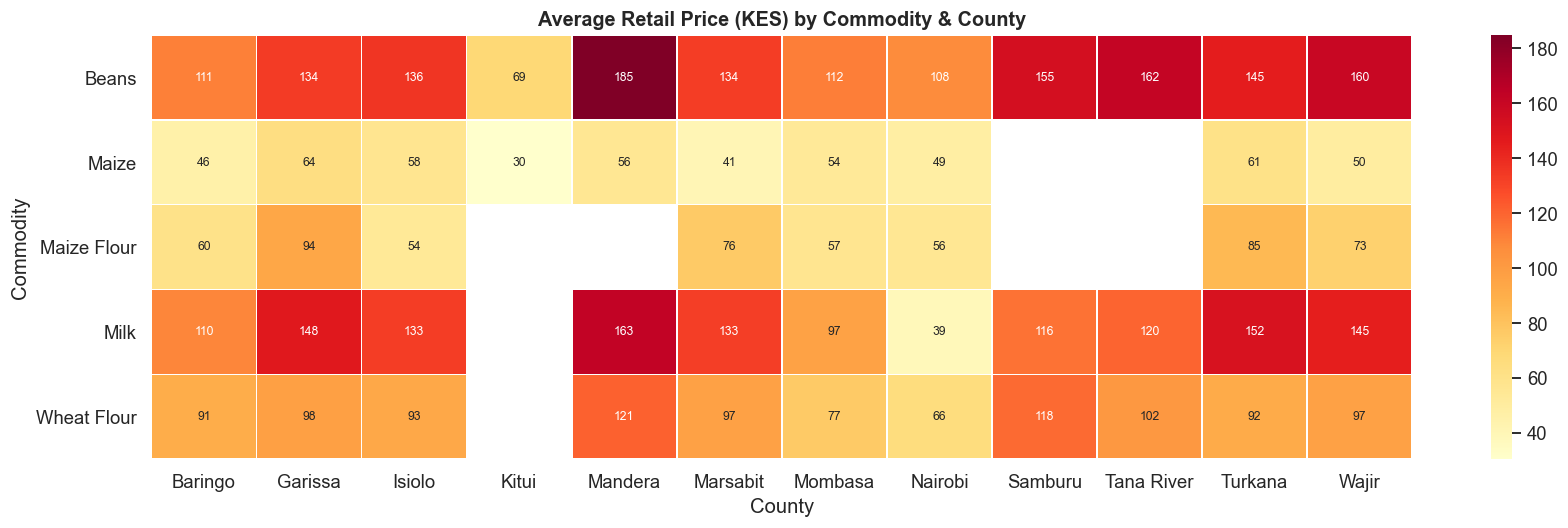

In [51]:
# Keep top 12 counties by data volume
top12 = df.groupby('county')['n_obs'].sum().nlargest(12).index
pivot_county = pivot_county[pivot_county.columns.intersection(top12)]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_county, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Average Retail Price (KES) by Commodity & County',
             fontsize=13, fontweight='bold')
ax.set_xlabel('County')
ax.set_ylabel('Commodity')
plt.tight_layout()
plt.show()


## 5.7. Year-over-Year Price Change — All Commodities

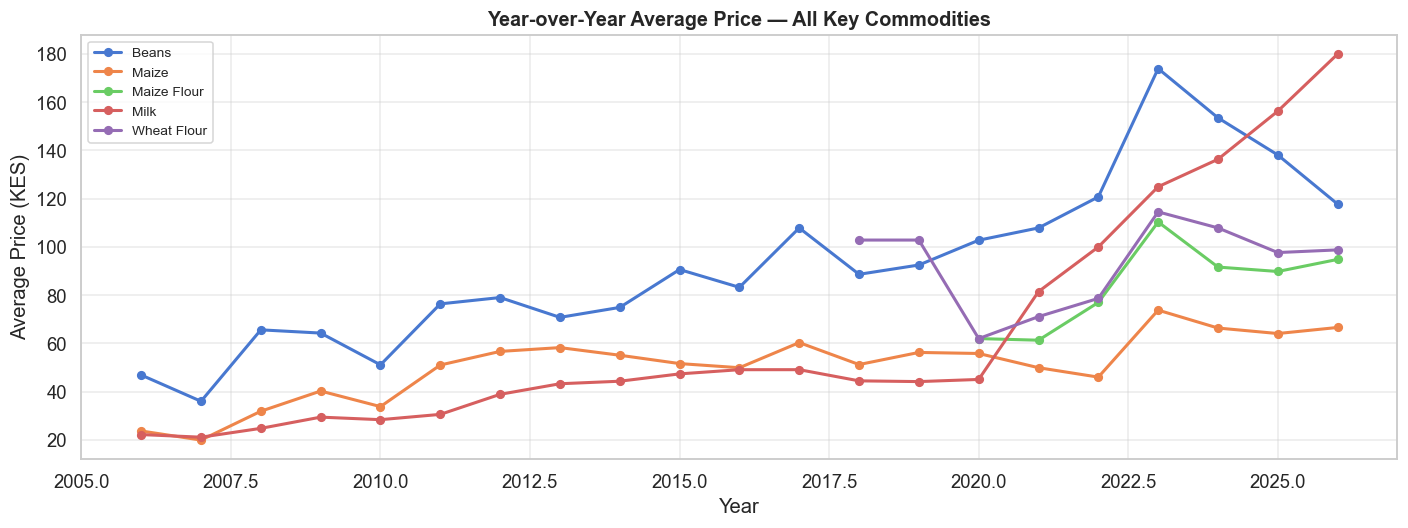

In [52]:
df_key2 = df[df['commodity'].isin(KEY_COMM_LIST)].copy()
yoy = (
    df_key2.groupby(['year', 'commodity'])['price']
    .mean()
    .reset_index()
)
yoy_pivot = yoy.pivot(index='year', columns='commodity', values='price')

fig, ax = plt.subplots(figsize=(13, 5))
for col in yoy_pivot.columns:
    ax.plot(yoy_pivot.index, yoy_pivot[col], marker='o', lw=2, ms=5, label=col)
ax.set_title('Year-over-Year Average Price — All Key Commodities',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Average Price (KES)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [53]:
# YoY % change table
yoy_pct = yoy_pivot.pct_change() * 100
print('Year-over-Year Price Change (%):')
print(yoy_pct.round(1).to_string())


Year-over-Year Price Change (%):
commodity  Beans  Maize  Maize Flour  Milk  Wheat Flour
year                                                   
2006         NaN    NaN          NaN   NaN          NaN
2007       -23.2  -15.9          NaN  -4.9          NaN
2008        82.3   60.0          NaN  17.4          NaN
2009        -2.0   26.3          NaN  18.8          NaN
2010       -20.5  -16.1          NaN  -3.6          NaN
2011        49.5   51.0          NaN   7.7          NaN
2012         3.4   11.1          NaN  27.2          NaN
2013       -10.4    2.8          NaN  11.3          NaN
2014         5.8   -5.4          NaN   2.4          NaN
2015        21.0   -6.3          NaN   6.9          NaN
2016        -8.1   -3.3          NaN   3.7          NaN
2017        29.6   20.9          NaN   0.0          NaN
2018       -17.8  -15.1          NaN  -9.4          NaN
2019         4.3    9.8          NaN  -0.7          0.0
2020        11.1   -0.8          NaN   2.0        -39.7
2021         5.

## 5.8. Fuel Cost vs Price Scatter — All Commodities

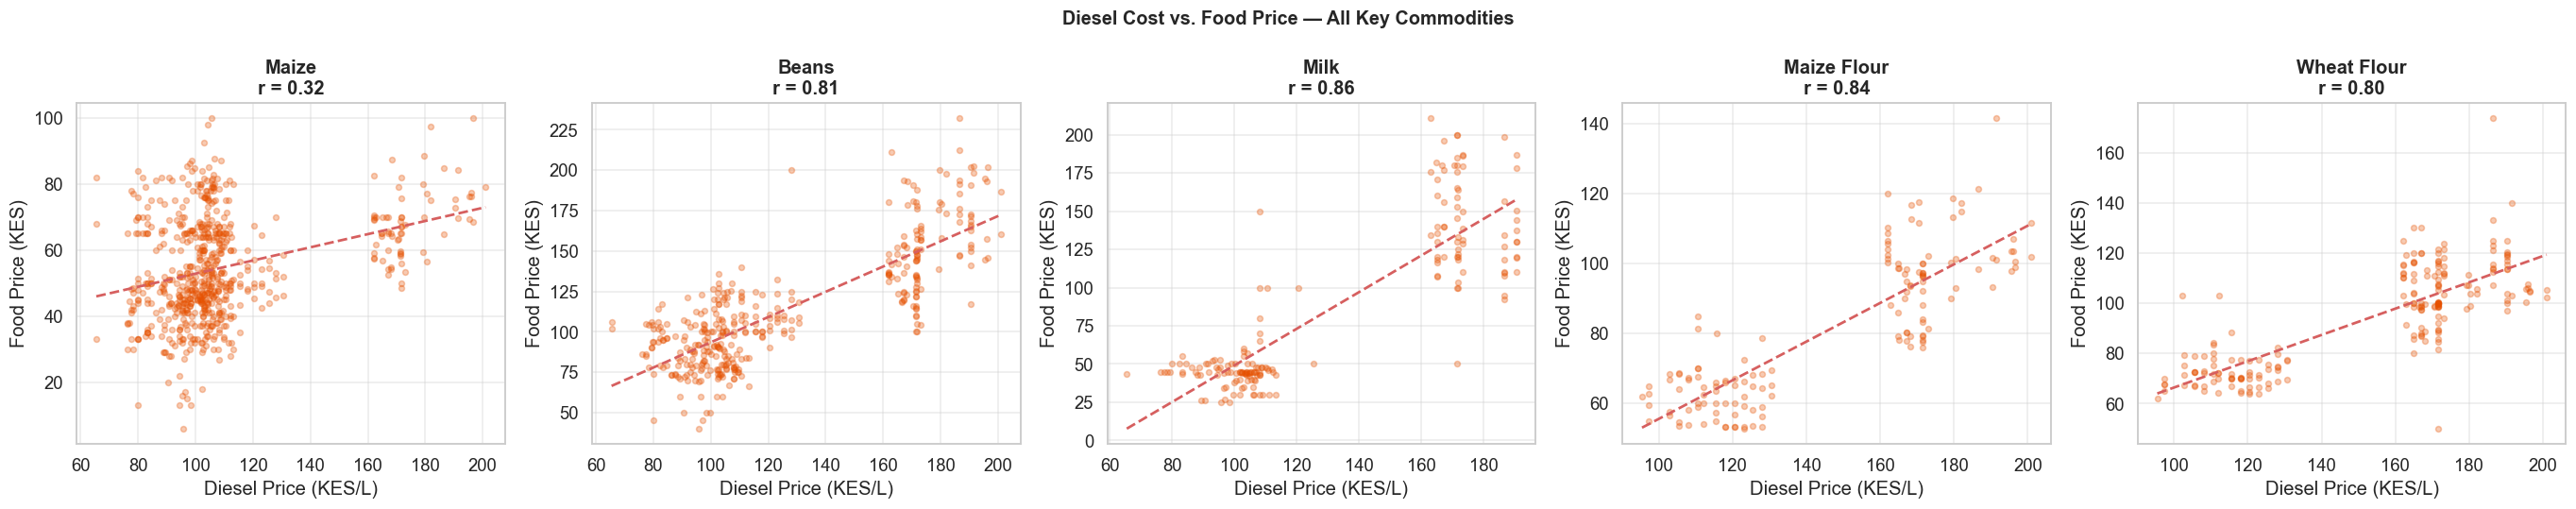

In [54]:
fig, axes = plt.subplots(1, len(KEY_COMM_LIST), figsize=(5 * len(KEY_COMM_LIST), 5))
if len(KEY_COMM_LIST) == 1:
    axes = [axes]

for ax, commodity in zip(axes, KEY_COMM_LIST):
    sub = df[df['commodity'] == commodity].dropna(subset=['diesel_kes', 'price'])
    if sub.empty:
        ax.set_title(f'{commodity}\nNo data')
        continue
    ax.scatter(sub['diesel_kes'], sub['price'], alpha=0.3, s=15, color='#E65100')
    # Trend line
    z = np.polyfit(sub['diesel_kes'], sub['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub['diesel_kes'].min(), sub['diesel_kes'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', lw=1.8)
    corr = sub[['diesel_kes', 'price']].corr().iloc[0, 1]
    ax.set_title(f'{commodity}\nr = {corr:.2f}', fontweight='bold')
    ax.set_xlabel('Diesel Price (KES/L)')
    ax.set_ylabel('Food Price (KES)')
    ax.grid(alpha=0.4)

plt.suptitle('Diesel Cost vs. Food Price — All Key Commodities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.9 Key Patterns Observed

In [55]:
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY EDA FINDINGS — ALL COMMODITIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Fuel-Driven Inflation  : All commodities show positive correlation with
                           diesel prices — transport costs affect every staple.
• Rainfall Mirror Effect : Price spikes follow dry periods (3–6 month lag)
                           most visibly in Maize and Beans.
• Seasonality            : Maize peaks Jan–Feb (pre-harvest lean season);
                           Milk is relatively stable year-round.
• County Variance        : Remote/arid counties (e.g. Turkana, Mandera)
                           consistently show higher prices than Nairobi.
• Autoregression         : price_lag_1 and price_lag_3 are the strongest
                           predictors across all commodities.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY EDA FINDINGS — ALL COMMODITIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Fuel-Driven Inflation  : All commodities show positive correlation with
                           diesel prices — transport costs affect every staple.
• Rainfall Mirror Effect : Price spikes follow dry periods (3–6 month lag)
                           most visibly in Maize and Beans.
• Seasonality            : Maize peaks Jan–Feb (pre-harvest lean season);
                           Milk is relatively stable year-round.
• County Variance        : Remote/arid counties (e.g. Turkana, Mandera)
                           consistently show higher prices than Nairobi.
• Autoregression         : price_lag_1 and price_lag_3 are the strongest
                           predictors across all commodities.




## 6. Modelling

### 6.1. Model Data Preparation

In [56]:
# Feature list for modelling
# Base numeric features (no categorical columns yet — OHE adds them below)
NUMERIC_FEATURE_COLS = [
    'year', 'month_sin', 'month_cos',
    'rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6',
    'rainfall_anom_lag_1', 'rainfall_anom_lag_3',
    'diesel_lag_1', 'diesel_lag_2',
    'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12',
    'price_rolling_3',
]
CATEGORICAL_COLS = ['county', 'commodity']
ALL_FEATURE_COLS  = NUMERIC_FEATURE_COLS + CATEGORICAL_COLS
TARGET            = 'price'

# Drop rows missing the target or mandatory lag anchors
df_model = df.dropna(subset=[TARGET, 'price_lag_1', 'price_lag_3', 'diesel_lag_1']).copy()

# Raw (unencoded) feature matrix — preprocessing happens inside the pipeline
X_raw = df_model[ALL_FEATURE_COLS].copy()
y     = df_model[TARGET]

# Preprocessing pipeline (fitted only on train data) 
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fill remaining NaNs
])

categorical_pipe = Pipeline([
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),  
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe,      NUMERIC_FEATURE_COLS),
        ('cat', categorical_pipe,  CATEGORICAL_COLS),
    ],
    remainder='drop'
)

print(f'Raw feature matrix : {X_raw.shape[0]:,} rows × {X_raw.shape[1]} columns')
print(f'  Numeric cols  : {len(NUMERIC_FEATURE_COLS)}')
print(f'  Categorical   : {CATEGORICAL_COLS}')
print(f'Target            : {TARGET}  mean={y.mean():.1f} KES  std={y.std():.1f} KES')
print()

Raw feature matrix : 1,353 rows × 17 columns
  Numeric cols  : 15
  Categorical   : ['county', 'commodity']
Target            : price  mean=78.1 KES  std=36.6 KES



Temporal train/test split

In [57]:
# train/test split
# Use data before 2024 for training, 2024+ for testing
split_date = pd.Timestamp('2024-01-01')
train_mask = df_model['date_month'] < split_date
test_mask  = df_model['date_month'] >= split_date

X_train_raw, X_test_raw = X_raw[train_mask],  X_raw[test_mask]
y_train,      y_test     = y[train_mask],       y[test_mask]

print(f'Training set : {X_train_raw.shape[0]:,} rows  '
      f'({df_model[train_mask]["date_month"].min().date()} → '
      f'{df_model[train_mask]["date_month"].max().date()})')
print(f'Test set     : {X_test_raw.shape[0]:,} rows  '
      f'({df_model[test_mask]["date_month"].min().date()} → '
      f'{df_model[test_mask]["date_month"].max().date()})')

Training set : 1,059 rows  (2010-02-01 → 2023-12-01)
Test set     : 294 rows  (2024-01-01 → 2026-03-01)


### 6.2. Baseline — Linear Regression

In [58]:
#  Baseline: Linear Regression 
lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

lr_pipe.fit(X_train_raw, y_train)
y_pred_lr = lr_pipe.predict(X_test_raw)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('━' * 45)
print(' BASELINE: Linear Regression (Pipeline)')
print('━' * 45)
print(f'  MAE  : {mae_lr:.2f} KES')
print(f'  RMSE : {rmse_lr:.2f} KES')
print(f'  R²   : {r2_lr:.4f}')
print('━' * 45)

# Keep reference to the fitted preprocessor for feature-name extraction later
preprocessor_fitted = lr_pipe.named_steps['prep']
ohe_feature_names   = preprocessor_fitted.named_transformers_['cat'] \
                          .named_steps['ohe'].get_feature_names_out(CATEGORICAL_COLS).tolist()
FEATURE_COLS        = NUMERIC_FEATURE_COLS + ohe_feature_names   # used in importance plots

# Convenience: pre-transformed arrays for feature importance (fitted on train only)
X_train_t = preprocessor_fitted.transform(X_train_raw)
X_test_t  = preprocessor_fitted.transform(X_test_raw)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 BASELINE: Linear Regression (Pipeline)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 12.77 KES
  RMSE : 18.28 KES
  R²   : 0.7467
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6.3. Random Forest Regressor

In [59]:
# Random Forest 
rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        n_jobs=-1, random_state=42
    )),
])

rf_pipe.fit(X_train_raw, y_train)
y_pred_rf = rf_pipe.predict(X_test_raw)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('━' * 45)
print(' Random Forest Regressor (Pipeline)')
print('━' * 45)
print(f'  MAE  : {mae_rf:.2f} KES')
print(f'  RMSE : {rmse_rf:.2f} KES')
print(f'  R²   : {r2_rf:.4f}')
print('━' * 45)

rf = rf_pipe.named_steps['model'] 

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Random Forest Regressor (Pipeline)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 17.65 KES
  RMSE : 25.26 KES
  R²   : 0.5165
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 6.4. Gradient Boosting Regressor (XGBoost-equivalent)

In [60]:
# Gradient Boosting (mirrors XGBoost logic) 
gbr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.08, max_depth=5,
        min_samples_leaf=4, subsample=0.85, random_state=42
    )),
])

gbr_pipe.fit(X_train_raw, y_train)
y_pred_gbr = gbr_pipe.predict(X_test_raw)

mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr   = r2_score(y_test, y_pred_gbr)

print('━' * 45)
print(' Gradient Boosting Regressor (Pipeline)')
print('━' * 45)
print(f'  MAE  : {mae_gbr:.2f} KES')
print(f'  RMSE : {rmse_gbr:.2f} KES')
print(f'  R²   : {r2_gbr:.4f}')
print('━' * 45)

gbr = gbr_pipe.named_steps['model']

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Gradient Boosting Regressor (Pipeline)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 18.40 KES
  RMSE : 26.05 KES
  R²   : 0.4856
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
#  7. Models Evaluation

## 7.1 . Model Comparison Summary

In [61]:
# Side-by-side comparison 
results = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest', 'Gradient Boosting'],
    'MAE (KES)':  [mae_lr,  mae_rf,  mae_gbr],
    'RMSE (KES)': [rmse_lr, rmse_rf, rmse_gbr],
    'R²':         [r2_lr,   r2_rf,   r2_gbr]
})

print(' MODEL PERFORMANCE SUMMARY')
print('=' * 60)
print(results.to_string(index=False, float_format='{:.2f}'.format))
print('=' * 60)

best_model = results.loc[results['MAE (KES)'].idxmin(), 'Model']
print(f' Best Model (lowest MAE): {best_model}')

 MODEL PERFORMANCE SUMMARY
                        Model  MAE (KES)  RMSE (KES)   R²
 Linear Regression (Baseline)      12.77       18.28 0.75
                Random Forest      17.65       25.26 0.52
            Gradient Boosting      18.40       26.05 0.49
 Best Model (lowest MAE): Linear Regression (Baseline)


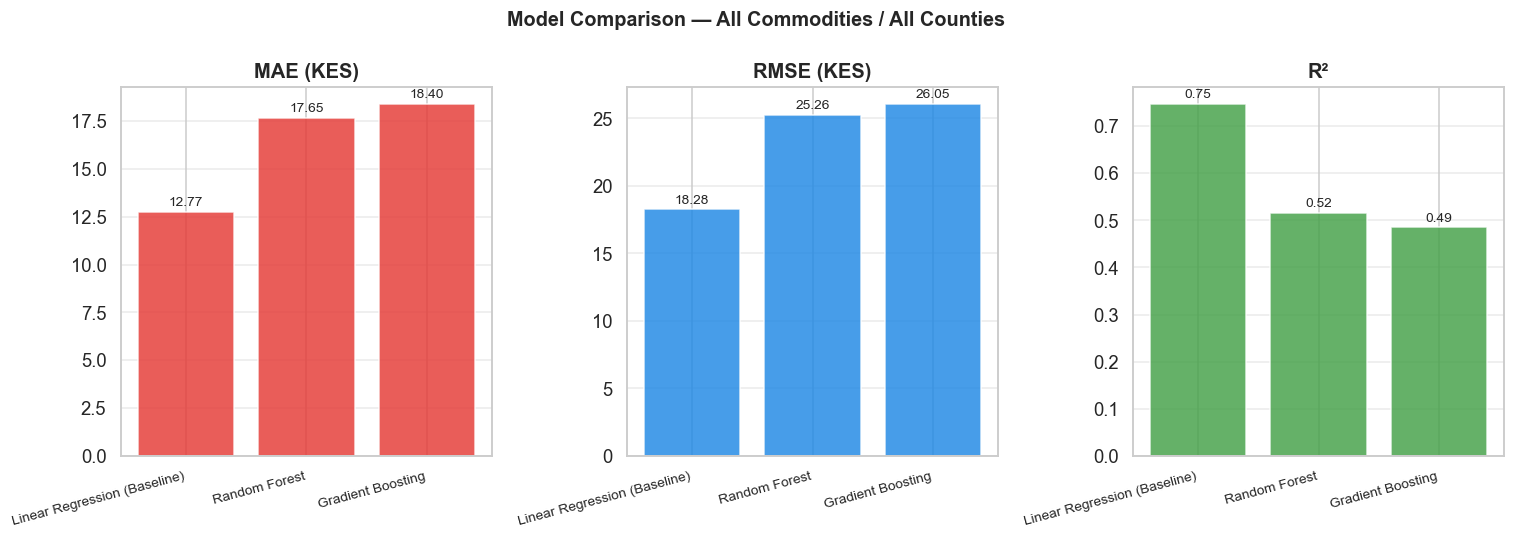

In [62]:
# Bar chart comparison 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE (KES)', 'RMSE (KES)', 'R²']
colors  = ['#E53935', '#1E88E5', '#43A047']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results['Model'], results[metric], color=color, alpha=0.82, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Model Comparison — All Commodities / All Counties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.2. Cross-Validation with TimeSeriesSplit (All Models)

1. **`TimeSeriesSplit` instead of `KFold`** — `KFold(shuffle=False)` preserves
   row order but still uses later folds to predict earlier ones in some splits
   (non-causal). `TimeSeriesSplit` guarantees that the test fold is always
   **strictly after** the training folds, matching real-world deployment.

2. **Pipelines passed to `cross_val_score`** —  Passing a `Pipeline`
   object ensures preprocessing is re-fitted from scratch inside every fold,
   so no information from the test fold leaks into the feature transforms.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TimeSeriesSplit CV — Linear Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Fold 1:  MAE=  11.34 KES  RMSE=  16.52 KES  R²=0.7570
  Fold 2:  MAE=  16.35 KES  RMSE=  17.71 KES  R²=0.6125
  Fold 3:  MAE=   5.20 KES  RMSE=   9.19 KES  R²=0.9150
  Fold 4:  MAE=  14.97 KES  RMSE=  17.89 KES  R²=0.8450
  Fold 5:  MAE=   9.90 KES  RMSE=  14.04 KES  R²=0.8058
  ──────────────────────────────────────────────────
  Mean :  MAE=  11.55 KES  RMSE=  15.07 KES  R²=0.7871
  Std  :  MAE=   3.95 KES  RMSE=   3.25 KES  R²=0.1015
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TimeSeriesSplit CV — Random Forest
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Fold 1:  MAE=   9.10 KES  RMSE=  15.24 KES  R²=0.7932
  Fold 2:  MAE=   6.60 KES  RMSE=   9.45 KES  R²=0.8897
  Fold 3:  MAE=   5.49 KES  RMSE=  10.35 KES  R²=0.8923
  Fold 4:  MAE=   6.44 KES  RMSE=  10.75 KES  R²=0.9441
  Fold 5:  MAE=   7.64 KES  RMS

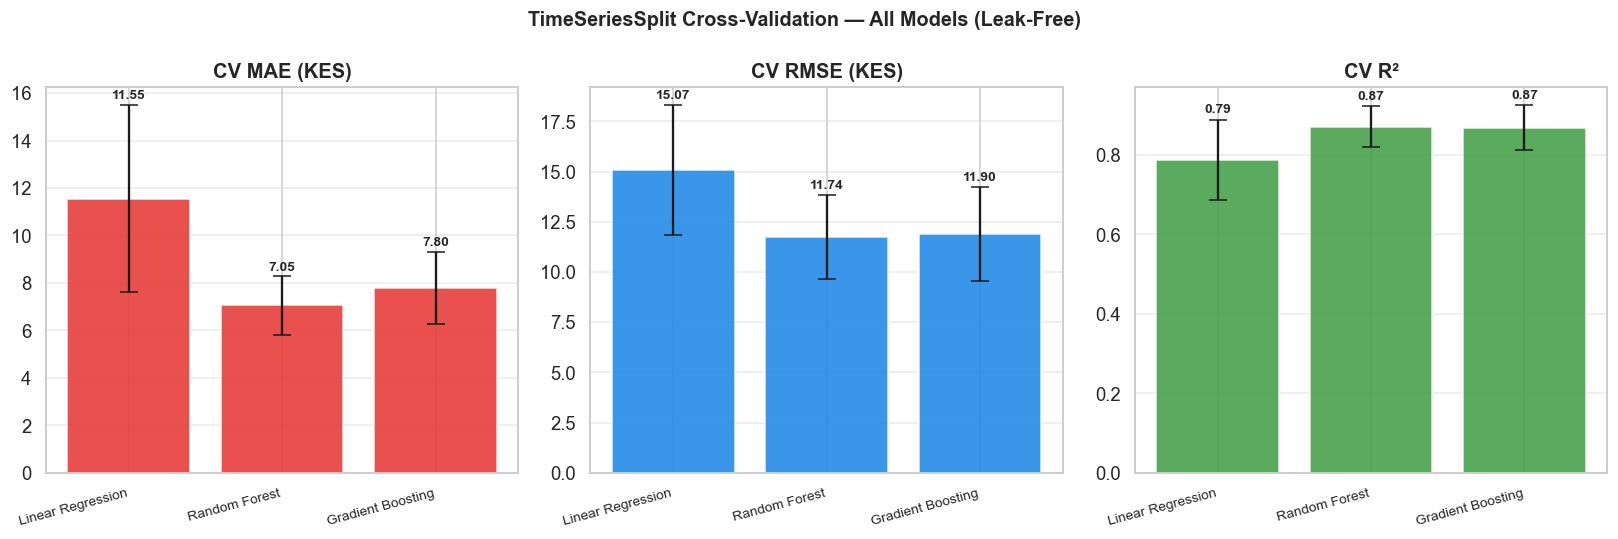

In [63]:
# Cross-Validation: TimeSeriesSplit + Pipelines 

tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}
for model_name, pipe in [
    ('Linear Regression', lr_pipe),
    ('Random Forest',     rf_pipe),
    ('Gradient Boosting', gbr_pipe),
]:
    cv_mae  = -cross_val_score(pipe, X_raw, y, cv=tscv,
                               scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(pipe, X_raw, y, cv=tscv,
                                       scoring='neg_mean_squared_error'))
    cv_r2   =  cross_val_score(pipe, X_raw, y, cv=tscv, scoring='r2')
    cv_results[model_name] = {'mae': cv_mae, 'rmse': cv_rmse, 'r2': cv_r2}

    print('━' * 55)
    print(f'  TimeSeriesSplit CV — {model_name}')
    print('━' * 55)
    for i, (m, r, r2v) in enumerate(zip(cv_mae, cv_rmse, cv_r2), 1):
        print(f'  Fold {i}:  MAE={m:7.2f} KES  RMSE={r:7.2f} KES  R²={r2v:.4f}')
    print('  ' + '─'*50)
    print(f'  Mean :  MAE={cv_mae.mean():7.2f} KES  RMSE={cv_rmse.mean():7.2f} KES  R²={cv_r2.mean():.4f}')
    print(f'  Std  :  MAE={cv_mae.std():7.2f} KES  RMSE={cv_rmse.std():7.2f} KES  R²={cv_r2.std():.4f}')

print('━' * 55)

# Visual comparison 
model_names_cv = list(cv_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_keys    = ['mae', 'rmse', 'r2']
metric_labels  = ['MAE (KES)', 'RMSE (KES)', 'R²']
cv_colors      = ['#E53935', '#1E88E5', '#43A047']

for ax, mkey, mlabel, col in zip(axes, metric_keys, metric_labels, cv_colors):
    means = [cv_results[m][mkey].mean() for m in model_names_cv]
    stds  = [cv_results[m][mkey].std()  for m in model_names_cv]
    bars  = ax.bar(model_names_cv, means, yerr=stds, color=col,
                   edgecolor='white', capsize=6, alpha=0.88)
    ax.set_title(f'CV {mlabel}', fontweight='bold')
    ax.set_xticklabels(model_names_cv, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for bar, v, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + s + (max(means) * 0.01),
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('TimeSeriesSplit Cross-Validation — All Models (Leak-Free)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Reading the CV Results

**Why TimeSeriesSplit gives more honest numbers than the original KFold:**

- Each fold trains only on past data and tests on future data — exactly how the
  model will be used in production.
- Preprocessing (OHE + imputation) is re-fitted inside every fold, so no
  statistics from the test window contaminate the feature transforms.

**Model selection:** choose the model with the lowest mean CV MAE (Random Forest).

## 7.3. Feature Importance — Random Forest (Best Model by CV)

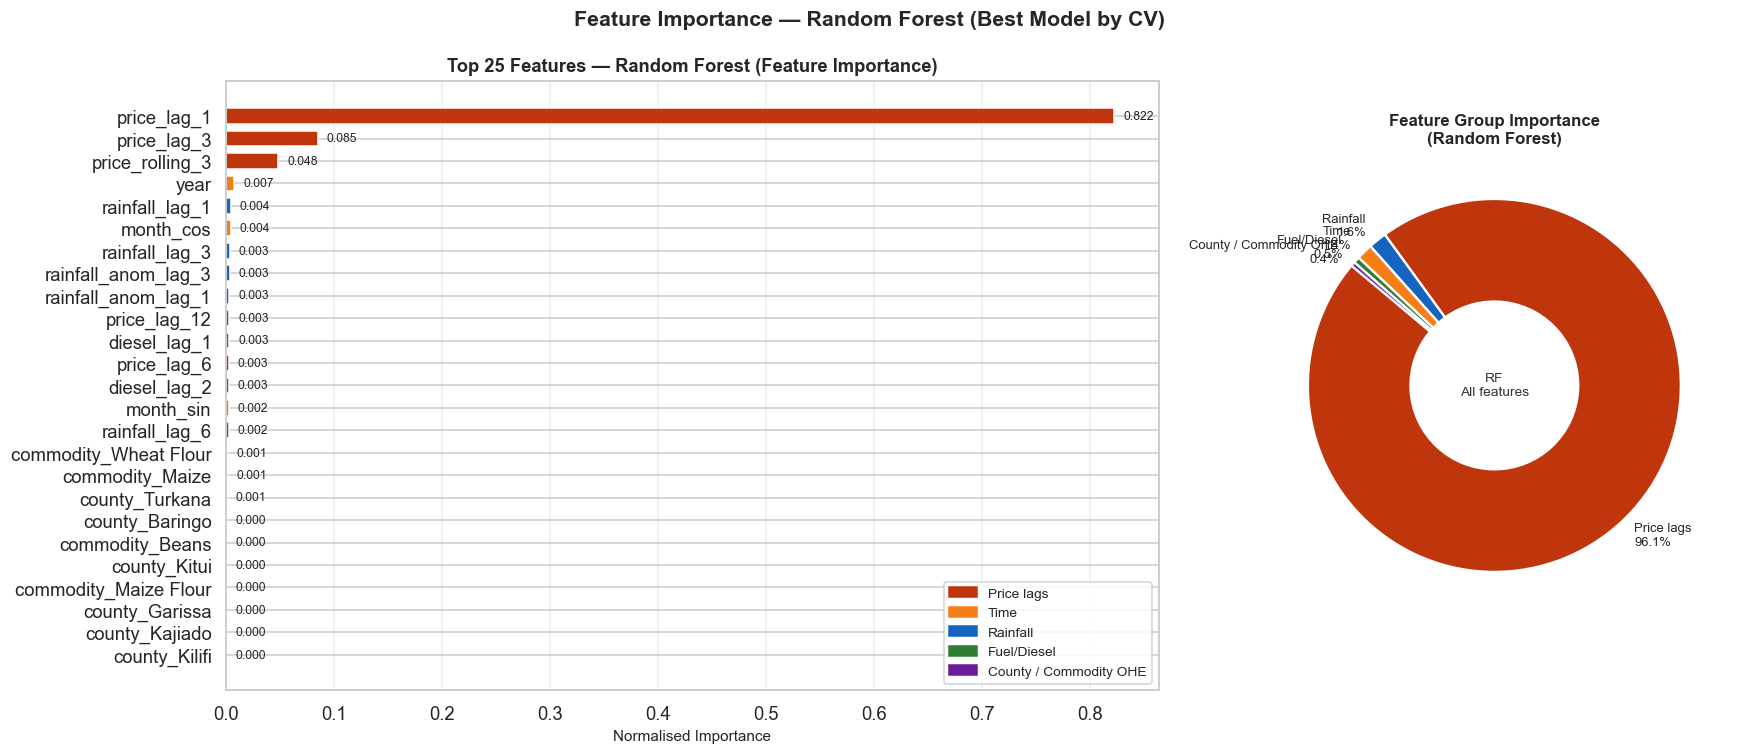


Top 15 Features — Random Forest:
  Feature                        Importance  Group
  ----------------------------------------------------------
  price_lag_1                        0.8222  Price lags
  price_lag_3                        0.0849  Price lags
  price_rolling_3                    0.0483  Price lags
  year                               0.0074  Time
  rainfall_lag_1                     0.0044  Rainfall
  month_cos                          0.0042  Time
  rainfall_lag_3                     0.0031  Rainfall
  rainfall_anom_lag_3                0.0030  Rainfall
  rainfall_anom_lag_1                0.0030  Rainfall
  price_lag_12                       0.0029  Price lags
  diesel_lag_1                       0.0028  Fuel/Diesel
  price_lag_6                        0.0026  Price lags
  diesel_lag_2                       0.0026  Fuel/Diesel
  month_sin                          0.0024  Time
  rainfall_lag_6                     0.0023  Rainfall


In [64]:
# Feature importance — Random Forest (best model by CV)
from matplotlib.patches import Patch

feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
feat_imp_norm = feat_imp / feat_imp.sum()
feat_imp_sorted = feat_imp_norm.sort_values(ascending=False)

top_n = 25
feat_top = feat_imp_sorted.head(top_n)

def get_color(f):
    if 'price'    in f: return '#BF360C'
    if 'rainfall' in f: return '#1565C0'
    if 'diesel'   in f: return '#2E7D32'
    if f in ('year','month_sin','month_cos'): return '#F57F17'
    return '#6A1B9A'

GROUP_LABELS = {
    '#BF360C': 'Price lags',
    '#1565C0': 'Rainfall',
    '#2E7D32': 'Fuel/Diesel',
    '#F57F17': 'Time',
    '#6A1B9A': 'County / Commodity OHE',
}

colors_fi = [get_color(f) for f in feat_top.index]

fig, (ax_bar, ax_donut) = plt.subplots(1, 2, figsize=(16, 7),
                                        gridspec_kw={'width_ratios': [2, 1]})

# Bar chart
bars = ax_bar.barh(feat_top.index[::-1], feat_top.values[::-1],
                   color=colors_fi[::-1], edgecolor='white', height=0.7)
ax_bar.set_title(f'Top {top_n} Features — Random Forest (Feature Importance)',
                 fontweight='bold', fontsize=12)
ax_bar.set_xlabel('Normalised Importance', fontsize=10)
ax_bar.grid(axis='x', alpha=0.35)
for bar, val in zip(bars, feat_top.values[::-1]):
    ax_bar.text(bar.get_width() + feat_top.max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

present = list(dict.fromkeys(colors_fi))
legend_handles = [Patch(color=c, label=GROUP_LABELS.get(c,'')) for c in present]
ax_bar.legend(handles=legend_handles, fontsize=9, loc='lower right', framealpha=0.85)

# Donut — group totals
grp_imp = {}
for feat, val in feat_imp_norm.items():
    c   = get_color(feat)
    lbl = GROUP_LABELS.get(c, 'Other')
    grp_imp[lbl] = grp_imp.get(lbl, 0) + val

grp_s = pd.Series(grp_imp).sort_values(ascending=False)
donut_colors = []
for lbl in grp_s.index:
    for c, l in GROUP_LABELS.items():
        if l == lbl:
            donut_colors.append(c)
            break
donut_labels = [f'{lbl}\n{v*100:.1f}%' for lbl, v in grp_s.items()]

ax_donut.pie(grp_s.values, labels=donut_labels,
             colors=donut_colors, startangle=140,
             wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
             textprops={'fontsize': 8.5})
ax_donut.set_title('Feature Group Importance\n(Random Forest)',
                   fontweight='bold', fontsize=11)
ax_donut.text(0, 0, 'RF\nAll features', ha='center', va='center',
              fontsize=9, color='#333333')

plt.suptitle('Feature Importance — Random Forest (Best Model by CV)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 15 Features — Random Forest:')
print(f'  {"Feature":<28} {"Importance":>12}  Group')
print('  ' + '-'*58)
for feat, val in feat_imp_sorted.head(15).items():
    grp = GROUP_LABELS.get(get_color(feat), 'Other')
    print(f'  {feat:<28} {val:>12.4f}  {grp}')

## 7.4. Predicted vs. Actual — Visual Check
Visual check on the best model by 5 fold cross validation

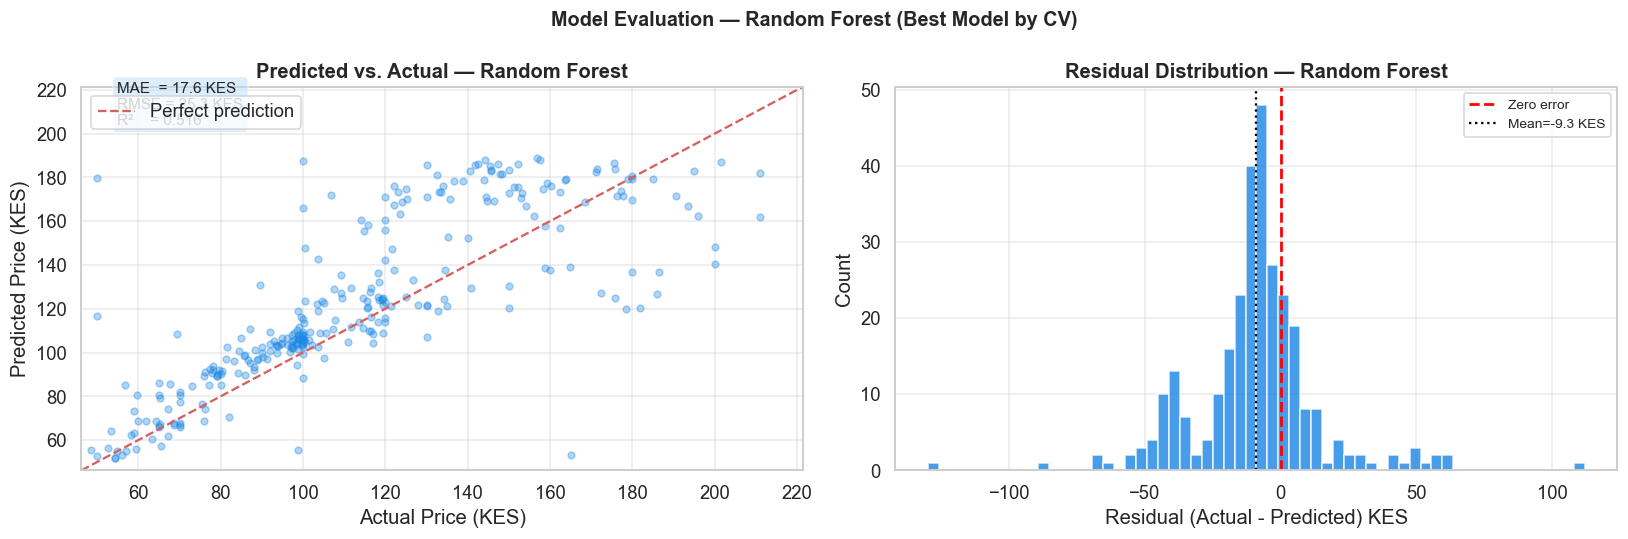

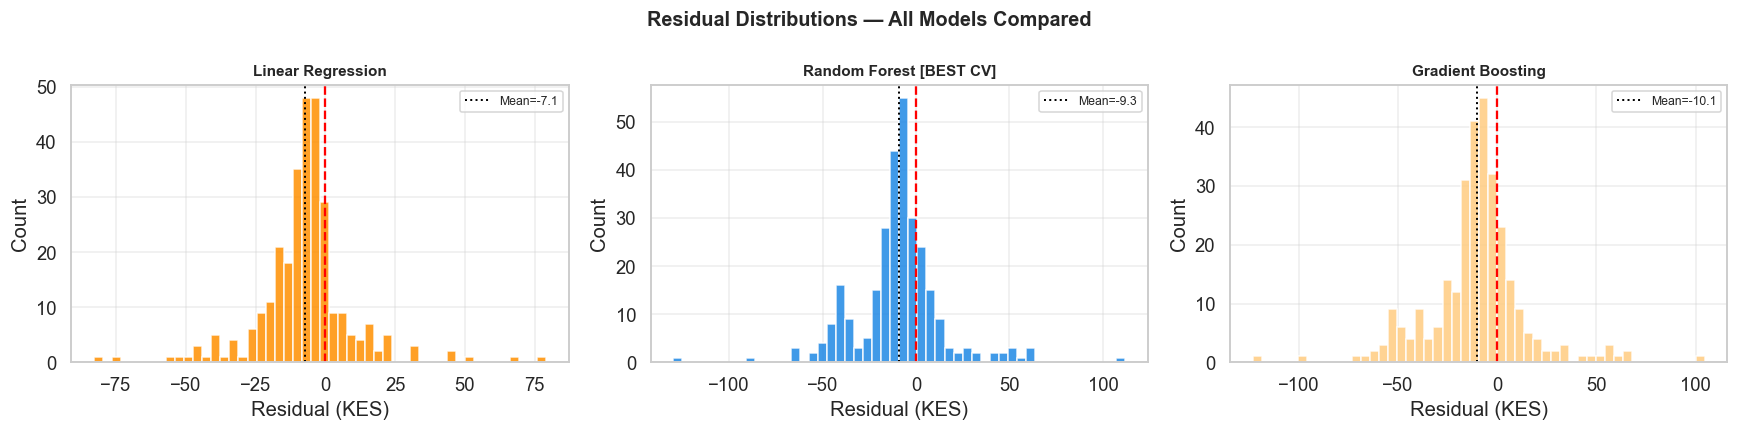

In [65]:
# Predicted vs Actual — Random Forest (best model by 5-Fold CV)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter — RF
axes[0].scatter(y_test, y_pred_rf, alpha=0.35, s=20, color='#1E88E5')
lims = [min(y_test.min(), y_pred_rf.min()) * 0.95,
        max(y_test.max(), y_pred_rf.max()) * 1.05]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual Price (KES)')
axes[0].set_ylabel('Predicted Price (KES)')
axes[0].set_title('Predicted vs. Actual — Random Forest', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.4)
axes[0].text(0.05, 0.90,
             f'MAE  = {mae_rf:.1f} KES\nRMSE = {rmse_rf:.1f} KES\nR²    = {r2_rf:.3f}',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='#BBDEFB', alpha=0.5))

# Residuals — RF
residuals_rf = y_test.values - y_pred_rf
axes[1].hist(residuals_rf, bins=60, color='#1E88E5', edgecolor='white', alpha=0.82)
axes[1].axvline(0, color='red', lw=1.8, ls='--', label='Zero error')
axes[1].axvline(residuals_rf.mean(), color='black', lw=1.5, ls=':',
                label=f'Mean={residuals_rf.mean():.1f} KES')
axes[1].set_xlabel('Residual (Actual - Predicted) KES')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution — Random Forest', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.4)

plt.suptitle('Model Evaluation — Random Forest (Best Model by CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Side-by-side residuals for all 3 models 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_preds = [('Linear Regression', y_pred_lr, '#FF8F00'),
               ('Random Forest',     y_pred_rf, '#1E88E5'),
               ('Gradient Boosting', y_pred_gbr,'#FFCC80')]

for ax, (name, preds, col) in zip(axes, model_preds):
    res = y_test.values - preds
    ax.hist(res, bins=50, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', lw=1.5, ls='--')
    ax.axvline(res.mean(), color='black', lw=1.3, ls=':',
               label=f'Mean={res.mean():.1f}')
    marker = ' [BEST CV]' if name == 'Random Forest' else ''
    ax.set_title(f'{name}{marker}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Residual (KES)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.35)

plt.suptitle('Residual Distributions — All Models Compared',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### RF remains best overall because:

Its residual distribution is the most concentrated around zero — the tall peak near 0 means most predictions are very accurate
CV MAE of 7.05 KES is still the lowest
R² of 0.87 is the highest

All models have negative mean residuals:

RF mean = -9.3 means the model consistently overestimates prices by ~9 KES on average
This systematic bias is visible in the scatter plot too — points fall below the perfect-fit line, meaning predicted values are higher than actual

What's causing the bias:

The scatter plot shows the model struggles most with high-price commodities (right side of the plot) — predictions plateau while actual prices keep rising. This is a common RF limitation called extrapolation bias — RF can't predict beyond the range of training data.

### Actual vs Predicted time-series for ALL key commodities 

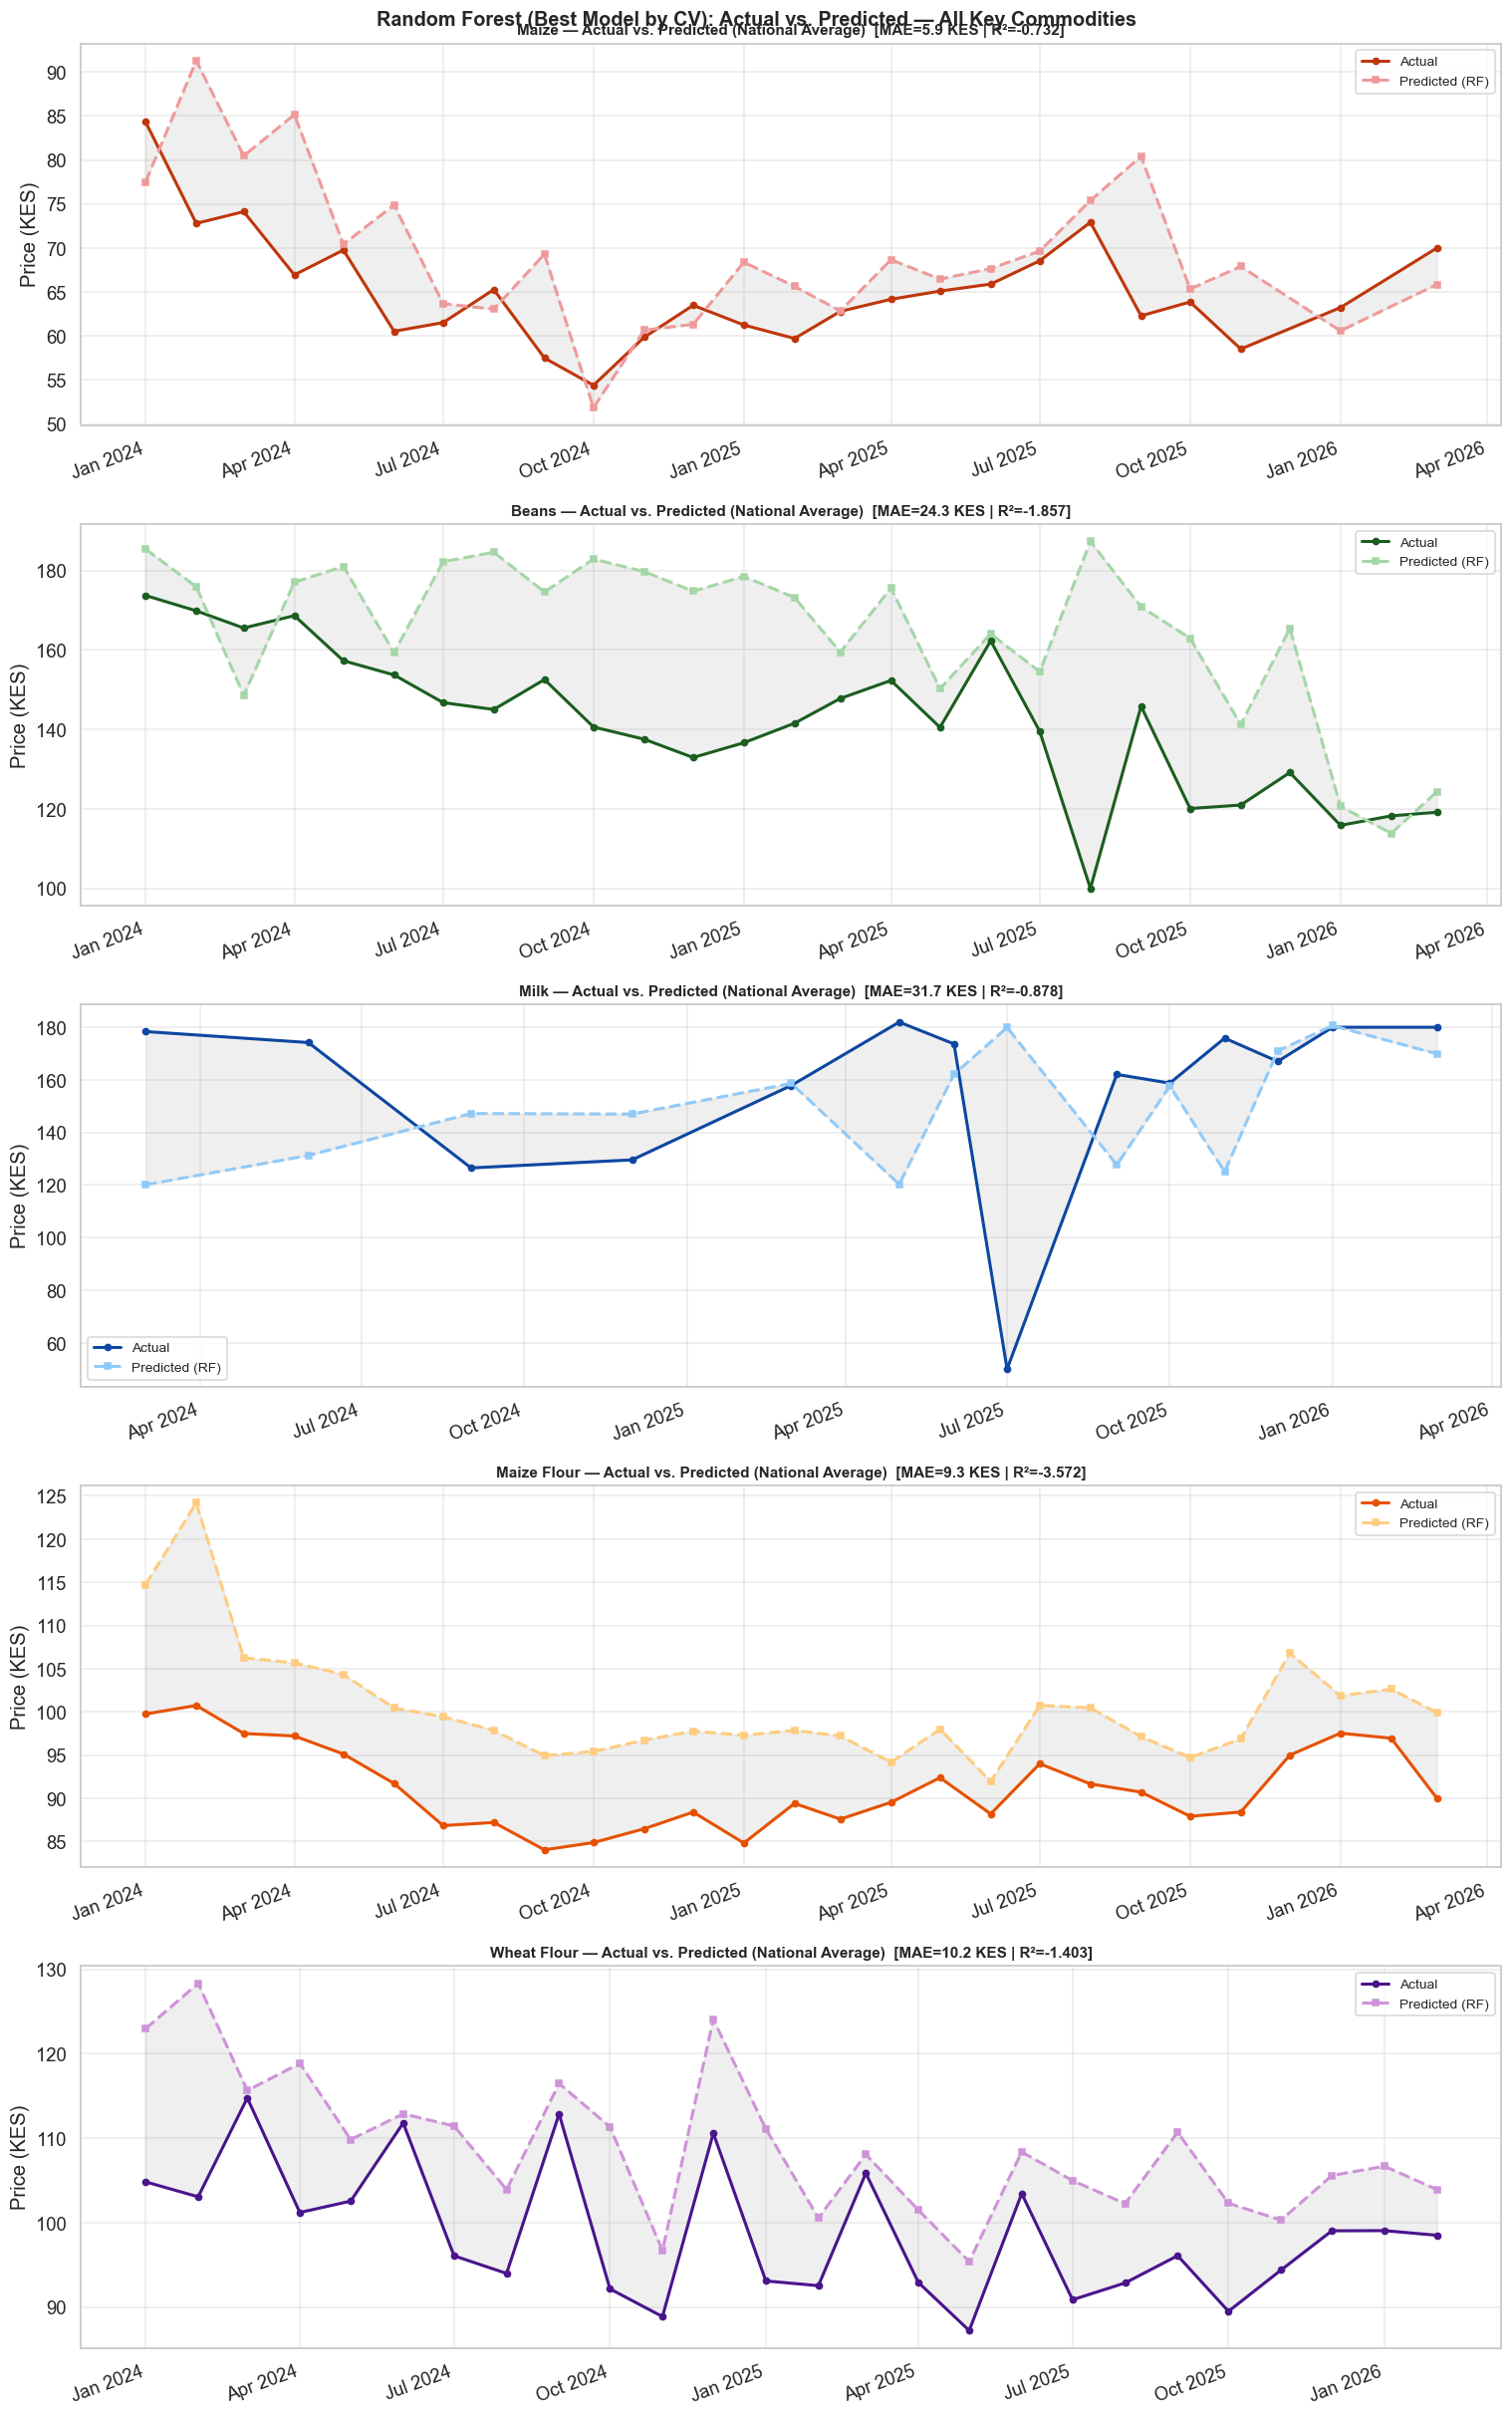

In [66]:
# Actual vs Predicted time-series for ALL key commodities 
test_df = df_model[test_mask].copy()
test_df['predicted'] = y_pred_rf   # Random Forest pipeline predictions          # ← Random Forest Regression (best model)

commodities_in_test = [c for c in KEY_COMM_LIST if c in test_df['commodity'].unique()]
n_c         = len(commodities_in_test)
colors_act  = ['#BF360C','#1B5E20','#0D47A1','#E65100','#4A148C']
colors_pred = ['#EF9A9A','#A5D6A7','#90CAF9','#FFCC80','#CE93D8']

fig, axes = plt.subplots(n_c, 1, figsize=(14, 4.5 * n_c), sharex=False)
if n_c == 1:
    axes = [axes]

for i, (ax, commodity) in enumerate(zip(axes, commodities_in_test)):
    sub = test_df[
        (test_df['commodity'] == commodity) &
        (test_df['county'] == 'Nairobi')
    ].sort_values('date_month')

    if sub.empty:
        sub = (test_df[test_df['commodity'] == commodity]
               .groupby('date_month')[['price','predicted']].mean()
               .reset_index())
        title_suffix = '(National Average)'
    else:
        title_suffix = '(Nairobi)'

    ax.plot(sub['date_month'], sub['price'],
            'o-', lw=2, ms=4, color=colors_act[i],  label='Actual')
    ax.plot(sub['date_month'], sub['predicted'],
            's--', lw=2, ms=4, color=colors_pred[i], label='Predicted (RF)')
    ax.fill_between(sub['date_month'], sub['price'], sub['predicted'],
                    alpha=0.12, color='grey')

    mae_c = mean_absolute_error(sub['price'], sub['predicted'])
    r2_c  = r2_score(sub['price'], sub['predicted']) if len(sub) > 2 else float('nan')
    ax.set_title(f'{commodity} — Actual vs. Predicted {title_suffix}  '
                 f'[MAE={mae_c:.1f} KES | R²={r2_c:.3f}]',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Price (KES)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Random Forest (Best Model by CV): Actual vs. Predicted — All Key Commodities',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.5. Commodity Error Breakdown
MAE broken down by commodity

Per-commodity performance breakdown on the best model

Per-Commodity Model Performance — Random Forest (Best Model by CV)
   commodity  MAE (KES)  RMSE (KES)    R²  N (test rows)  Mean Price (KES)  MAE % of Price
       Beans      26.81       31.57 -0.88          74.00            146.54           18.30
       Maize       7.94       11.06 -0.39          46.00             65.34           12.10
 Maize Flour       9.57       11.33 -0.71          49.00             91.03           10.50
        Milk      31.05       42.23 -0.60          43.00            150.41           20.60
 Wheat Flour      12.63       17.54 -0.91          82.00            102.94           12.30


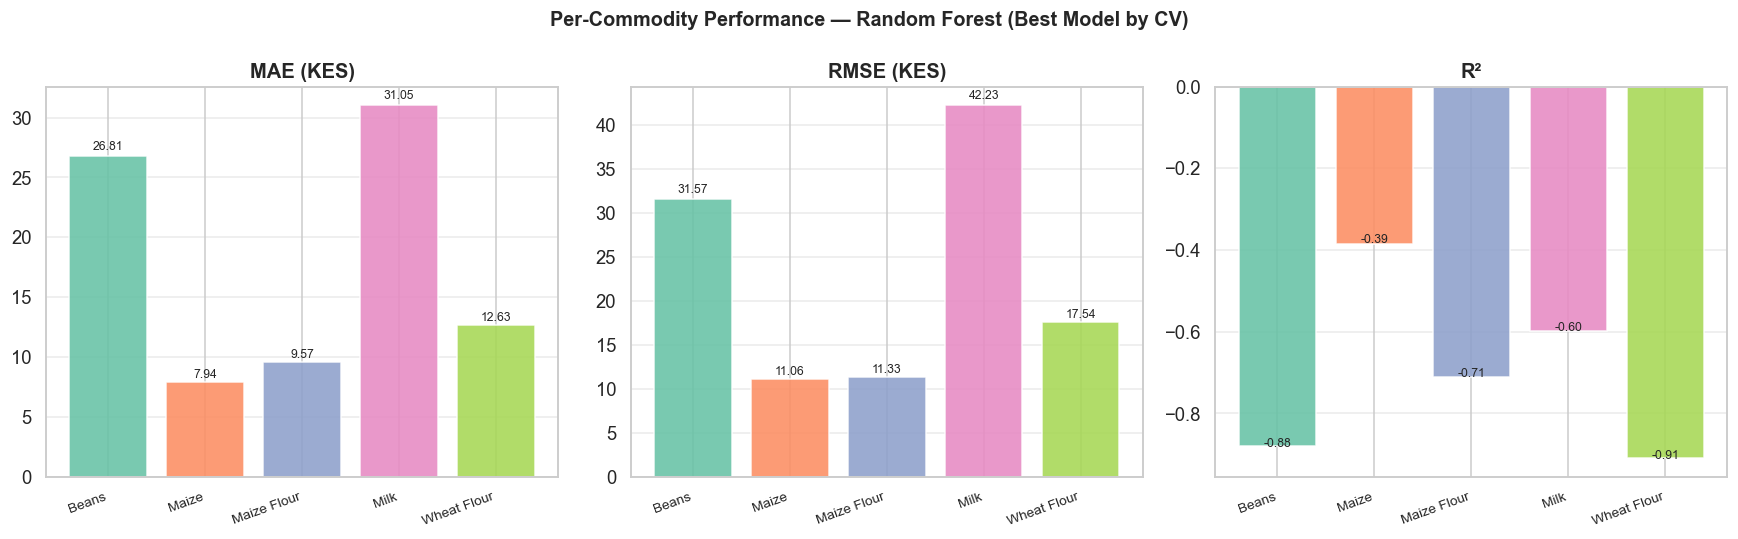

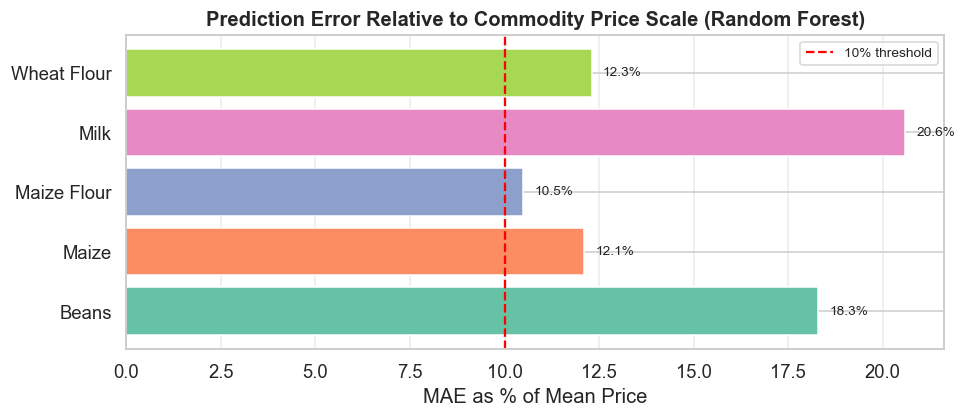

In [67]:
# Per-commodity performance breakdown — Random Forest (best model by CV)
test_df['abs_error'] = (test_df['price'] - test_df['predicted']).abs()

commodity_metrics = (
    test_df.groupby('commodity')
    .apply(lambda g: pd.Series({
        'MAE (KES)':        mean_absolute_error(g['price'], g['predicted']),
        'RMSE (KES)':       np.sqrt(mean_squared_error(g['price'], g['predicted'])),
        'R²':               r2_score(g['price'], g['predicted']) if len(g) > 2 else np.nan,
        'N (test rows)':    len(g),
        'Mean Price (KES)': g['price'].mean()
    }))
    .reset_index()
)
commodity_metrics['MAE % of Price'] = (
    commodity_metrics['MAE (KES)'] / commodity_metrics['Mean Price (KES)'] * 100
).round(1)

print('Per-Commodity Model Performance — Random Forest (Best Model by CV)')
print('=' * 80)
print(commodity_metrics.to_string(index=False, float_format='{:.2f}'.format))

cm_key = commodity_metrics[commodity_metrics['commodity'].isin(KEY_COMM_LIST)].copy()
bar_colors = sns.color_palette('Set2', len(cm_key))

# MAE / RMSE / R² bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = range(len(cm_key))
for ax, metric in zip(axes, ['MAE (KES)', 'RMSE (KES)', 'R²']):
    bars = ax.bar(x, cm_key[metric], color=bar_colors, edgecolor='white', alpha=0.88)
    ax.set_xticks(list(x))
    ax.set_xticklabels(cm_key['commodity'], rotation=20, ha='right', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, cm_key[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Per-Commodity Performance — Random Forest (Best Model by CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# MAE % of price
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(cm_key['commodity'], cm_key['MAE % of Price'],
               color=bar_colors, edgecolor='white')
ax.axvline(10, color='red', ls='--', lw=1.5, label='10% threshold')
ax.set_xlabel('MAE as % of Mean Price')
ax.set_title('Prediction Error Relative to Commodity Price Scale (Random Forest)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, cm_key['MAE % of Price']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()


# 8. In-Depth Per-Commodity Modelling

For each key commodity (**Maize, Beans, Milk, Maize Flour, Wheat Flour**) we:

> **Note:** Random Forest is the overall best model by time series CV (MAE=7.05 KES). Per-commodity best model is selected by lowest CV MAE for that commodity.
1. Prepare a commodity-specific feature matrix  
2. Train Linear Regression, Random Forest & Gradient Boosting  
3. Evaluate with MAE / RMSE / R²  
4. Run time series Cross-Validation on the best model  
5. Plot Feature Importance  
6. Plot Actual vs. Predicted time-series  
7. Produce a final consolidated leaderboard across all commodities   


## 8.1. Shared Modelling Helper
Train & evaluate three models for one commodity 

In [68]:
# Shared helper: train & evaluate three models for one commodity 
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.compose import ColumnTransformer

NUMERIC_COLS_H    = [
    'year', 'month_sin', 'month_cos',
    'rainfall_lag_1', 'rainfall_lag_3', 'rainfall_lag_6',
    'rainfall_anom_lag_1', 'rainfall_anom_lag_3',
    'diesel_lag_1', 'diesel_lag_2',
    'price_lag_1', 'price_lag_3', 'price_lag_6', 'price_lag_12',
    'price_rolling_3',
]
CATEGORICAL_COLS_H = ['county']   # commodity is fixed per call — no need to encode

def make_preprocessor_h():
    """Return a fresh (unfitted) ColumnTransformer for commodity-level models."""
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]),
             NUMERIC_COLS_H),
            ('cat', Pipeline([('ohe', OneHotEncoder(sparse_output=False,
                                                    handle_unknown='ignore'))]),
             CATEGORICAL_COLS_H),
        ],
        remainder='drop'
    )

def model_commodity(commodity_name, df_full, split_date=pd.Timestamp('2024-01-01')):
    """
    Trains LR, RF, GBR on data for a single commodity using leak-free Pipelines.
    Best model is selected by 5-fold TimeSeriesSplit CV MAE.
    Returns a results dict.
    """
    TARGET = 'price'
    df_c   = df_full[df_full['commodity'] == commodity_name].copy()
    df_c   = df_c.dropna(subset=[TARGET, 'price_lag_1', 'price_lag_3', 'diesel_lag_1'])

    if len(df_c) < 50:
        print(f'  ⚠  {commodity_name}: only {len(df_c)} rows — skipping.')
        return None

    X_c_raw = df_c[NUMERIC_COLS_H + CATEGORICAL_COLS_H].copy()
    y_c     = df_c[TARGET]

    tr_mask = df_c['date_month'] < split_date
    te_mask = df_c['date_month'] >= split_date

    if tr_mask.sum() < 30 or te_mask.sum() < 5:
        print(f'  ⚠  {commodity_name}: insufficient train/test rows — skipping.')
        return None

    X_tr_raw, X_te_raw = X_c_raw[tr_mask], X_c_raw[te_mask]
    y_tr, y_te         = y_c[tr_mask],      y_c[te_mask]

    # Build three Pipelines (each has its own fresh preprocessor) 
    pipes = {
        'LR':  Pipeline([('prep', make_preprocessor_h()),
                         ('model', LinearRegression())]),
        'RF':  Pipeline([('prep', make_preprocessor_h()),
                         ('model', RandomForestRegressor(
                             n_estimators=200, max_depth=15,
                             min_samples_leaf=3, n_jobs=-1, random_state=42))]),
        'GBR': Pipeline([('prep', make_preprocessor_h()),
                         ('model', GradientBoostingRegressor(
                             n_estimators=300, learning_rate=0.08, max_depth=5,
                             min_samples_leaf=4, subsample=0.85, random_state=42))]),
    }

    # Fit on train, predict on test 
    preds   = {}
    metrics = {}
    for key, pipe in pipes.items():
        pipe.fit(X_tr_raw, y_tr)
        y_pred = pipe.predict(X_te_raw)
        preds[key] = y_pred
        metrics[key] = {
            'MAE':  mean_absolute_error(y_te, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
            'R2':   r2_score(y_te, y_pred),
        }

    # Select best model by CV MAE 
    tscv_h   = TimeSeriesSplit(n_splits=5)
    cv_maes  = {}
    for key, pipe in pipes.items():
        # Re-fit from scratch on full commodity data for CV
        fresh_pipe = Pipeline(pipe.steps)   # clone avoids re-using fitted state
        cv_scores  = -cross_val_score(fresh_pipe, X_c_raw, y_c,
                                      cv=tscv_h, scoring='neg_mean_absolute_error')
        cv_maes[key] = cv_scores.mean()

    best_key = min(cv_maes, key=lambda k: cv_maes[k])

    # Feature names after OHE (for importance plots) 
    fitted_prep  = pipes[best_key].named_steps['prep']
    ohe_names    = (fitted_prep.named_transformers_['cat']
                               .named_steps['ohe']
                               .get_feature_names_out(CATEGORICAL_COLS_H).tolist())
    feat_names   = NUMERIC_COLS_H + ohe_names

    # Pre-transformed test arrays (for scatter / residual plots)
    X_te_t = fitted_prep.transform(X_te_raw)

    return {
        'commodity':  commodity_name,
        'df_c':       df_c,
        'te_mask':    te_mask,
        'feat_names': feat_names,
        'X_raw':      X_c_raw,
        'y':          y_c,
        'X_te_t':     X_te_t,
        'y_te':       y_te,
        'pipes':      pipes,
        'preds':      preds,
        'metrics':    metrics,
        'cv_maes':    cv_maes,
        'best_model': best_key,   # chosen by CV MAE, not hold-out MAE
    }

print('Helper function defined ✓  (leak-free Pipeline + TimeSeriesSplit CV)')

Helper function defined ✓  (leak-free Pipeline + TimeSeriesSplit CV)


## 8.2. Train Models for Every Key Commodity

In [69]:
# Train all three models for each key commodity
comm_results = {}

for commodity in KEY_COMM_LIST:
    print(f'\n━━━  {commodity}  ━━━')
    res = model_commodity(commodity, df)
    if res is not None:
        comm_results[commodity] = res
        m = res['metrics']
        best = res['best_model']
        for model_name, met in m.items():
            marker = ' <- BEST' if model_name == best else ''
            print(f'  {model_name:<4}  MAE={met["MAE"]:7.2f}  RMSE={met["RMSE"]:7.2f}  R²={met["R2"]:.4f}{marker}')

print(f'\nModelled {len(comm_results)} commodities: {list(comm_results.keys())}')



━━━  Maize  ━━━
  LR    MAE=   5.78  RMSE=   8.16  R²=0.2462
  RF    MAE=   5.98  RMSE=   7.79  R²=0.3121 <- BEST
  GBR   MAE=   5.92  RMSE=   7.42  R²=0.3767

━━━  Beans  ━━━
  LR    MAE=  21.39  RMSE=  26.40  R²=-0.3156 <- BEST
  RF    MAE=  28.34  RMSE=  32.38  R²=-0.9794
  GBR   MAE=  27.40  RMSE=  32.14  R²=-0.9496

━━━  Milk  ━━━
  LR    MAE=  37.67  RMSE=  48.48  R²=-1.1066
  RF    MAE=  64.86  RMSE=  71.63  R²=-3.5995
  GBR   MAE=  40.28  RMSE=  49.58  R²=-1.2039 <- BEST

━━━  Maize Flour  ━━━
  LR    MAE=  38.71  RMSE=  41.32  R²=-21.7339
  RF    MAE=  16.79  RMSE=  18.31  R²=-3.4621 <- BEST
  GBR   MAE=  20.94  RMSE=  22.47  R²=-5.7236

━━━  Wheat Flour  ━━━
  LR    MAE=  34.98  RMSE=  40.18  R²=-9.0143
  RF    MAE=  13.09  RMSE=  15.86  R²=-0.5608 <- BEST
  GBR   MAE=  13.46  RMSE=  16.57  R²=-0.7030

Modelled 5 commodities: ['Maize', 'Beans', 'Milk', 'Maize Flour', 'Wheat Flour']


## 8.3. Per-Commodity Model Comparison Table
Consolidated metrics table — highlight best model per commodity

In [70]:
# Consolidated metrics table — highlight best model per commodity
rows = []
for comm, res in comm_results.items():
    best = res['best_model']
    for model_name, met in res['metrics'].items():
        rows.append({
            'Commodity': comm,
            'Model':     model_name,
            'MAE (KES)': round(met['MAE'], 2),
            'RMSE (KES)':round(met['RMSE'], 2),
            'R²':        round(met['R2'], 4),
            'Best':      'YES' if model_name == best else ''
        })

metrics_df = pd.DataFrame(rows)
print('=' * 70)
print(metrics_df.to_string(index=False))
print('=' * 70)

print('\nBest model per commodity (lowest MAE):')
best_df = metrics_df[metrics_df['Best'] == 'YES'][['Commodity','Model','MAE (KES)','R²']]
print(best_df.to_string(index=False))


   Commodity Model  MAE (KES)  RMSE (KES)       R² Best
       Maize    LR       5.78        8.16   0.2462     
       Maize    RF       5.98        7.79   0.3121  YES
       Maize   GBR       5.92        7.42   0.3767     
       Beans    LR      21.39       26.40  -0.3156  YES
       Beans    RF      28.34       32.38  -0.9794     
       Beans   GBR      27.40       32.14  -0.9496     
        Milk    LR      37.67       48.48  -1.1066     
        Milk    RF      64.86       71.63  -3.5995     
        Milk   GBR      40.28       49.58  -1.2039  YES
 Maize Flour    LR      38.71       41.32 -21.7339     
 Maize Flour    RF      16.79       18.31  -3.4621  YES
 Maize Flour   GBR      20.94       22.47  -5.7236     
 Wheat Flour    LR      34.98       40.18  -9.0143     
 Wheat Flour    RF      13.09       15.86  -0.5608  YES
 Wheat Flour   GBR      13.46       16.57  -0.7030     

Best model per commodity (lowest MAE):
   Commodity Model  MAE (KES)      R²
       Maize    RF       5

## 8.4. Visual Model Comparison — MAE & R² per Commodity

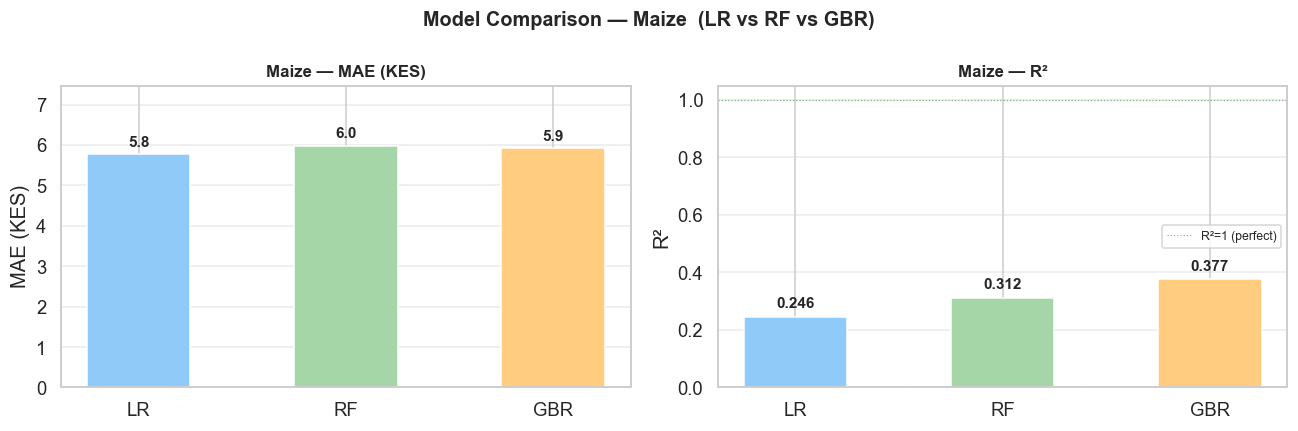

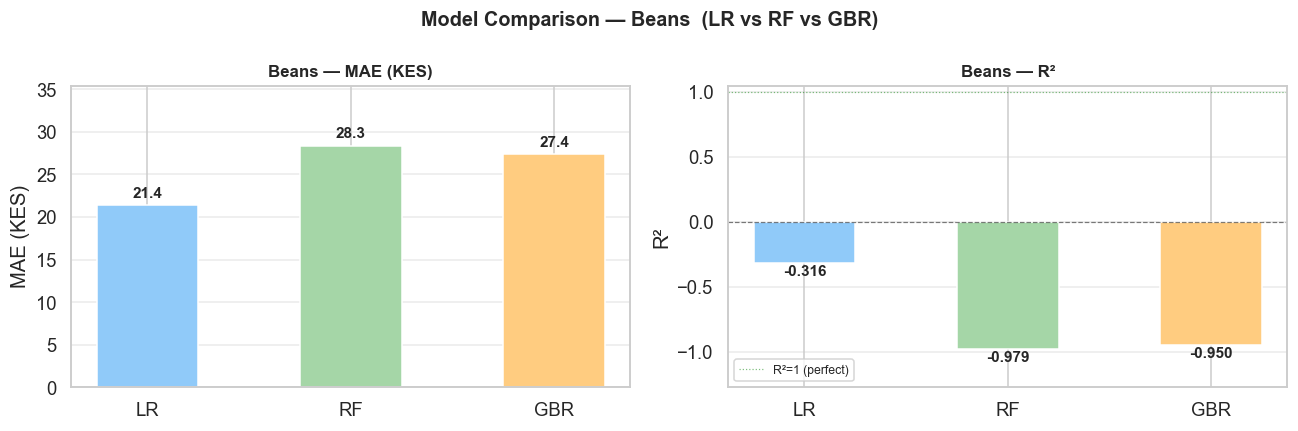

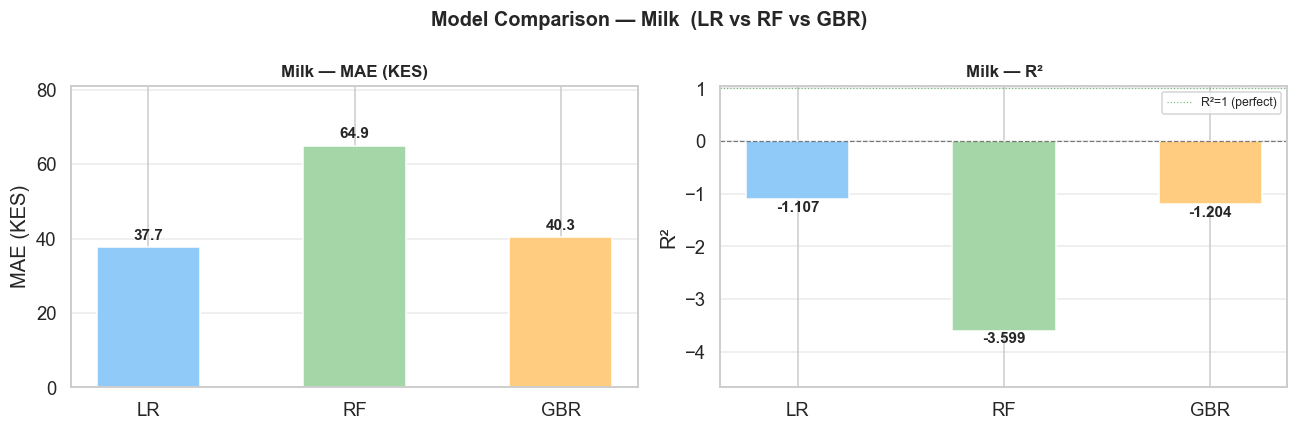

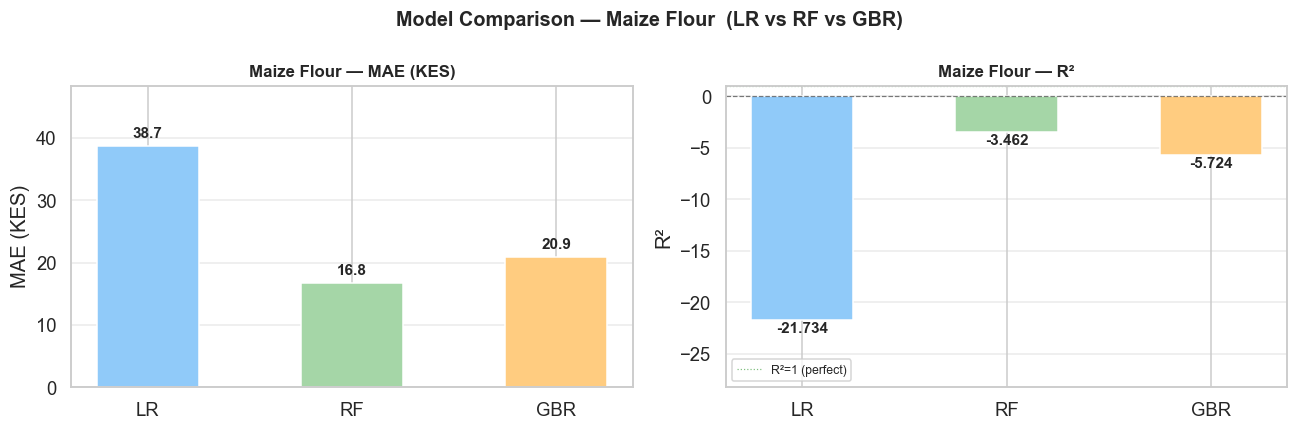

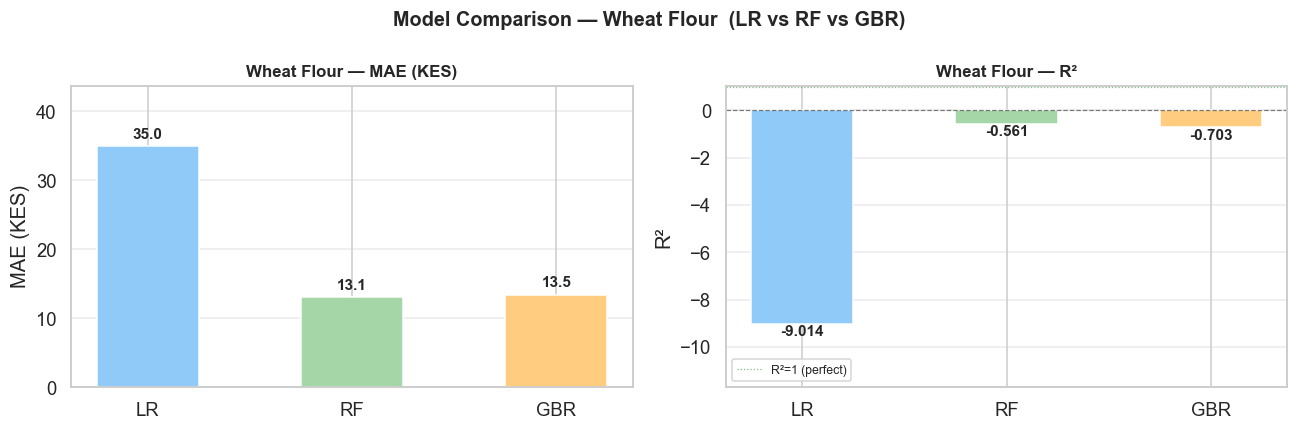

In [71]:
# Grid of bar charts: MAE and R² for LR / RF / GBR per commodity
commodities_done = list(comm_results.keys())
n_c  = len(commodities_done)

model_colors = {'LR': '#90CAF9', 'RF': '#A5D6A7', 'GBR': '#FFCC80'}

# One figure per commodity (avoids axes reshape bugs & diagonal artifact) 
for i, comm in enumerate(commodities_done):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    res  = comm_results[comm]
    mets = res['metrics']
    models_list = list(mets.keys())
    maes  = [mets[m]['MAE']  for m in models_list]
    r2s   = [mets[m]['R2']   for m in models_list]
    cols  = [model_colors[m] for m in models_list]

    # MAE panel 
    bars = axes[0].bar(models_list, maes, color=cols, edgecolor='white', width=0.5)
    axes[0].set_title(f'{comm} — MAE (KES)', fontweight='bold', fontsize=11)
    axes[0].set_ylabel('MAE (KES)')
    axes[0].set_ylim(0, max(maes) * 1.25)
    axes[0].grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, maes):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(maes)*0.02,
                     f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # R² panel — handle negative values gracefully 
    r2_floor = min(0, min(r2s)) * 1.3   # extend below 0 if negative
    r2_ceil  = max(1.05, max(r2s) * 1.25)

    bars2 = axes[1].bar(models_list, r2s, color=cols, edgecolor='white', width=0.5)
    axes[1].set_title(f'{comm} — R²', fontweight='bold', fontsize=11)
    axes[1].set_ylabel('R²')
    axes[1].set_ylim(r2_floor, r2_ceil)
    axes[1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)   # zero line
    axes[1].axhline(1, color='green', lw=0.8, ls=':', alpha=0.5, label='R²=1 (perfect)')
    axes[1].grid(axis='y', alpha=0.4)
    axes[1].legend(fontsize=8)

    for bar, v in zip(bars2, r2s):
        label_y = bar.get_height() + (r2_ceil - r2_floor) * 0.02 if v >= 0                   else bar.get_height() - (r2_ceil - r2_floor) * 0.05
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     label_y,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.suptitle(f'Model Comparison — {comm}  (LR vs RF vs GBR)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8.5. TimeSeriesSplit CV — per Commodity 
timeseries split CV using each commodity's best model (lowest MAE)

TimeSeriesSplit Cross-Validation — Best Model per Commodity

  Maize  [Best Model by CV MAE: RF]
    Fold 1: MAE=   6.09  RMSE=   9.16  R²=0.5143
    Fold 2: MAE=   4.81  RMSE=   6.47  R²=0.8571
    Fold 3: MAE=   3.79  RMSE=   4.73  R²=0.8842
    Fold 4: MAE=   3.10  RMSE=   4.33  R²=0.8747
    Fold 5: MAE=   5.06  RMSE=   7.20  R²=0.7108
    Mean : MAE=   4.57 ± 1.04  RMSE=   6.38  R²=0.7682

  Beans  [Best Model by CV MAE: LR]
    Fold 1: MAE=  15.78  RMSE=  20.16  R²=0.4681
    Fold 2: MAE=  11.86  RMSE=  14.97  R²=0.4977
    Fold 3: MAE=   5.51  RMSE=   6.95  R²=-0.1716
    Fold 4: MAE=  11.53  RMSE=  16.94  R²=0.7518
    Fold 5: MAE=  13.48  RMSE=  17.55  R²=0.6679
    Mean : MAE=  11.63 ± 3.41  RMSE=  15.32  R²=0.4428

  Milk  [Best Model by CV MAE: GBR]
    Fold 1: MAE=  72.09  RMSE=  76.29  R²=-128.2549
    Fold 2: MAE=   4.53  RMSE=   5.91  R²=-1.6284
    Fold 3: MAE=   4.24  RMSE=   5.31  R²=-4.4651
    Fold 4: MAE=   3.22  RMSE=   4.22  R²=-3.3945
    Fold 5: MAE=  26.86  R

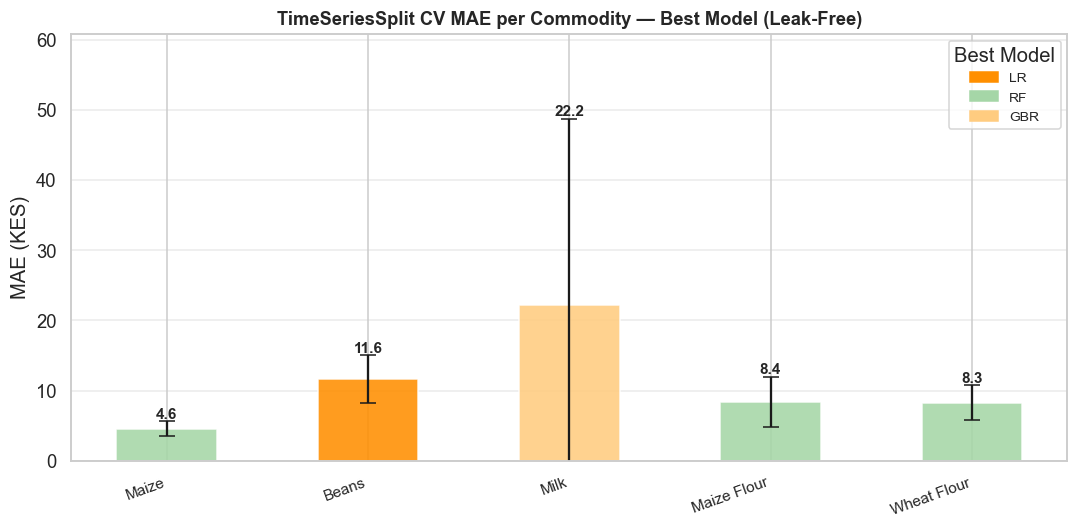

In [72]:
# CV already runs inside model_commodity() to pick the best model.
tscv_display = TimeSeriesSplit(n_splits=5)

cv_summary = []
print('TimeSeriesSplit Cross-Validation — Best Model per Commodity')
print('=' * 65)

for comm in commodities_done:
    res      = comm_results[comm]
    best_key = res['best_model']
    best_pipe = res['pipes'][best_key]
    X_c_raw  = res['X_raw']
    y_c      = res['y']

    cv_mae  = -cross_val_score(best_pipe, X_c_raw, y_c, cv=tscv_display,
                               scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(best_pipe, X_c_raw, y_c, cv=tscv_display,
                                       scoring='neg_mean_squared_error'))
    cv_r2   =  cross_val_score(best_pipe, X_c_raw, y_c, cv=tscv_display,
                               scoring='r2')

    print(f'\n  {comm}  [Best Model by CV MAE: {best_key}]')
    for fold_i, (m, r, r2v) in enumerate(zip(cv_mae, cv_rmse, cv_r2), 1):
        print(f'    Fold {fold_i}: MAE={m:7.2f}  RMSE={r:7.2f}  R²={r2v:.4f}')
    print(f'    Mean : MAE={cv_mae.mean():7.2f} ± {cv_mae.std():.2f}  '
          f'RMSE={cv_rmse.mean():7.2f}  R²={cv_r2.mean():.4f}')

    cv_summary.append({
        'Commodity':    comm,
        'Best Model':   best_key,
        'CV MAE Mean':  round(cv_mae.mean(), 2),
        'CV MAE Std':   round(cv_mae.std(),  2),
        'CV RMSE Mean': round(cv_rmse.mean(), 2),
        'CV R² Mean':   round(cv_r2.mean(), 4),
    })

print('\n' + '=' * 65)
cv_df = pd.DataFrame(cv_summary)
print(cv_df.to_string(index=False))

# Visualise 
model_palette = {'LR': '#FF8F00', 'RF': '#A5D6A7', 'GBR': '#FFCC80'}
bar_cols = [model_palette.get(r, '#90CAF9') for r in cv_df['Best Model']]
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=m) for m, c in model_palette.items()]

fig1, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(cv_df['Commodity'], cv_df['CV MAE Mean'],
               yerr=cv_df['CV MAE Std'], color=bar_cols,
               edgecolor='white', capsize=5, alpha=0.88, width=0.5)
ax1.set_title('TimeSeriesSplit CV MAE per Commodity — Best Model (Leak-Free)',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('MAE (KES)')
ax1.set_ylim(0, (cv_df['CV MAE Mean'] + cv_df['CV MAE Std']).max() * 1.25)
ax1.set_xticklabels(cv_df['Commodity'], rotation=20, ha='right', fontsize=10)
ax1.grid(axis='y', alpha=0.4)
for bar, v, s in zip(bars, cv_df['CV MAE Mean'], cv_df['CV MAE Std']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + s + cv_df['CV MAE Mean'].max() * 0.02,
             f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
ax1.legend(handles=legend_handles, title='Best Model', fontsize=9)
plt.tight_layout()
plt.show()


## 8.6. Feature Importance
Feature Importance — LR (coefficients), RF & GBR per commodity 

For each commodity: one figure with 3 panels (one per model)

LR uses absolute coefficients; RF & GBR use built-in feature_importances_


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Maize
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  county_Mandera                 0.1546  County (location)
  county_Kitui                   0.1405  County (location)
  county_Turkana                 0.1255  County (location)
  county_Garissa                 0.1030  County (location)
  county_Nairobi                 0.0840  County (location)
  county_Wajir                   0.0771  County (location)
  month_cos                      0.0516  Time (year / month)
  county_Kilifi                  0.0485  County (location)
  price_lag_1                    0.0430  Price lags (autoregressive)
  county_Marsabit                0.0373  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -----------------------------------------------------

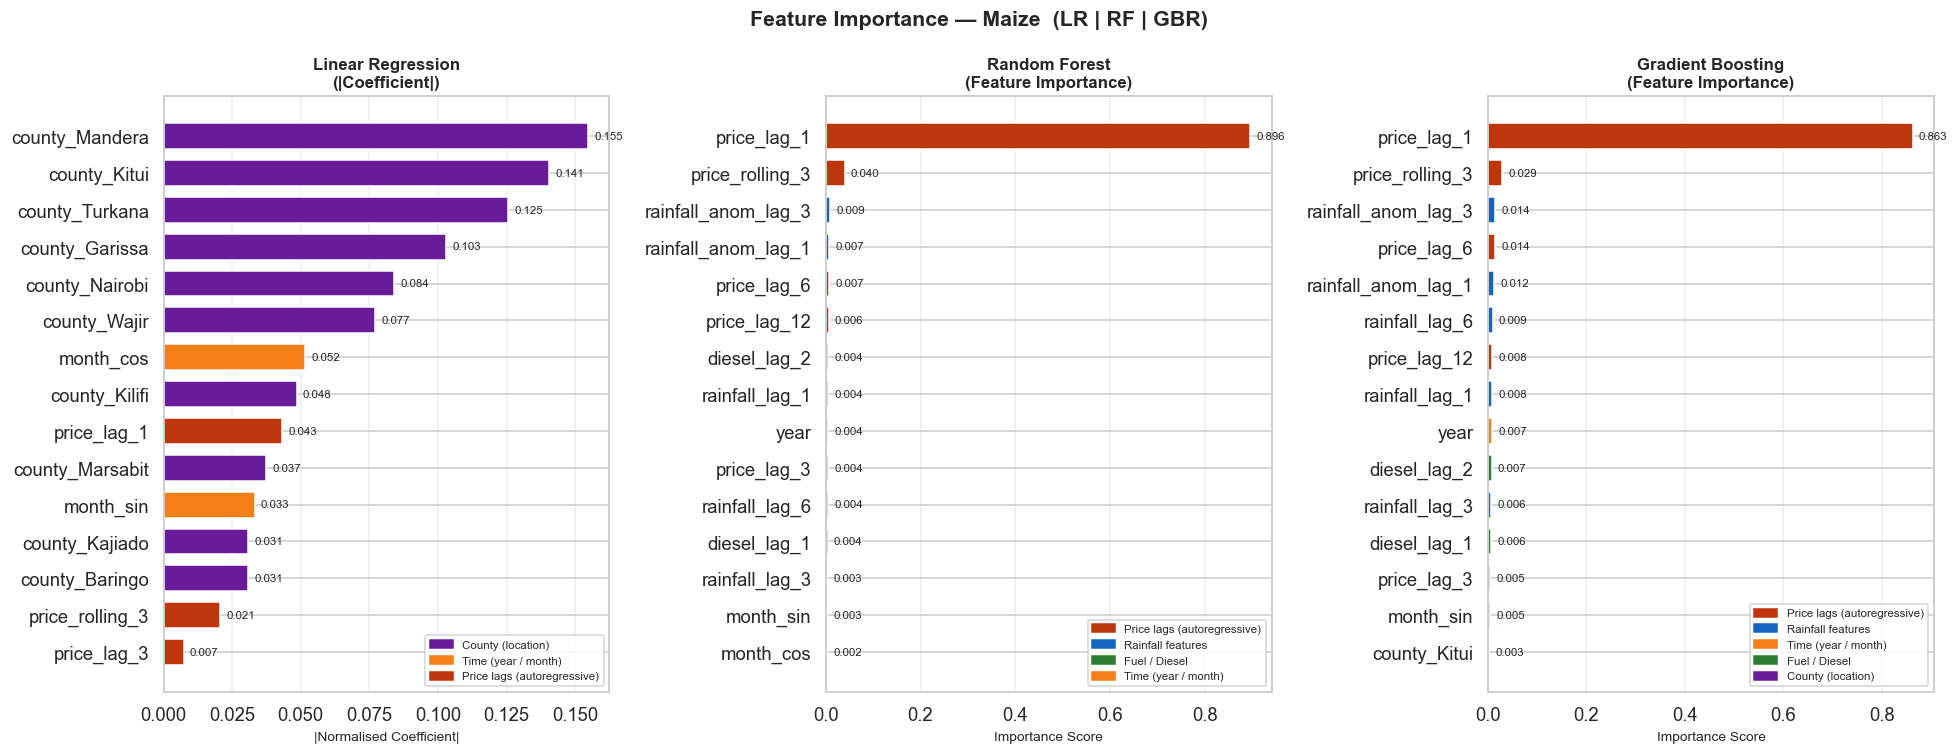

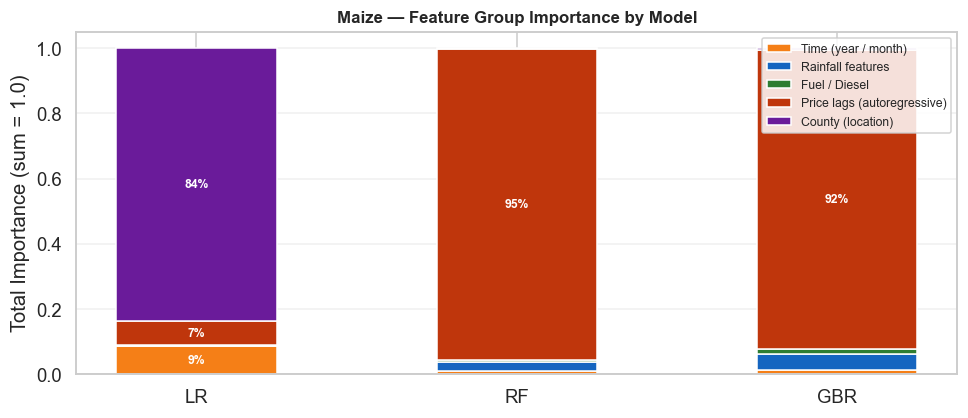


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Beans
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  county_Isiolo                  0.4424  County (location)
  county_Marsabit                0.1285  County (location)
  county_Kitui                   0.1094  County (location)
  county_Garissa                 0.0646  County (location)
  county_Nairobi                 0.0619  County (location)
  county_Turkana                 0.0421  County (location)
  county_Mombasa                 0.0280  County (location)
  county_Baringo                 0.0251  County (location)
  month_cos                      0.0234  Time (year / month)
  county_Kajiado                 0.0190  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  year 

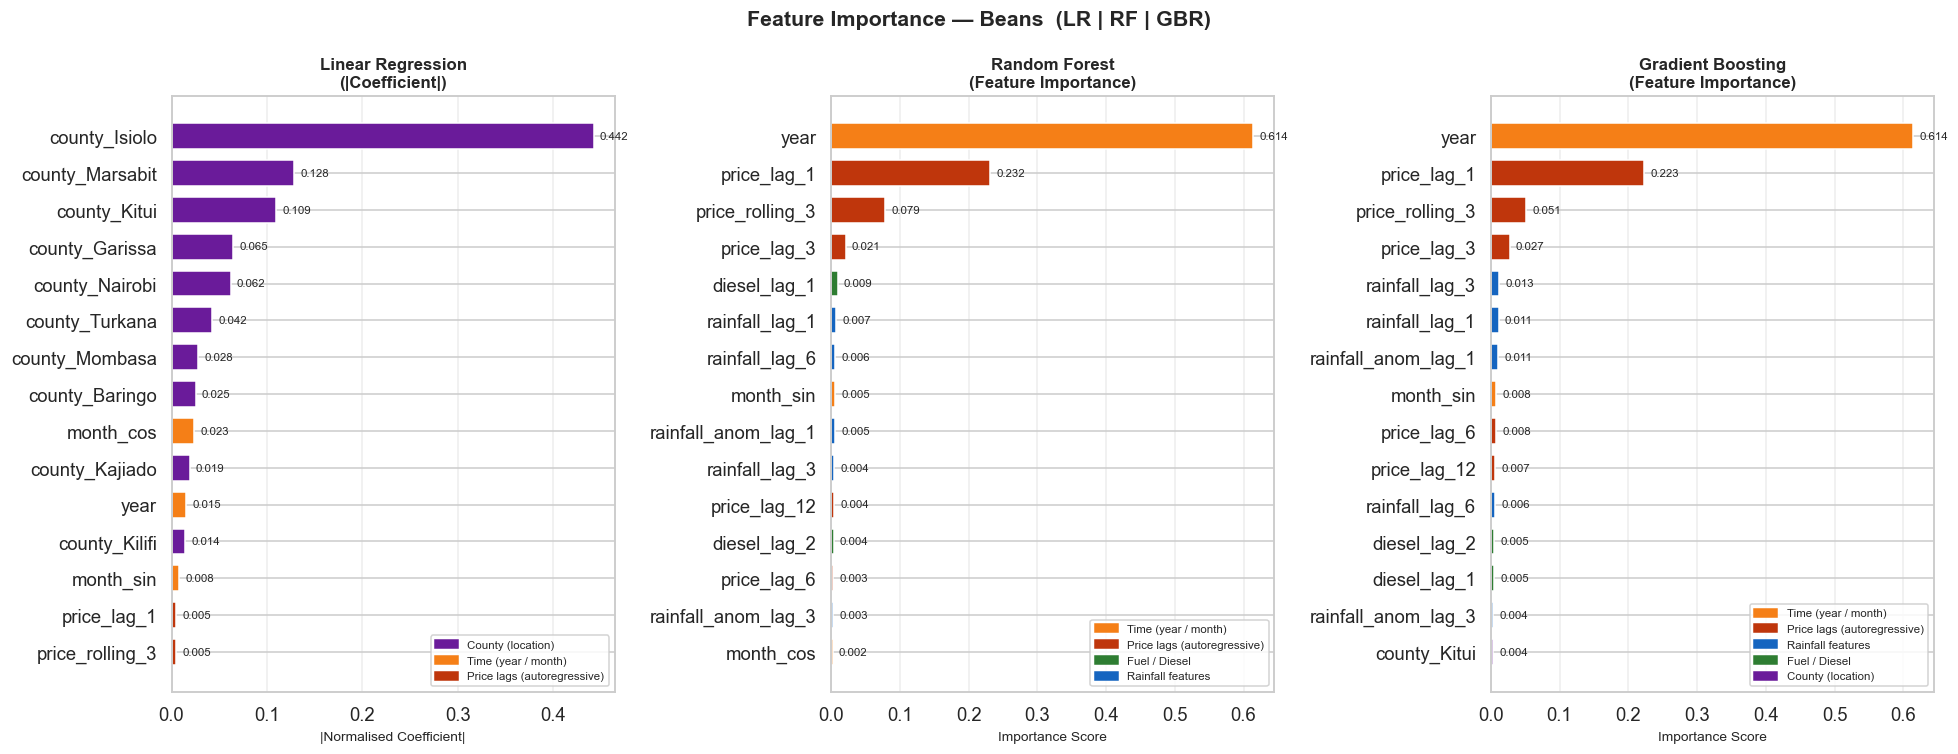

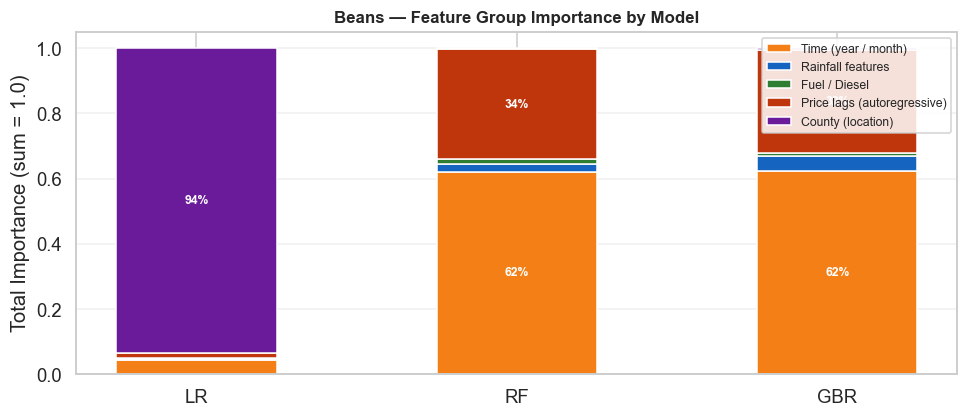


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Milk
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  county_Turkana                 0.4838  County (location)
  county_Nairobi                 0.4838  County (location)
  month_sin                      0.0118  Time (year / month)
  price_lag_1                    0.0063  Price lags (autoregressive)
  month_cos                      0.0044  Time (year / month)
  price_rolling_3                0.0021  Price lags (autoregressive)
  year                           0.0020  Time (year / month)
  diesel_lag_2                   0.0019  Fuel / Diesel
  diesel_lag_1                   0.0012  Fuel / Diesel
  price_lag_6                    0.0010  Price lags (autoregressive)

  RF — Top 10 Features:
  Feature                         Score  Group
  --------------------------------------

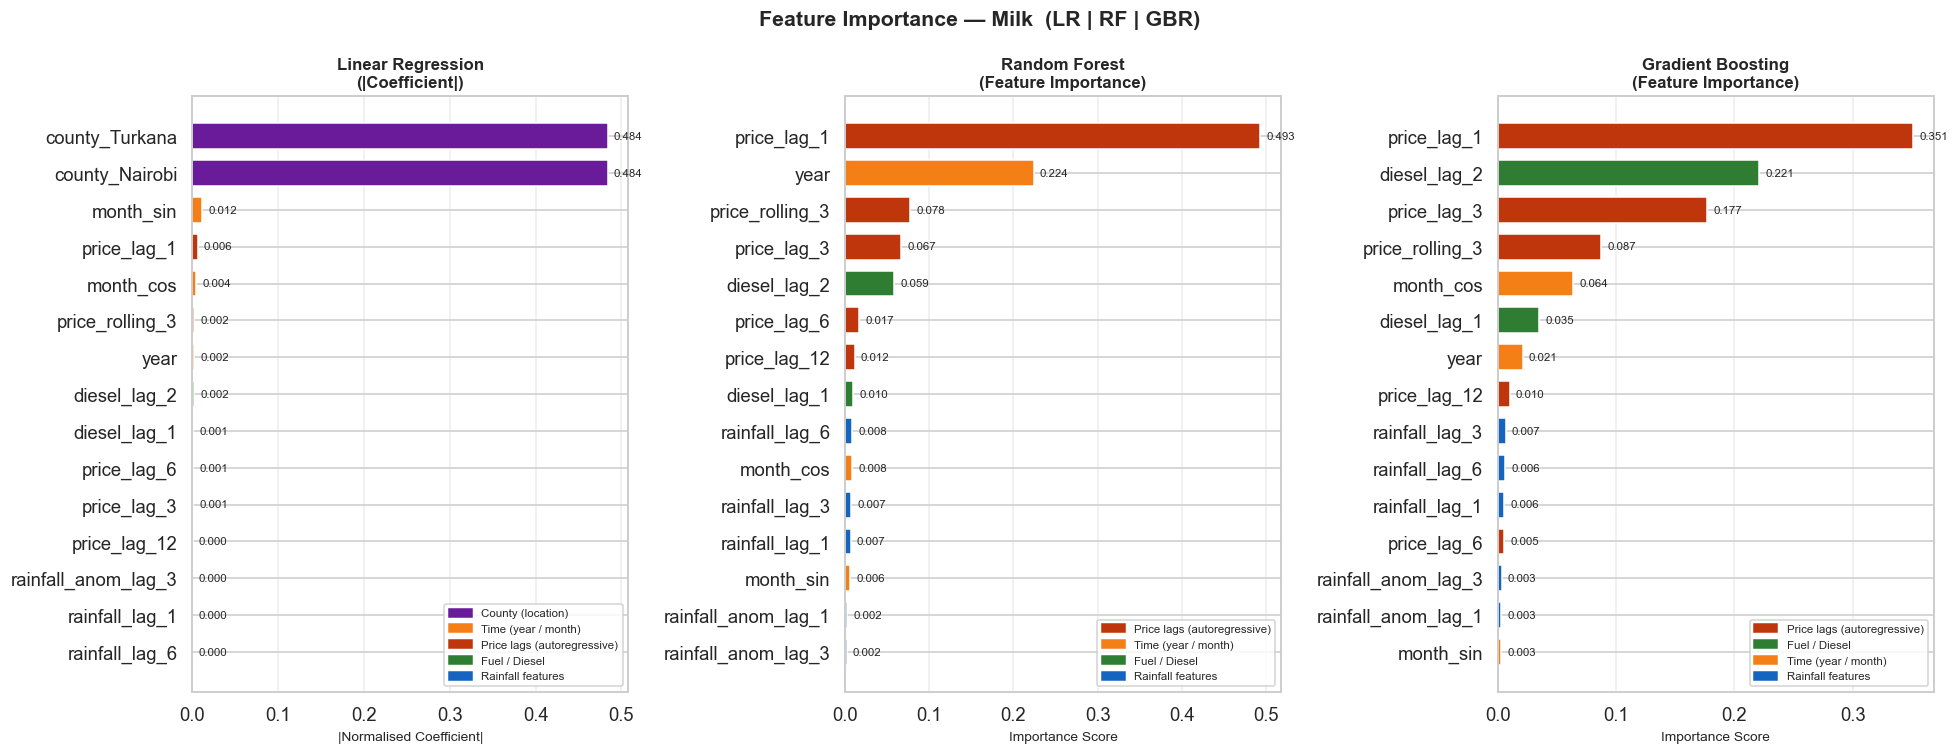

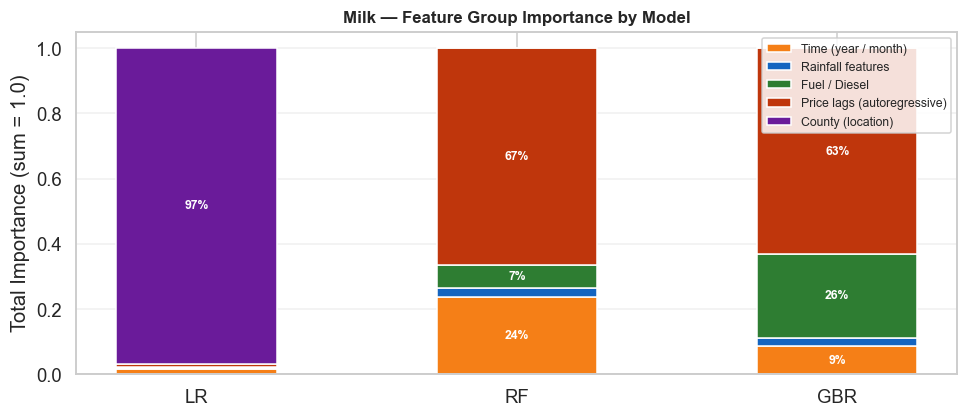


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Maize Flour
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  year                           0.2743  Time (year / month)
  county_Wajir                   0.1780  County (location)
  county_Baringo                 0.1384  County (location)
  county_Garissa                 0.0853  County (location)
  month_sin                      0.0789  Time (year / month)
  county_Mombasa                 0.0483  County (location)
  county_Marsabit                0.0439  County (location)
  county_Isiolo                  0.0435  County (location)
  county_Turkana                 0.0390  County (location)
  county_Nairobi                 0.0283  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------

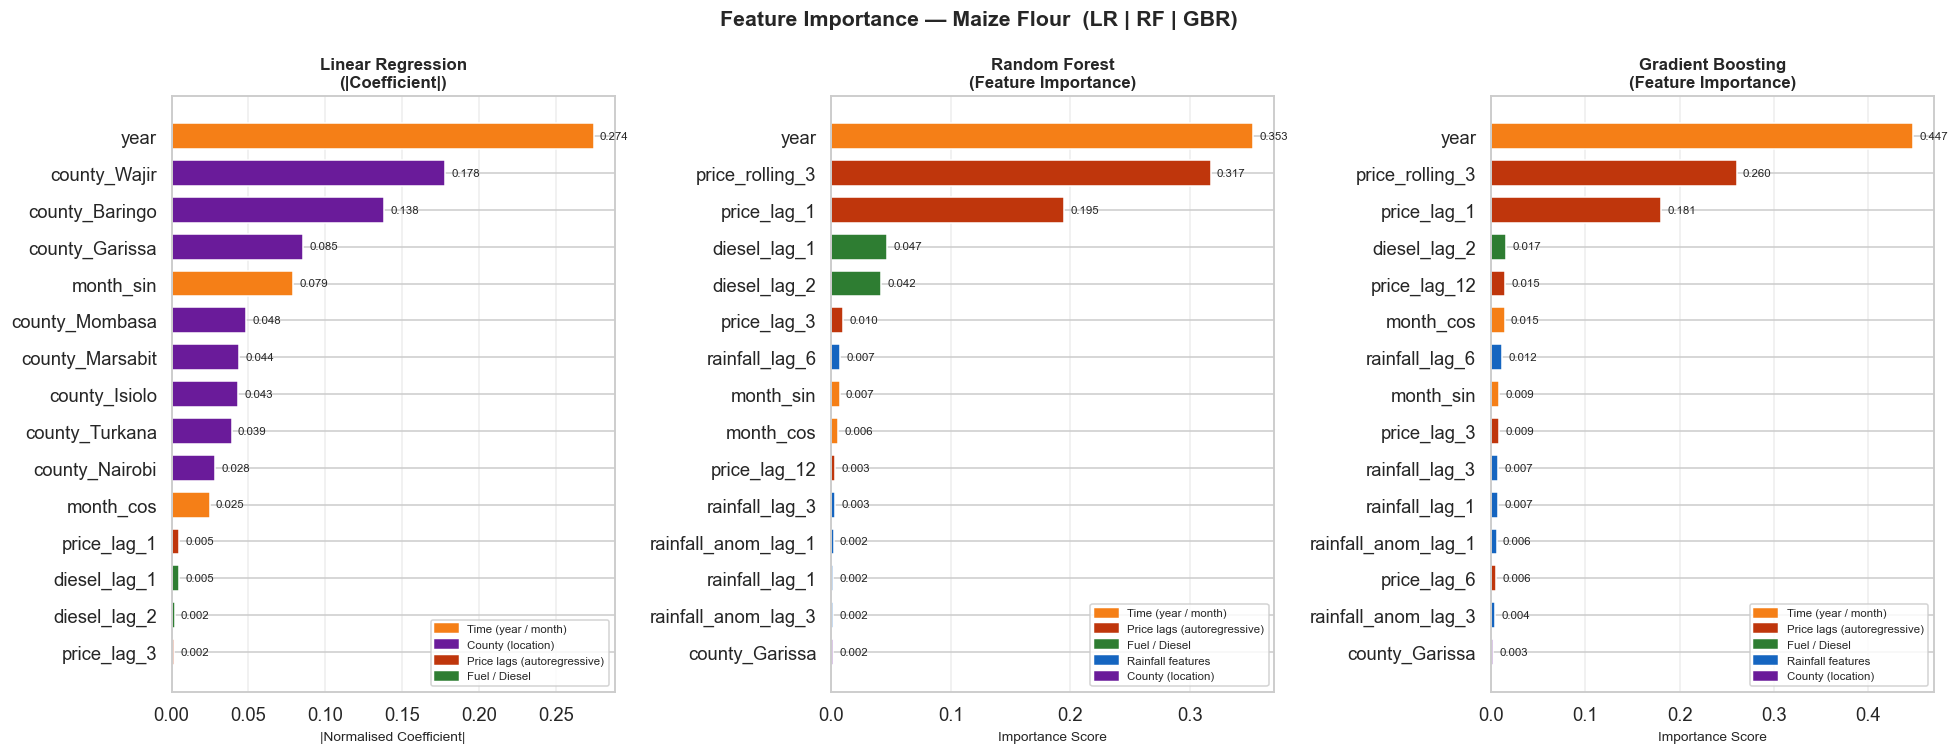

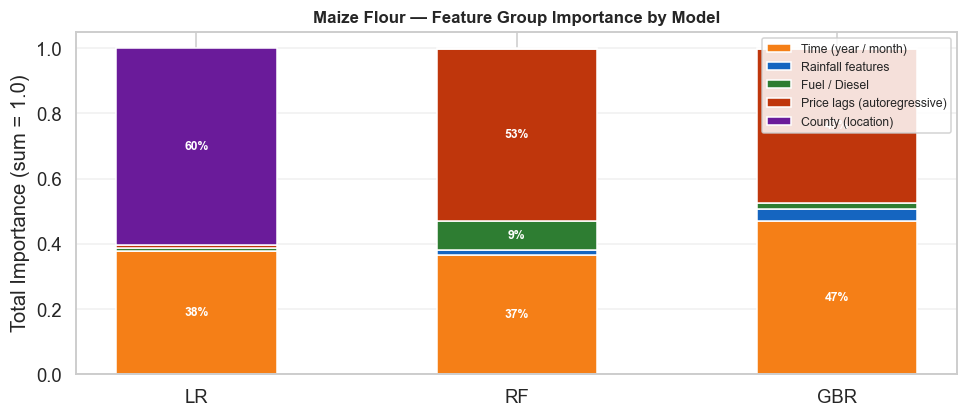


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Wheat Flour
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  LR — Top 10 Features:
  Feature                         Score  Group
  -------------------------------------------------------
  year                           0.3706  Time (year / month)
  county_Wajir                   0.1979  County (location)
  county_Marsabit                0.1138  County (location)
  county_Nairobi                 0.1028  County (location)
  county_Mombasa                 0.0452  County (location)
  month_cos                      0.0433  Time (year / month)
  county_Isiolo                  0.0407  County (location)
  county_Garissa                 0.0260  County (location)
  month_sin                      0.0213  Time (year / month)
  county_Turkana                 0.0130  County (location)

  RF — Top 10 Features:
  Feature                         Score  Group
  -----------------------------------------------------

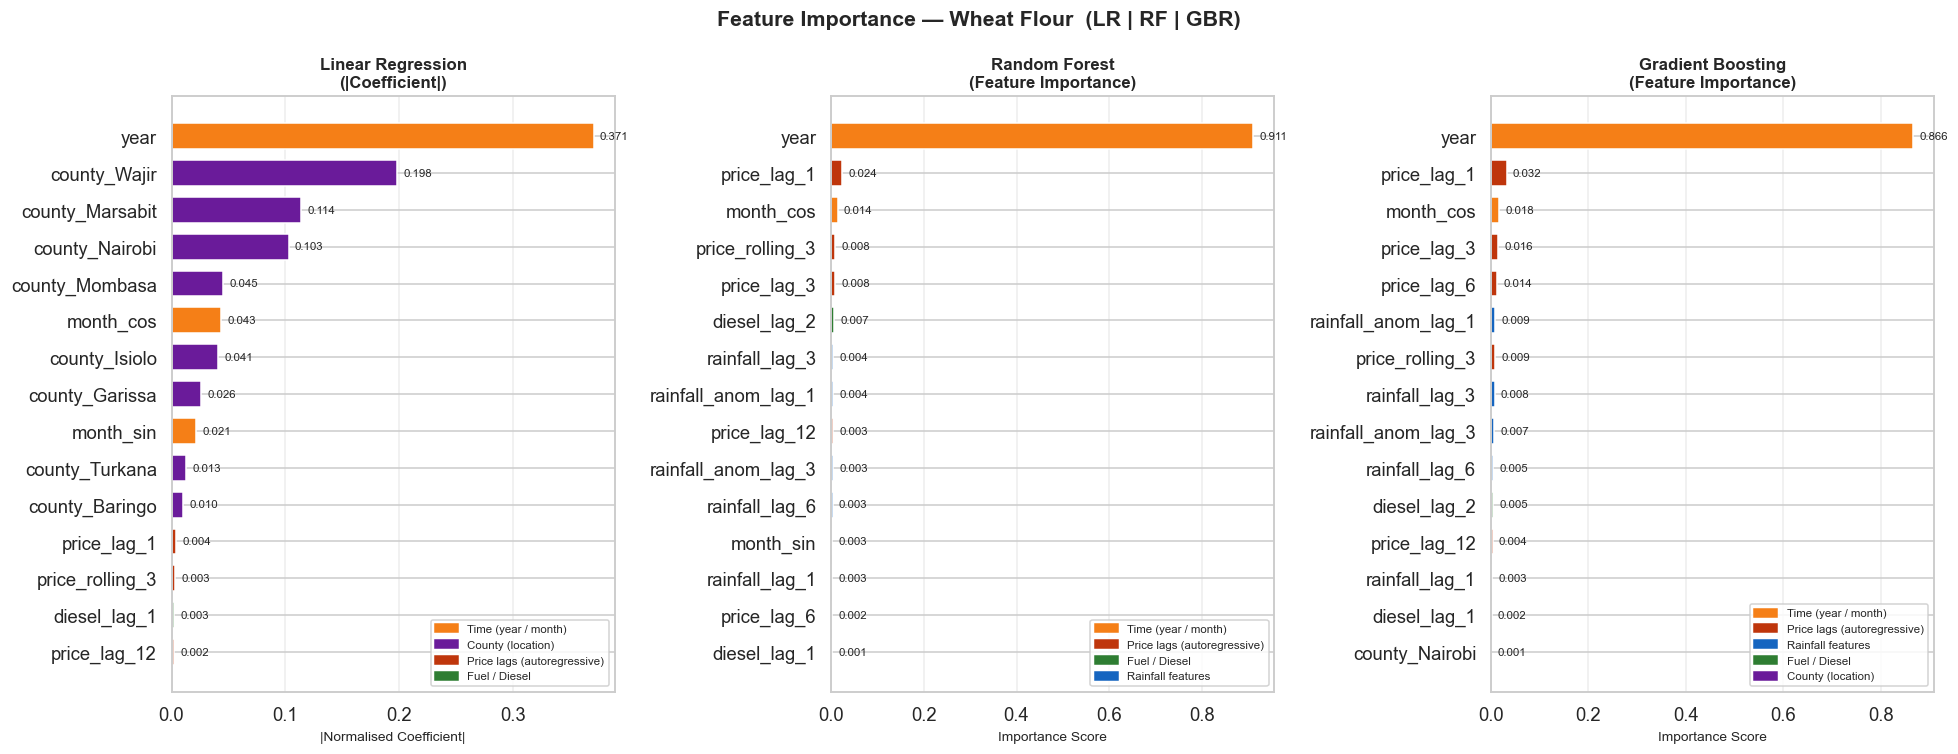

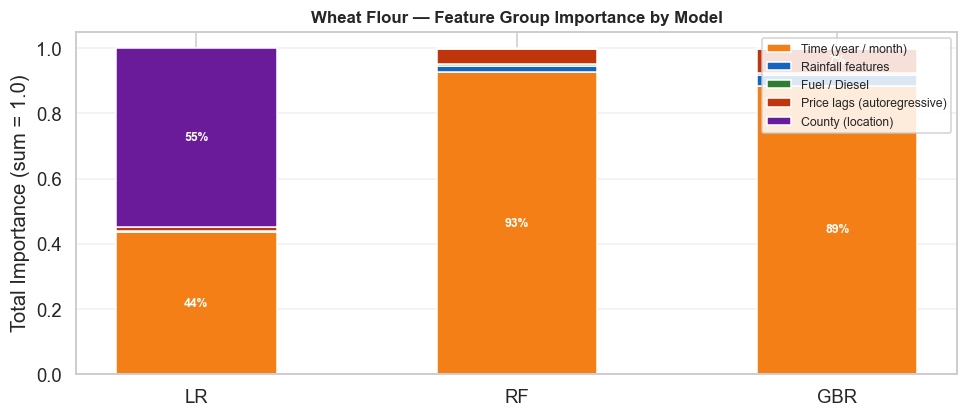

In [73]:
# Feature Importance — LR (coefficients), RF & GBR per commodity 
# For each commodity: one figure with 3 panels (one per model)
# LR uses absolute coefficients; RF & GBR use built-in feature_importances_

from matplotlib.patches import Patch
import numpy as np

top_n = 15

def fi_color(f):
    if f.startswith('price_lag') or f == 'price_rolling_3': return '#BF360C'  # red
    if 'rainfall' in f:                                      return '#1565C0'  # blue
    if 'diesel'   in f:                                      return '#2E7D32'  # green
    if f in ('year', 'month_sin', 'month_cos'):              return '#F57F17'  # amber
    if f.startswith('county_'):                              return '#6A1B9A'  # purple
    return '#455A64'

GROUP_LABELS = {
    '#BF360C': 'Price lags (autoregressive)',
    '#1565C0': 'Rainfall features',
    '#2E7D32': 'Fuel / Diesel',
    '#F57F17': 'Time (year / month)',
    '#6A1B9A': 'County (location)',
    '#455A64': 'Other',
}

MODEL_TITLES = {
    'LR':  'Linear Regression\n(|Coefficient|)',
    'RF':  'Random Forest\n(Feature Importance)',
    'GBR': 'Gradient Boosting\n(Feature Importance)',
}
MODEL_COLORS = {
    'LR':  '#90CAF9',   # light blue tint for LR bars
    'RF':  '#A5D6A7',   # light green tint for RF bars
    'GBR': '#FFCC80',   # light amber tint for GBR bars
}

def get_importances(model, model_name, feat_names):
    """Extract normalised importances for any model type."""
    if model_name == 'LR':
        raw = np.abs(model.coef_)
        total = raw.sum()
        return pd.Series(raw / total if total > 0 else raw, index=feat_names)
    else:
        return pd.Series(model.feature_importances_, index=feat_names)

for comm in commodities_done:
    res        = comm_results[comm]
    feat_names = res['feat_names']

    print(f'\n{"━"*65}')
    print(f'  {comm}')
    print(f'{"━"*65}')

    # One figure per commodity: 3 columns (LR | RF | GBR) 
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    for ax, model_name in zip(axes, ['LR', 'RF', 'GBR']):
        model      = res['pipes'][model_name].named_steps['model']
        fi_full    = get_importances(model, model_name, feat_names)
        fi_top     = fi_full.sort_values(ascending=False).head(top_n)
        colors_bar = [fi_color(f) for f in fi_top.index]

        # Horizontal bar chart
        bars = ax.barh(fi_top.index[::-1], fi_top.values[::-1],
                       color=colors_bar[::-1], edgecolor='white', height=0.7)

        ax.set_title(MODEL_TITLES[model_name], fontweight='bold', fontsize=11)
        xlabel = '|Normalised Coefficient|' if model_name == 'LR' else 'Importance Score'
        ax.set_xlabel(xlabel, fontsize=9)
        ax.grid(axis='x', alpha=0.35)

        # Value labels on each bar
        x_pad = fi_top.max() * 0.015
        for bar, val in zip(bars, fi_top.values[::-1]):
            ax.text(bar.get_width() + x_pad,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=7.5)

        # Per-panel legend (only groups actually present)
        present_colors = list(dict.fromkeys(colors_bar))
        legend_handles = [Patch(color=c, label=GROUP_LABELS.get(c, 'Other'))
                          for c in present_colors]
        ax.legend(handles=legend_handles, fontsize=7.5,
                  loc='lower right', framealpha=0.85)

        # Print top-10 table for this model
        print(f'\n  {model_name} — Top 10 Features:')
        print(f'  {"Feature":<28} {"Score":>8}  Group')
        print('  ' + '-'*55)
        for feat, imp in fi_full.sort_values(ascending=False).head(10).items():
            grp = GROUP_LABELS.get(fi_color(feat), 'Other')
            print(f'  {feat:<28} {imp:>8.4f}  {grp}')

    plt.suptitle(f'Feature Importance — {comm}  (LR | RF | GBR)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Grouped importance comparison — stacked bar across models 
    group_data = {}
    for model_name in ['LR', 'RF', 'GBR']:
        model   = res['pipes'][model_name].named_steps['model']
        fi_full = get_importances(model, model_name, feat_names)
        grp_imp = {}
        for feat, imp in fi_full.items():
            lbl = GROUP_LABELS.get(fi_color(feat), 'Other')
            grp_imp[lbl] = grp_imp.get(lbl, 0) + imp
        group_data[model_name] = grp_imp

    grp_df = pd.DataFrame(group_data).fillna(0)
    grp_colors = {
        'Price lags (autoregressive)': '#BF360C',
        'Rainfall features':           '#1565C0',
        'Fuel / Diesel':               '#2E7D32',
        'Time (year / month)':         '#F57F17',
        'County (location)':           '#6A1B9A',
        'Other':                       '#455A64',
    }

    fig2, ax2 = plt.subplots(figsize=(9, 4))
    bottom = np.zeros(3)
    model_names = ['LR', 'RF', 'GBR']
    for grp_label, row in grp_df.iterrows():
        vals   = [row.get(m, 0) for m in model_names]
        color  = grp_colors.get(grp_label, '#455A64')
        bars2  = ax2.bar(model_names, vals, bottom=bottom,
                         color=color, edgecolor='white',
                         width=0.5, label=grp_label)
        # Label segments > 5%
        for rect, val, bot in zip(bars2, vals, bottom):
            if val > 0.05:
                ax2.text(rect.get_x() + rect.get_width()/2,
                         bot + val/2,
                         f'{val*100:.0f}%',
                         ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
        bottom += np.array(vals)

    ax2.set_title(f'{comm} — Feature Group Importance by Model',
                  fontweight='bold', fontsize=11)
    ax2.set_ylabel('Total Importance (sum = 1.0)')
    ax2.set_ylim(0, 1.05)
    ax2.legend(loc='upper right', fontsize=8, framealpha=0.85)
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8.7. Predicted vs. Actual Scatter — All Commodities
Predicted vs Actual scatter — best model per commodity

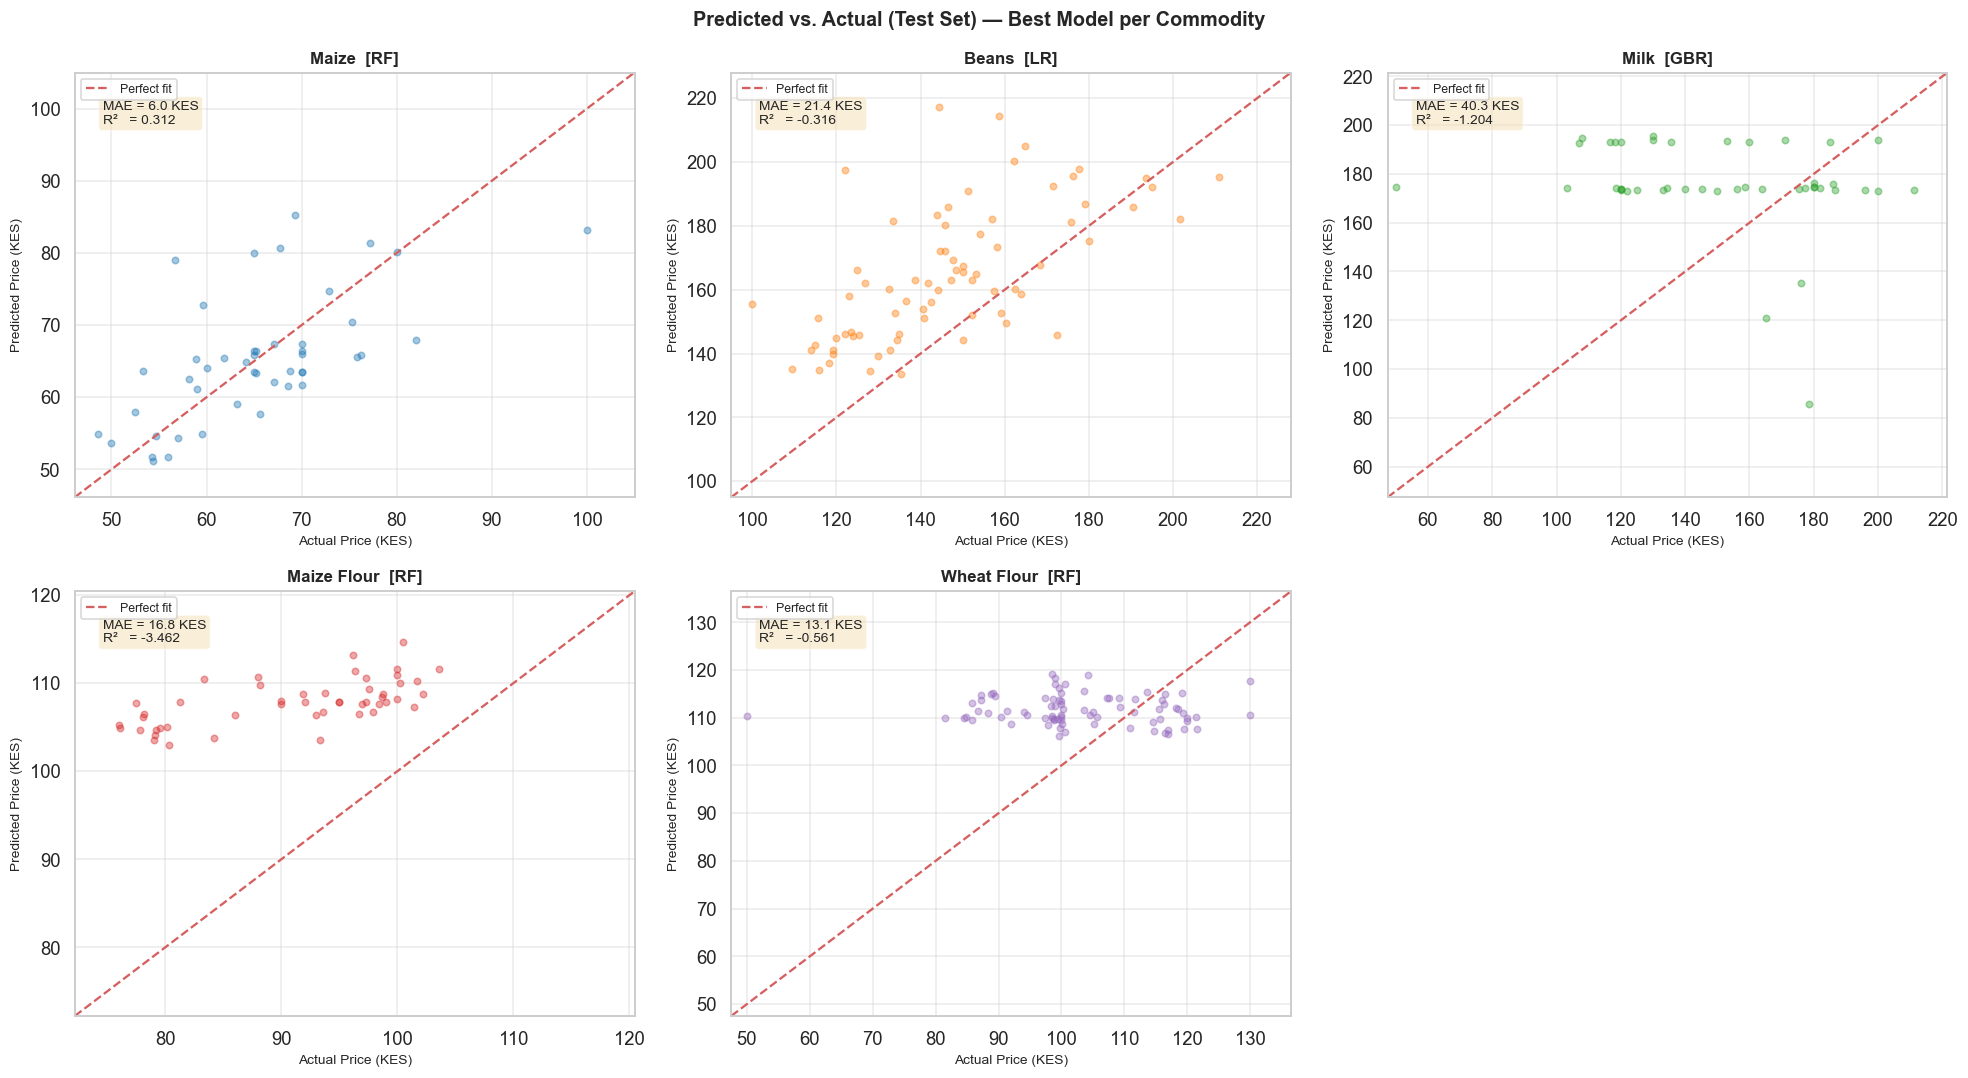

In [74]:
n_c   = len(commodities_done)
cols  = min(n_c, 3)
rows  = (n_c + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).flatten() if n_c > 1 else [axes]

scatter_palette = sns.color_palette('tab10', n_c)

for i, comm in enumerate(commodities_done):
    ax       = axes[i]
    res      = comm_results[comm]
    best_key = res['best_model']
    y_te     = res['y_te']
    y_pr     = res['preds'][best_key]
    mae      = res['metrics'][best_key]['MAE']
    r2       = res['metrics'][best_key]['R2']

    ax.scatter(y_te, y_pr, alpha=0.4, s=18, color=scatter_palette[i])
    lims = [min(y_te.min(), y_pr.min()) * 0.95,
            max(y_te.max(), y_pr.max()) * 1.05]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Price (KES)', fontsize=9)
    ax.set_ylabel('Predicted Price (KES)', fontsize=9)
    ax.set_title(f'{comm}  [{best_key}]', fontweight='bold', fontsize=11)
    ax.text(0.05, 0.88,
            f'MAE = {mae:.1f} KES\nR²   = {r2:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)

for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predicted vs. Actual (Test Set) — Best Model per Commodity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.8. Residual Distribution — All Commodities
Residual histograms on the best model per commodity

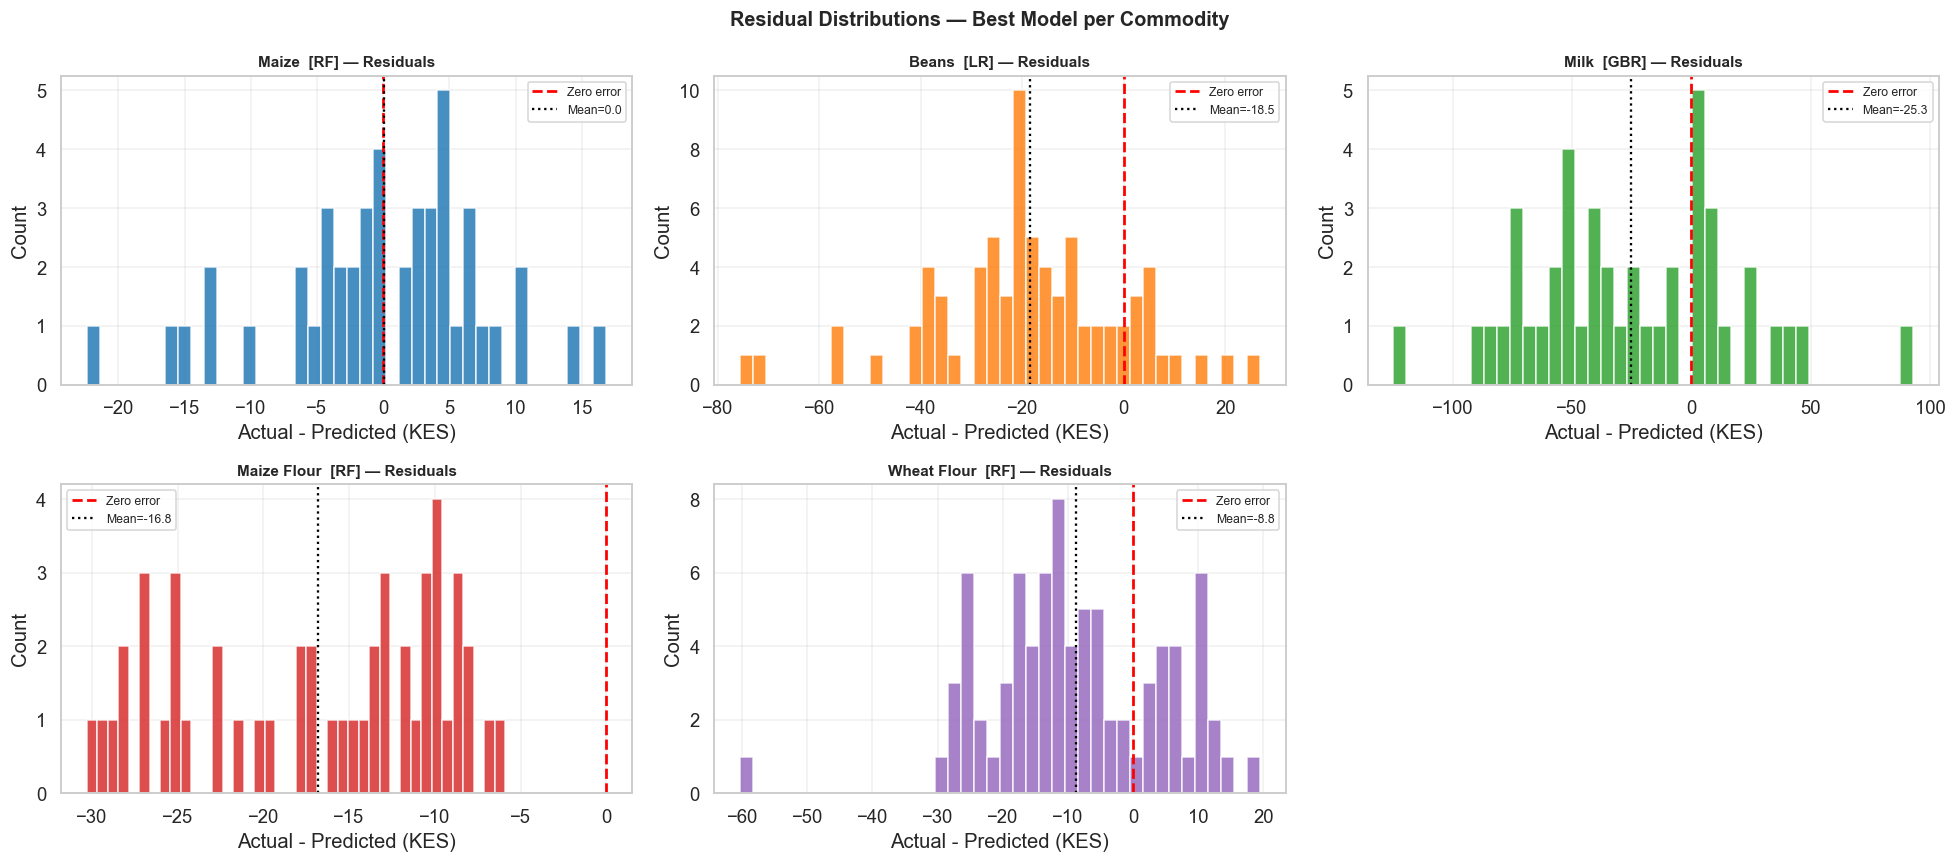

In [75]:
# Residual histograms — best model per commodity
n_c  = len(commodities_done)
cols = min(n_c, 3)
rows = (n_c + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = np.array(axes).flatten() if n_c > 1 else [axes]

for i, comm in enumerate(commodities_done):
    ax       = axes[i]
    res      = comm_results[comm]
    best_key = res['best_model']
    residuals = res['y_te'].values - res['preds'][best_key]

    ax.hist(residuals, bins=40, color=scatter_palette[i],
            edgecolor='white', alpha=0.82)
    ax.axvline(0, color='red', lw=1.8, ls='--', label='Zero error')
    ax.axvline(residuals.mean(), color='black', lw=1.5,
               ls=':', label=f'Mean={residuals.mean():.1f}')
    ax.set_title(f'{comm}  [{best_key}] — Residuals',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual - Predicted (KES)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(n_c, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Residual Distributions — Best Model per Commodity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8.9. Actual vs. Predicted Time-Series — All Commodities & Top Counties

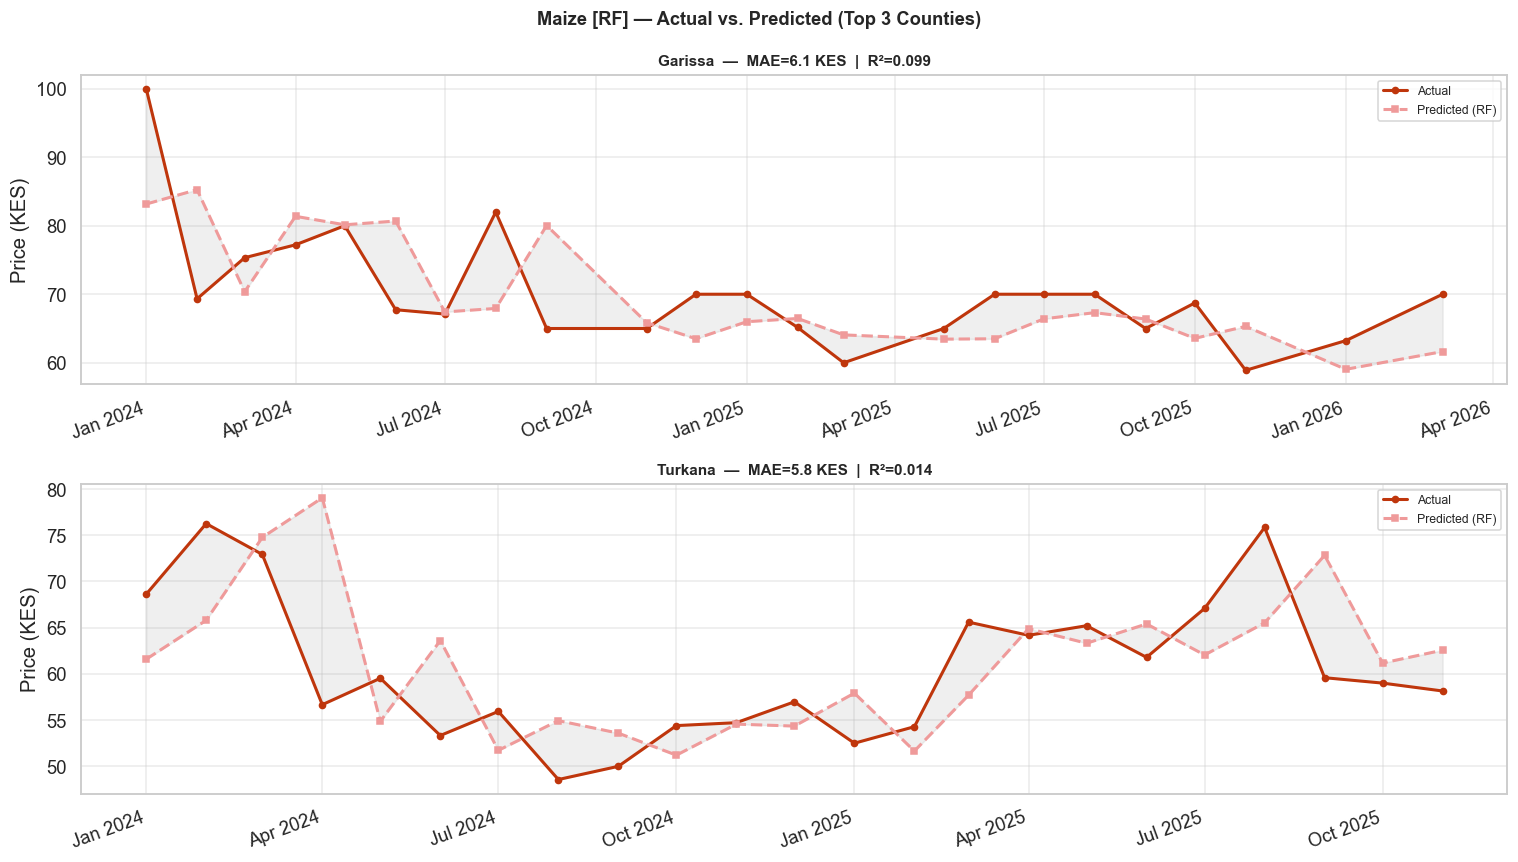

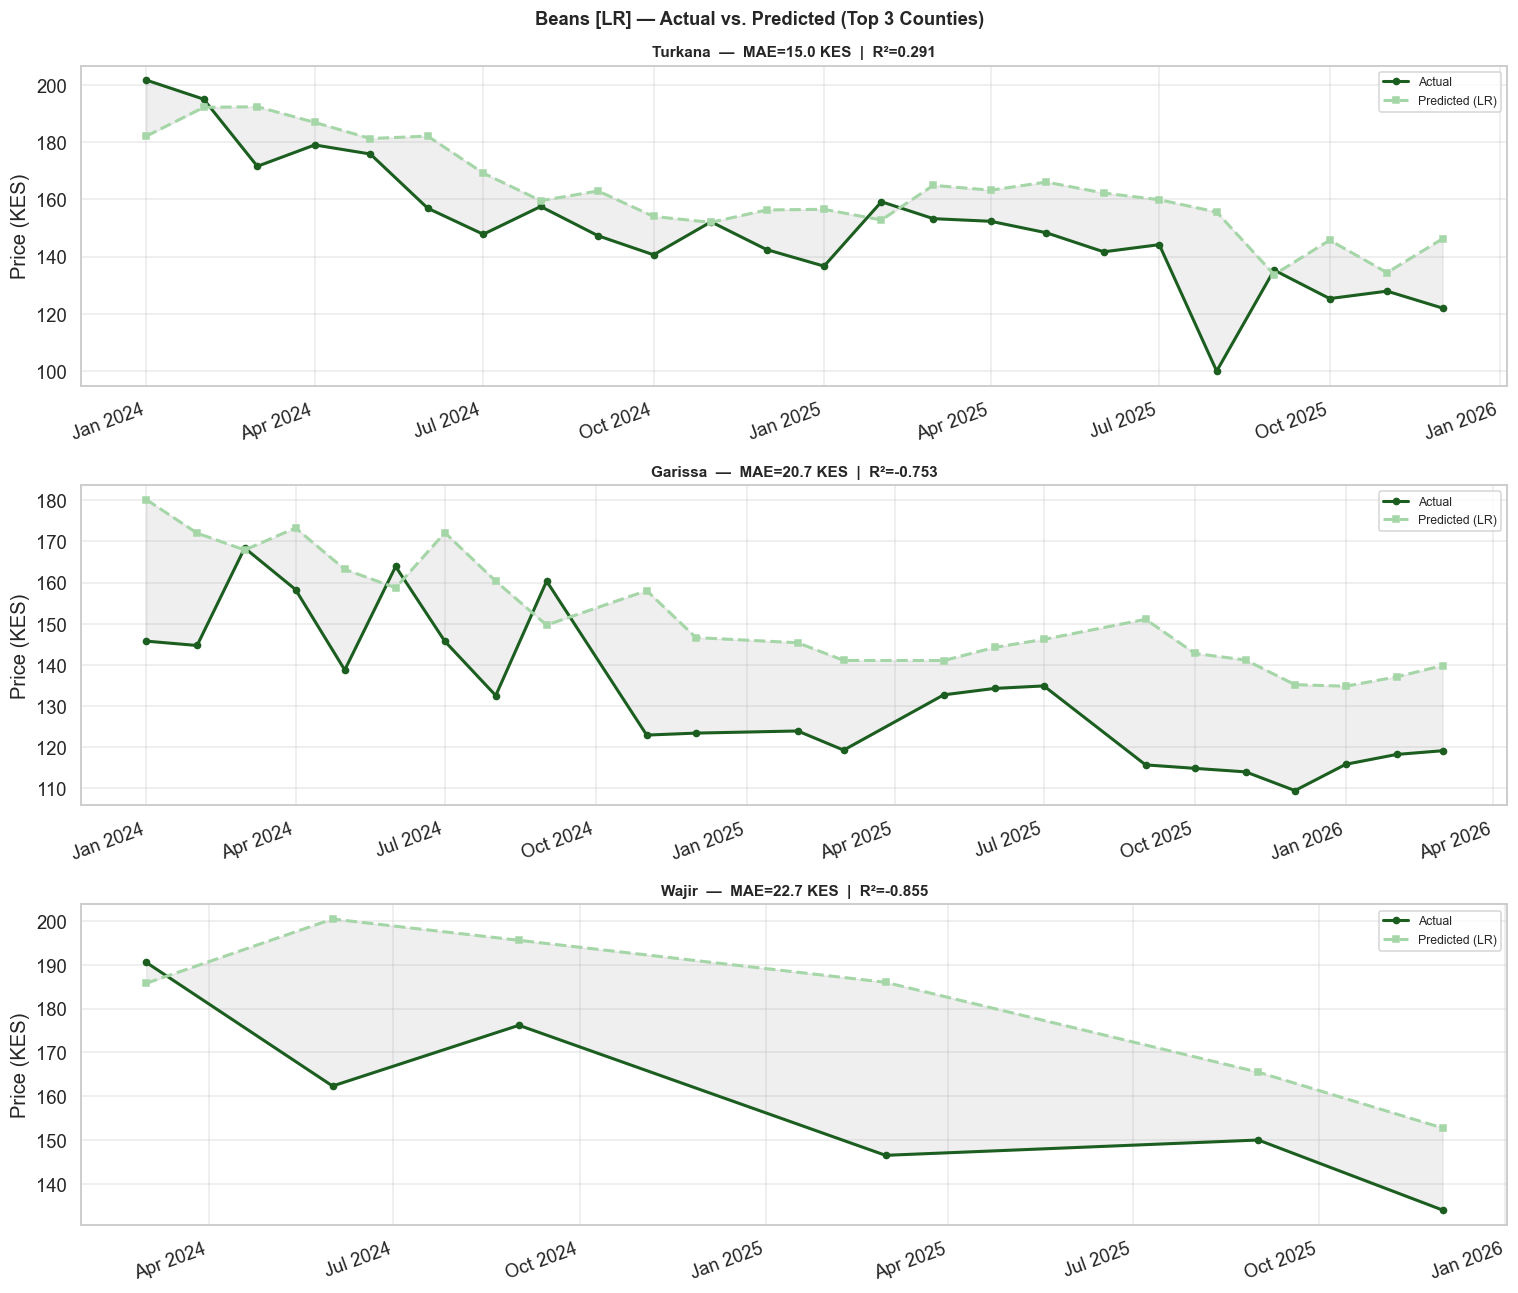

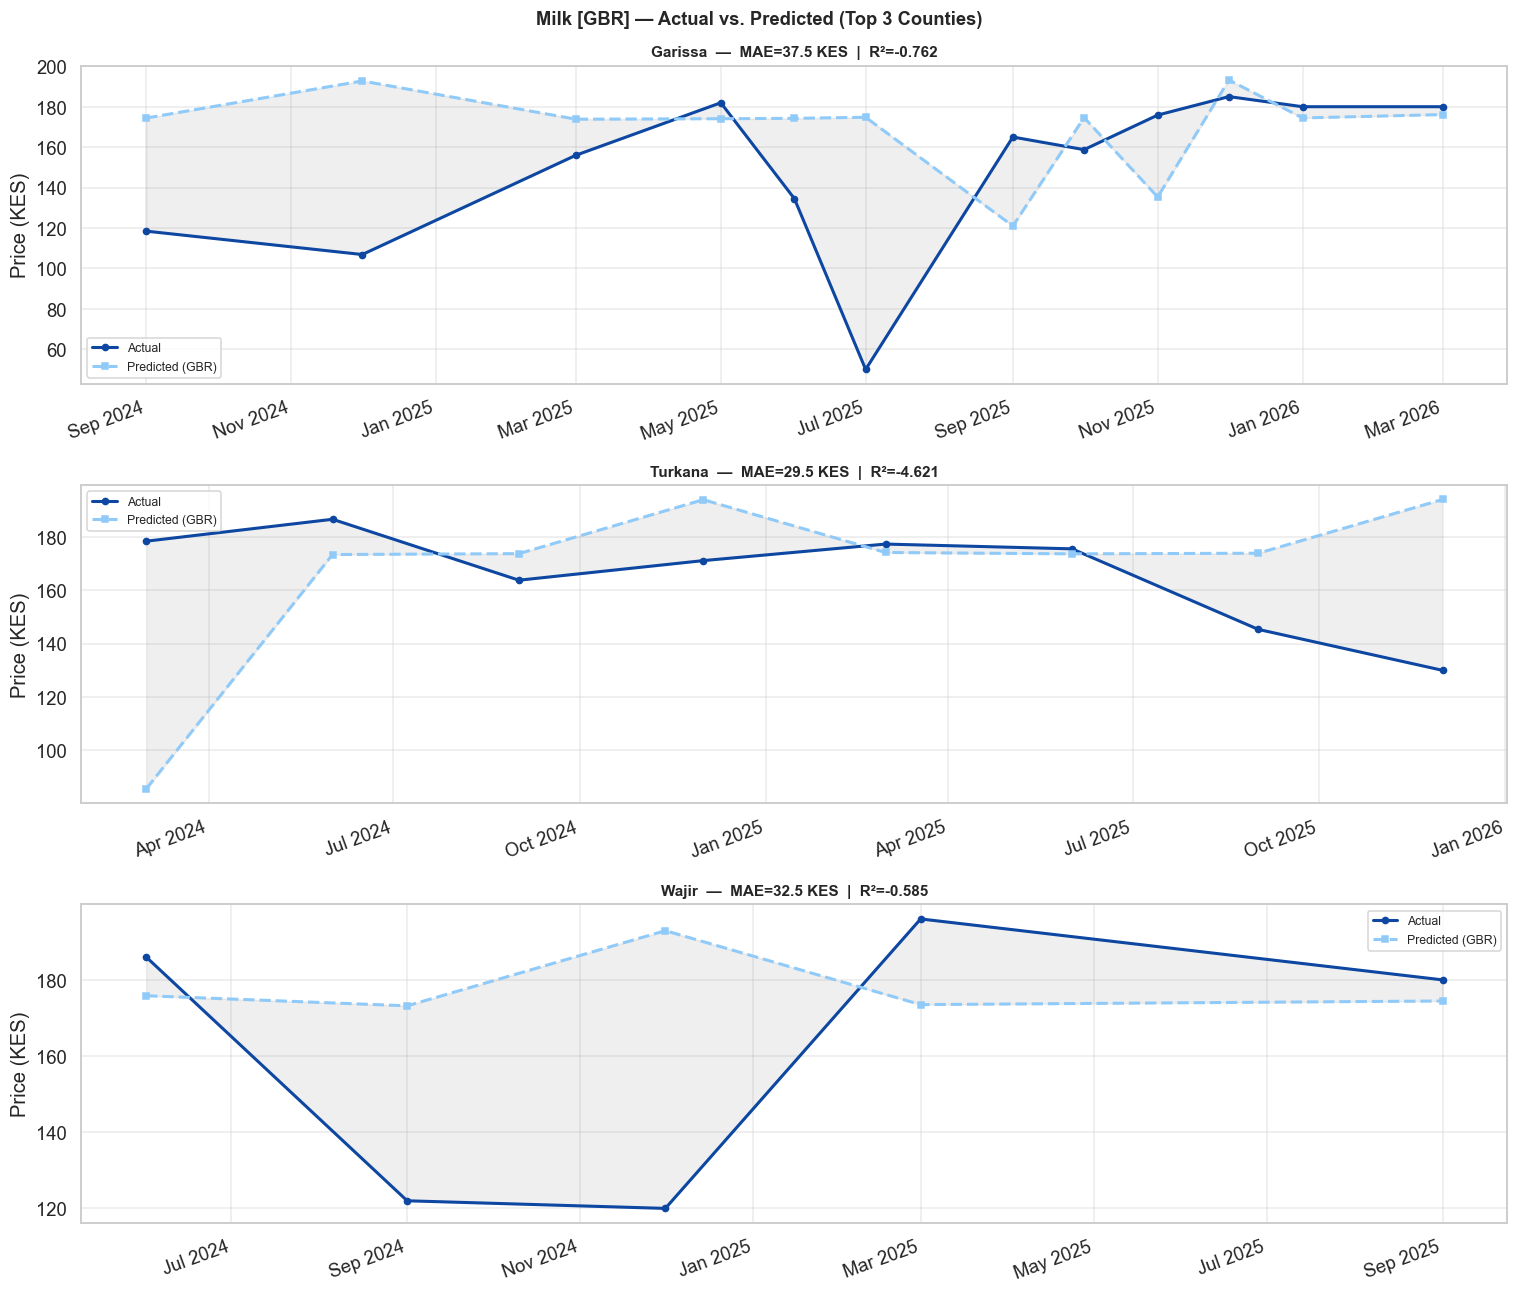

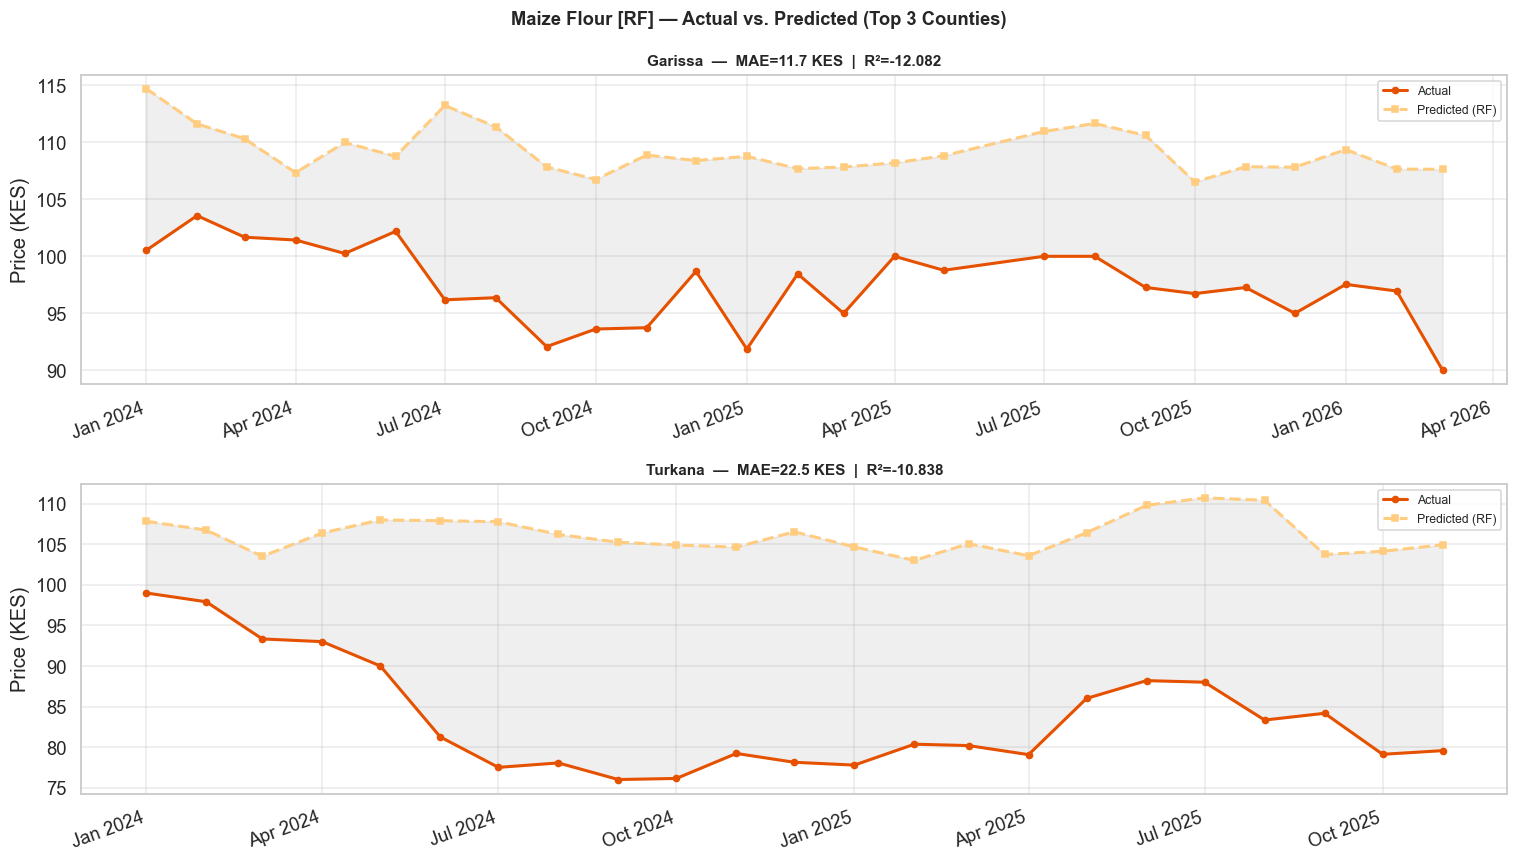

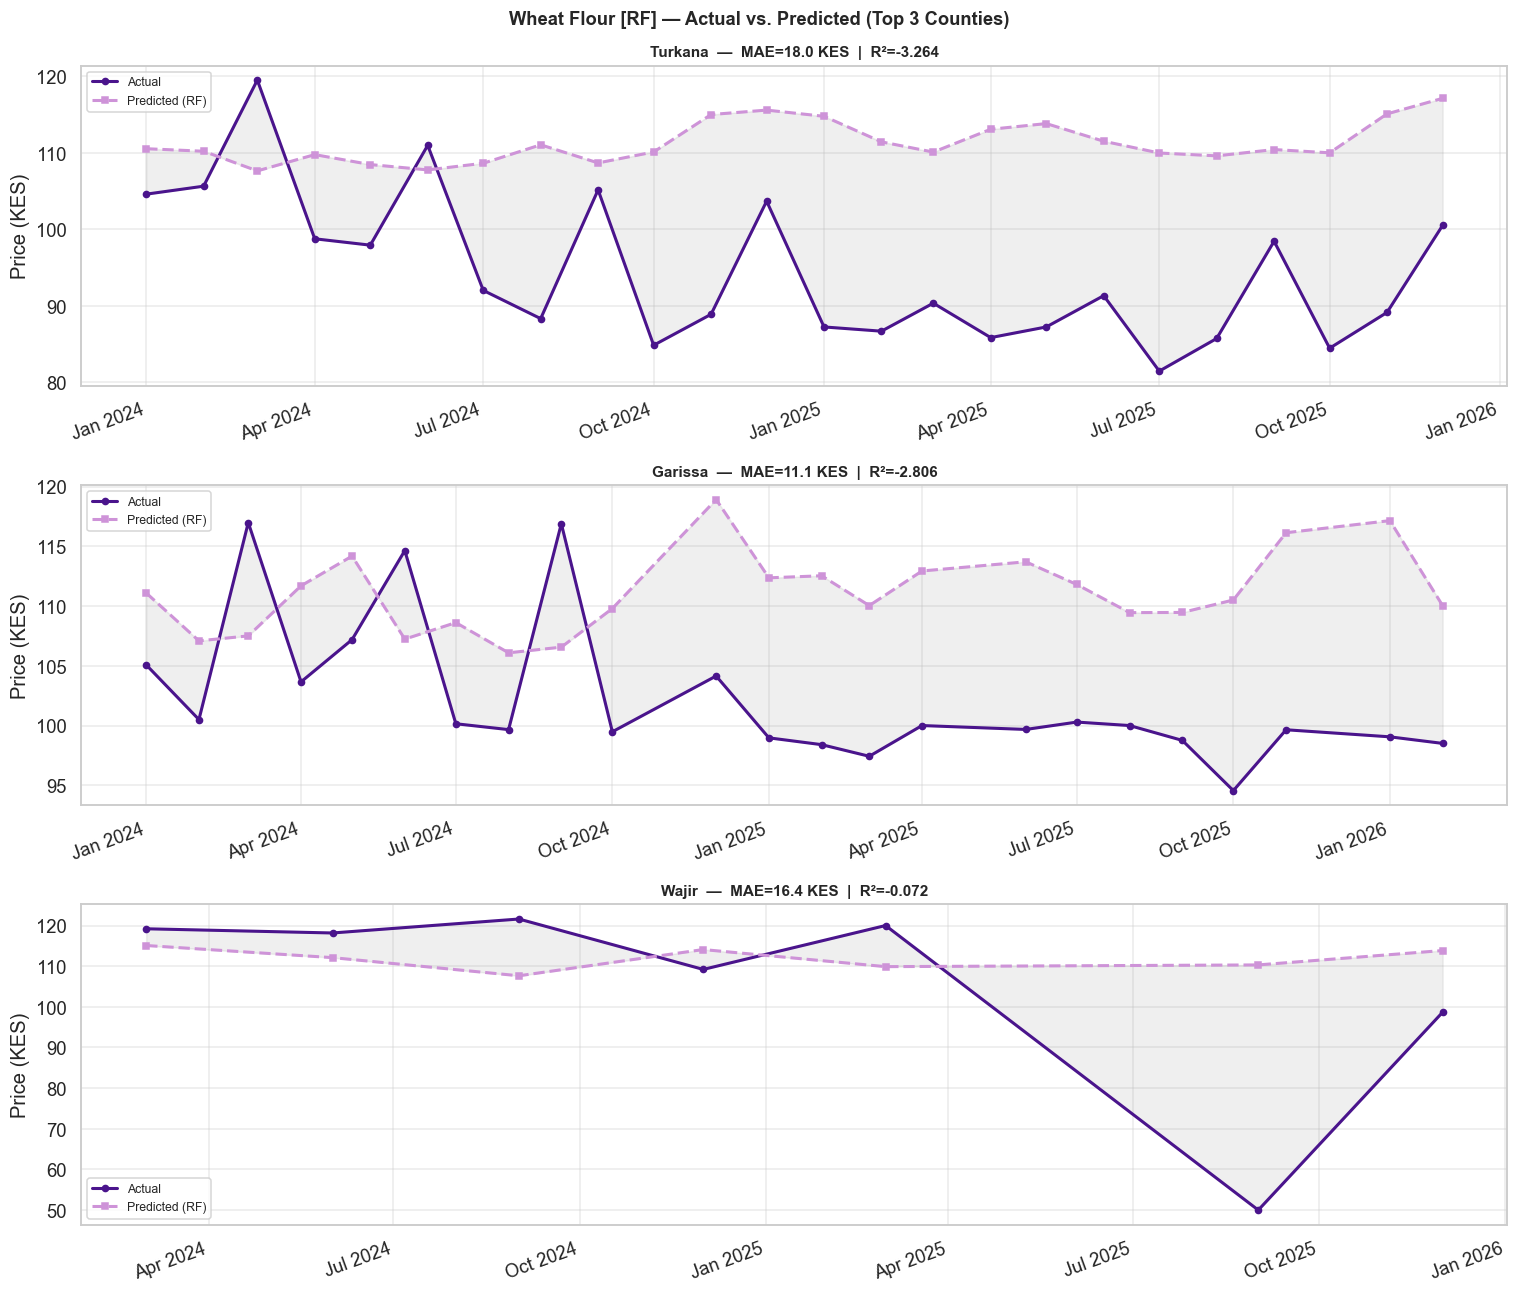

In [76]:
# Time-series: Actual vs Predicted — best model per commodity, top 3 counties
act_colors  = ['#BF360C','#1B5E20','#0D47A1','#E65100','#4A148C']
pred_colors = ['#EF9A9A','#A5D6A7','#90CAF9','#FFCC80','#CE93D8']

for i, comm in enumerate(commodities_done):
    res      = comm_results[comm]
    best_key = res['best_model']
    df_c     = res['df_c']
    te_mask  = res['te_mask']

    test_c = df_c[te_mask].copy()
    test_c['predicted'] = res['preds'][best_key]

    top_counties = (test_c.groupby('county')['price']
                    .count().nlargest(3).index.tolist())

    n_counties = len(top_counties)
    fig, axes  = plt.subplots(n_counties, 1,
                               figsize=(14, 4 * n_counties), sharex=False)
    if n_counties == 1:
        axes = [axes]

    for ax, county in zip(axes, top_counties):
        sub = test_c[test_c['county'] == county].sort_values('date_month')
        if sub.empty:
            ax.set_title(f'{county} — no test data')
            continue
        mae_loc = mean_absolute_error(sub['price'], sub['predicted'])
        r2_loc  = r2_score(sub['price'], sub['predicted']) if len(sub) > 2 else float('nan')

        ax.plot(sub['date_month'], sub['price'],
                'o-', lw=2, ms=4, color=act_colors[i], label='Actual')
        ax.plot(sub['date_month'], sub['predicted'],
                's--', lw=2, ms=4, color=pred_colors[i],
                label=f'Predicted ({best_key})')
        ax.fill_between(sub['date_month'], sub['price'], sub['predicted'],
                        alpha=0.12, color='grey')
        ax.set_title(f'{county}  —  MAE={mae_loc:.1f} KES  |  R²={r2_loc:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('Price (KES)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    plt.suptitle(f'{comm} [{best_key}] — Actual vs. Predicted (Top 3 Counties)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8.10. Final Consolidated Leaderboard — All Commodities
Final leaderboard on the best model per commodity

  FINAL LEADERBOARD — Best Model per Commodity
   Commodity Best Model  MAE (KES)  RMSE (KES)      R²  MAE % of Price  Test Rows
       Maize         RF       5.98        7.79  0.3121             9.2         46
 Wheat Flour         RF      13.09       15.86 -0.5608            12.7         82
       Beans         LR      21.39       26.40 -0.3156            14.6         74
 Maize Flour         RF      16.79       18.31 -3.4621            18.4         49
        Milk        GBR      40.28       49.58 -1.2039            26.8         43


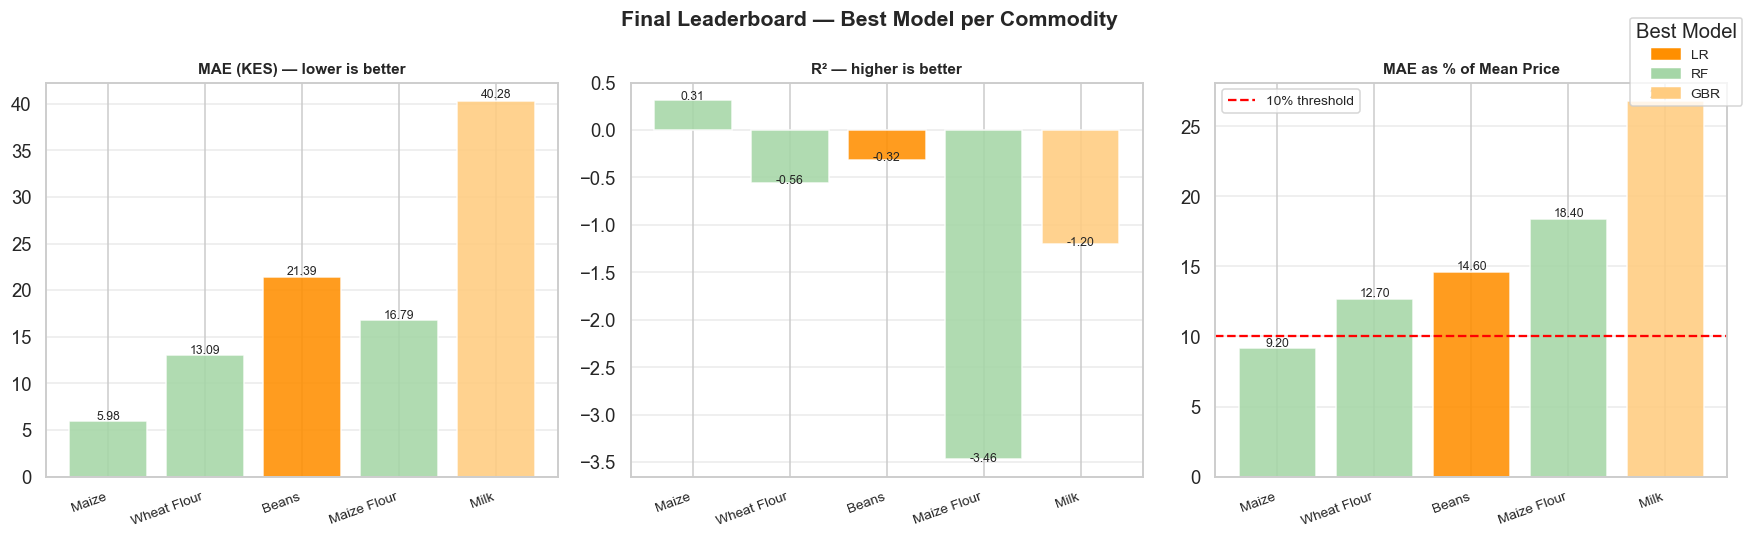

In [77]:
leaderboard_rows = []
for comm in commodities_done:
    res       = comm_results[comm]
    best_key  = res['best_model']
    bm        = res['metrics'][best_key]
    mean_price = res['y_te'].mean()
    leaderboard_rows.append({
        'Commodity':      comm,
        'Best Model':     best_key,
        'MAE (KES)':      round(bm['MAE'], 2),
        'RMSE (KES)':     round(bm['RMSE'], 2),
        'R²':             round(bm['R2'], 4),
        'MAE % of Price': round(bm['MAE'] / mean_price * 100, 1),
        'Test Rows':      len(res['y_te']),
    })

lb = pd.DataFrame(leaderboard_rows).sort_values('MAE % of Price')

print('=' * 75)
print('  FINAL LEADERBOARD — Best Model per Commodity')
print('=' * 75)
print(lb.to_string(index=False))

# Bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette_lb    = sns.color_palette('Set2', len(lb))
model_palette = {'LR': '#FF8F00', 'RF': '#A5D6A7', 'GBR': '#FFCC80'}
bar_cols_lb   = [model_palette.get(m, '#90CAF9') for m in lb['Best Model']]

for ax, col, title in zip(axes,
    ['MAE (KES)', 'R²', 'MAE % of Price'],
    ['MAE (KES) — lower is better',
     'R² — higher is better',
     'MAE as % of Mean Price']):
    bars = ax.bar(lb['Commodity'], lb[col],
                  color=bar_cols_lb, edgecolor='white', alpha=0.88)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticklabels(lb['Commodity'], rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for bar, v in zip(bars, lb[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()*1.01,
                f'{v:.2f}', ha='center', fontsize=8)

axes[2].axhline(10, color='red', ls='--', lw=1.5, label='10% threshold')
axes[2].legend(fontsize=9)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=m) for m, c in model_palette.items()]
fig.legend(handles=legend_handles, title='Best Model', fontsize=9,
           loc='upper right', bbox_to_anchor=(1.0, 0.98))

plt.suptitle('Final Leaderboard — Best Model per Commodity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()